# Единый датасет модулей M1–M5

Данные M1, M3–M5 подгружаются с сайтов ЦБ / Минфина / ФНС. **M2** можно один раз собрать с сайта и дальше читать из CSV (см. флажок `M2_REPO7D_REFRESH_FROM_WEB` в ячейке M2).

**M2:** при `M2_REPO7D_REFRESH_FROM_WEB = True` — опрос cbr.ru по вторникам (долго); результат сохраняется в `m2_df_m2_cache.csv`. При `False` таблица **df_m2** загружается из этого файла.

Ключ объединения: **`date`**. На днях без аукциона репо признаки M2 остаются NaN.


In [1]:
from pathlib import Path
import re
import time
import xml.etree.ElementTree as ET
from datetime import date, datetime, timedelta
from io import BytesIO

import numpy as np
import pandas as pd
import requests


In [2]:
# --- M1: резервы + RUONIA (ежедневно, m1_fact/m1_need интерполяция на календарь) ---
url_rr = "https://www.cbr.ru/vfs/hd_base/RReserves/required_reserves_table.xlsx"
df_rr = pd.read_excel(url_rr, header=2, skipfooter=8, usecols=[0, 1, 2])
df_rr.columns = ["m1_data", "m1_fact", "m1_need"]
df_rr["m1_data"] = pd.to_datetime(df_rr["m1_data"])

end_m1 = pd.Timestamp.today().normalize()
# ToDate в запросе ЦБ — в формате MM/DD/YYYY (как в исходном M1.ipynb)
url_ruon = (
    "https://www.cbr.ru/Queries/UniDbQuery/DownloadExcel/14315?Posted=True"
    f"&From=11.01.2010&To={end_m1:%d.%m.%Y}"
    "&FromDate=01%2F11%2F2010"
    f"&ToDate={end_m1:%m}%2F{end_m1:%d}%2F{end_m1:%Y}"
    "&backUrl=%2Fhd_base%2Fruonia%2Fdynamics%2F"
)
df2_ruon = pd.read_excel(url_ruon, usecols=[0, 1, 2, 5, 8])
df2_ruon["ruo_data"] = pd.to_datetime(df2_ruon["DT"])

all_dates = pd.Series(
    pd.date_range(
        start=min(df2_ruon["ruo_data"].min(), df_rr["m1_data"].min()),
        end=max(df2_ruon["ruo_data"].max(), df_rr["m1_data"].max()),
        freq="D",
    )
)
df_full = pd.DataFrame({"data": all_dates})
df_full = pd.merge(df_full, df_rr, left_on="data", right_on="m1_data", how="left")
df_full["m1_fact"] = df_full["m1_fact"].bfill()
df_full["m1_need"] = df_full["m1_need"].bfill()
df_full = df_full.drop("m1_data", axis=1)
df_result = pd.merge(df2_ruon, df_full, left_on="ruo_data", right_on="data", how="left")

df_m1 = df_result.copy()
df_m1["m1_shift"] = df_m1["m1_fact"] - df_m1["m1_need"]
df_m1 = df_m1.rename(
    columns={
        "data": "m1_data",
        "ruo": "m1_ruo",
        "vol": "m1_vol",
        "MinRate": "m1_MinRate",
        "MaxRate": "m1_MaxRate",
    }
)
df_m1 = df_m1[
    ["m1_data", "m1_fact", "m1_need", "m1_shift", "m1_ruo", "m1_vol", "m1_MinRate", "m1_MaxRate"]
]

window_days = 3 * 365
epsilon = 1e-9

def get_rolling_mad(series, window):
    return series.rolling(window=window, min_periods=1).apply(
        lambda x: np.median(np.abs(x - np.median(x)))
    )

shift_med = df_m1["m1_shift"].rolling(window=window_days, min_periods=1).median()
shift_mad = get_rolling_mad(df_m1["m1_shift"], window_days)
df_m1["m1_shift_mad"] = (df_m1["m1_shift"] - shift_med) / (shift_mad + epsilon)

ruo_med = df_m1["m1_ruo"].rolling(window=window_days, min_periods=1).median()
ruo_mad = get_rolling_mad(df_m1["m1_ruo"], window_days)
df_m1["m1_ruo_mad"] = (df_m1["m1_ruo"] - ruo_med) / (ruo_mad + epsilon)


def get_days_to_end(dates):
    days = []
    for d in dates:
        if d.day >= 15:
            if d.month == 12:
                end_date = d.replace(year=d.year + 1, month=1, day=14)
            else:
                end_date = d.replace(month=d.month + 1, day=14)
        else:
            end_date = d.replace(month=d.month, day=14)
        days.append((end_date - d).days)
    return days

df_m1["days_to_end"] = get_days_to_end(df_m1["m1_data"])
df_m1["m1_Flag_EndOfPeriod"] = (df_m1["days_to_end"] <= 5).astype(int)
df_m1 = df_m1.drop(columns=["days_to_end"])
df_m1 = df_m1.sort_values("m1_data").reset_index(drop=True)
print("M1:", df_m1.shape, df_m1["m1_data"].min(), "—", df_m1["m1_data"].max())

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


M1: (4018, 11) 2010-01-11 00:00:00 — 2026-05-07 00:00:00


In [3]:
# --- M2: репо 7д с сайта ЦБ (вторники) + ключевая ставка ----
# M2_REPO7D_REFRESH_FROM_WEB = True  → обход cbr.ru, сбор df_m2, сохранение в CSV (текущая папка).
# M2_REPO7D_REFRESH_FROM_WEB = False → загрузка df_m2 из CSV (после первого успешного прогона с True).
M2_REPO7D_REFRESH_FROM_WEB = False
M2_REPO7D_CACHE_CSV = Path.cwd() / "m2_df_m2_cache.csv"

# Период сбора (только при REFRESH_FROM_WEB = True)
start_date_m2 = datetime(2014, 1, 1)
end_date_m2 = datetime.today().replace(hour=0, minute=0, second=0, microsecond=0)


def get_auction_data_m2(date_obj):
    """Один день, одна страница hd_base/repo; только 7-дневные аукционы со спросом и размещением."""
    date_str = date_obj.strftime("%d.%m.%Y")
    url = (
        "https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True"
        f"&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"
    )
    try:
        tables = pd.read_html(url)
        if not tables or len(tables) == 0:
            return None
        df = tables[0]
        if df.shape[1] < 2:
            return None
        result = {"Дата": date_str}
        for _, row in df.iterrows():
            key = str(row.iloc[0]).strip()
            value = row.iloc[1] if len(row) > 1 else None
            if value in ("—", "-") or pd.isna(value):
                continue
            if "спрос" in key.lower():
                try:
                    val_str = str(value).replace(" ", "").replace(",", ".")
                    result["Спрос"] = float(val_str)
                except Exception:
                    pass
            elif "общий объем заключенных сделок" in key.lower():
                try:
                    val_str = str(value).replace(" ", "").replace(",", ".")
                    result["Размещение"] = float(val_str)
                except Exception:
                    pass
            elif "ставка отсечения" in key.lower():
                try:
                    result["Ставка_отсечения"] = float(value) / 10000
                except Exception:
                    pass
            elif "средневзвешенная ставка" in key.lower() and "лимита" not in key.lower():
                try:
                    result["Средневзвешенная_ставка"] = float(value) / 10000
                except Exception:
                    pass
            elif "срок" in key.lower() and "дни" in key.lower():
                try:
                    result["Срок"] = int(value)
                except Exception:
                    pass
        if result.get("Срок") == 7 and "Спрос" in result and "Размещение" in result:
            return result
        return None
    except Exception:
        return None


if M2_REPO7D_REFRESH_FROM_WEB:
    tuesdays = []
    cur = start_date_m2
    while cur <= end_date_m2:
        if cur.weekday() == 1:
            tuesdays.append(cur)
        cur += timedelta(days=1)

    auction_data = []
    for i, date_obj in enumerate(tuesdays):
        if i > 0 and i % 100 == 0:
            print(f"   M2: проверено {i}/{len(tuesdays)} вторников, найдено аукционов {len(auction_data)}")
        data = get_auction_data_m2(date_obj)
        if data:
            auction_data.append(data)
        time.sleep(0.05)

    if not auction_data:
        raise RuntimeError("M2: не удалось собрать ни одного 7-дневного аукциона (проверьте сеть / доступность cbr.ru).")

    df_auctions = pd.DataFrame(auction_data)
    df_auctions["Дата"] = pd.to_datetime(df_auctions["Дата"], format="%d.%m.%Y")
    df_auctions = df_auctions.sort_values("Дата").reset_index(drop=True)
    df_auctions["Cover_ratio"] = df_auctions["Спрос"] / df_auctions["Размещение"]
    df_auctions_clean = df_auctions[df_auctions["Дата"] >= "2013-01-01"].copy()

    url_keyrate = (
        "https://www.cbr.ru/hd_base/keyrate/?UniDbQuery.Posted=True"
        "&UniDbQuery.From=17.09.2013"
        f"&UniDbQuery.To={pd.Timestamp.today():%d.%m.%Y}"
    )
    tables_kr = pd.read_html(url_keyrate)
    df_keyrate = tables_kr[0].copy()
    df_keyrate.columns = ["Дата", "Ключевая_ставка"]
    df_keyrate["Дата"] = pd.to_datetime(df_keyrate["Дата"], format="%d.%m.%Y")

    df_m2 = df_keyrate.merge(df_auctions_clean, on="Дата", how="left")
    df_m2["Rate_spread"] = df_m2["Средневзвешенная_ставка"] - df_m2["Ключевая_ставка"]
    df_m2["Flag_Demand"] = (df_m2["Cover_ratio"] > 2.0).fillna(False).astype(int)

    df_m2.to_csv(M2_REPO7D_CACHE_CSV, index=False, encoding="utf-8-sig")
    n_auc = int(df_m2["Cover_ratio"].notna().sum())
    print(f"M2: сохранено {len(df_m2)} строк → {M2_REPO7D_CACHE_CSV} | дней с аукционом 7д: {n_auc}")
else:
    if not M2_REPO7D_CACHE_CSV.is_file():
        raise FileNotFoundError(
            f"Нет файла {M2_REPO7D_CACHE_CSV.resolve()}. "
            "Один раз установите M2_REPO7D_REFRESH_FROM_WEB = True и выполните ячейку."
        )
    df_m2 = pd.read_csv(M2_REPO7D_CACHE_CSV)
    df_m2["Дата"] = pd.to_datetime(df_m2["Дата"])
    for col in df_m2.columns:
        if col == "Дата":
            continue
        if df_m2[col].dtype == object:
            df_m2[col] = pd.to_numeric(df_m2[col], errors="coerce")
    if "Flag_Demand" in df_m2.columns:
        df_m2["Flag_Demand"] = df_m2["Flag_Demand"].fillna(0).astype(int)
    print(f"M2: загружено {len(df_m2)} строк из {M2_REPO7D_CACHE_CSV}")


M2: загружено 3167 строк из /content/m2_df_m2_cache.csv


In [4]:
df_m2.head(30)

,Дата,Ключевая_ставка,Спрос,Размещение,Ставка_отсечения,Средневзвешенная_ставка,Срок,Cover_ratio,Rate_spread,Flag_Demand
0,2026-05-08,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2026-05-07,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2026-05-06,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2026-05-05,1450,5427593.6,4130000.0,14.5014,14.5141,7.0,1.314187,-1435.4859,0
4,2026-05-04,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,2026-04-30,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,2026-04-29,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,2026-04-28,1450,6937777.9,4590000.0,14.5014,14.5494,7.0,1.511498,-1435.4506,0
8,2026-04-27,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,2026-04-24,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [5]:
def calc_mad_score(df, column, window_days=1095):
    scores = []
    for i in range(len(df)):
        current_date = df["Дата"].iloc[i]
        start_date = current_date - pd.Timedelta(days=window_days)
        mask = (df["Дата"] >= start_date) & (df["Дата"] < current_date)
        window_data = df.loc[mask, column]
        if len(window_data) >= 10:
            median_val = window_data.median()
            mad_val = (window_data - median_val).abs().median()
            score = (df[column].iloc[i] - median_val) / mad_val if mad_val > 0 else 0.0
        else:
            score = 0.0
        scores.append(score)
    return scores


df_m2["MAD_score_cover"] = calc_mad_score(df_m2, "Cover_ratio")
df_m2["MAD_score_rate_spread"] = calc_mad_score(df_m2, "Rate_spread")
df_m2 = df_m2.sort_values("Дата").reset_index(drop=True)
print("M2:", df_m2.shape, df_m2["Дата"].min(), "—", df_m2["Дата"].max(), "| дней с Cover_ratio (репо 7д):", int(df_m2["Cover_ratio"].notna().sum()))


M2: (3167, 12) 2013-09-17 00:00:00 — 2026-05-08 00:00:00 | дней с Cover_ratio (репо 7д): 186


In [6]:
# --- M3: ОФЗ Minfin, дневной ряд (ffill между датами аукционов) ---
headers_m3 = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

urls_by_year = {
    2026: "https://minfin.gov.ru/common/upload/library/2026/05/main/INTERNET_Auction_Results_rus_2026_20260507.xlsx",
    2025: "https://minfin.gov.ru/common/upload/library/2026/01/main/INTERNET_Auction_Results_rus_2025_20251231.xlsx",
    2024: "https://minfin.gov.ru/common/upload/library/2025/01/main/INTERNET_Auction_Results_rus_2024_20241231.xlsx",
    2023: "https://minfin.gov.ru/common/upload/library/2024/01/main/INTERNET_Auction_Results_rus_2023_20231231.xlsx",
    2022: "https://minfin.gov.ru/common/upload/library/2023/01/main/INTERNET_Auction_Results_rus_2022_20221222.xlsx",
    2021: "https://minfin.gov.ru/common/upload/library/2022/02/main/INTERNET_Auction_Results_rus_2021_20211223.xlsx",
    2020: "https://minfin.gov.ru/common/upload/library/2020/12/main/INTERNET_Auction_Results_rus_2020_20201223.xlsx",
    2019: "https://minfin.gov.ru/common/upload/library/2020/01/main/INTERNET_Auction_Results_rus_2019_20191218.xlsx",
    2018: "https://minfin.gov.ru/common/upload/library/2019/01/main/INTERNET_Auction_Results_rus_2018_20181226.xlsx",
    2017: "https://minfin.gov.ru/common/upload/library/2017/12/main/INTERNET_Auction_Results_rus_2017_20171227.xlsx",
    2016: "https://minfin.gov.ru/common/upload/library/2017/01/main/INTERNET_Auction_Results_rus_2016_20161230_1.xlsx",
}

COLS_WITH_FORMAT = [
    "date", "format", "code", "type", "maturity_date", "days_to_maturity",
    "volume_offer", "price_cutoff", "price_avg", "yield_cutoff", "yield_avg",
    "volume_demand", "volume_placement", "volume_revenue", "satisfaction_coef",
]
COLS_NO_FORMAT_14 = [
    "date", "code", "type", "maturity_date", "days_to_maturity",
    "volume_offer", "price_cutoff", "price_avg", "yield_cutoff", "yield_avg",
    "volume_demand", "volume_placement", "volume_revenue", "satisfaction_coef",
]
COLS_NO_FORMAT_13 = COLS_NO_FORMAT_14[:13]


def _second_col_is_format(df):
    if df.shape[1] < 2:
        return False
    s = df.iloc[:, 1].dropna().astype(str).str.strip()
    if len(s) == 0:
        return False
    return bool((s.isin(["Аукцион", "ДРПА"])).mean() >= 0.25)


def normalize_minfin_ofz_dataframe(df, year):
    n = df.shape[1]
    has_fmt = _second_col_is_format(df)
    if has_fmt and n == 15:
        df = df.copy()
        df.columns = COLS_WITH_FORMAT
        return df
    if not has_fmt and n == 14:
        df = df.copy()
        df.columns = COLS_NO_FORMAT_14
        df.insert(1, "format", "Аукцион")
        return df
    if not has_fmt and n == 15:
        df = df.iloc[:, :13].copy()
        df.columns = COLS_NO_FORMAT_13
        df.insert(1, "format", "Аукцион")
        df["satisfaction_coef"] = np.nan
        return df
    raise ValueError(f"Год {year}: неожиданная таблица (ncols={n}, format_col={has_fmt})")


def load_ofz_year(year, url):
    r = requests.get(url, headers=headers_m3, timeout=60)
    r.raise_for_status()
    df_year = pd.read_excel(BytesIO(r.content), skiprows=8)
    return normalize_minfin_ofz_dataframe(df_year, year)


all_dfs = [load_ofz_year(y, u) for y, u in sorted(urls_by_year.items(), reverse=True)]
df_all = pd.concat(all_dfs, ignore_index=True)

df_all["date"] = pd.to_datetime(df_all["date"], errors="coerce")
df_all["maturity_date"] = pd.to_datetime(df_all["maturity_date"], errors="coerce")
for col in [
    "days_to_maturity", "volume_offer", "volume_demand", "volume_placement",
    "price_cutoff", "price_avg", "yield_cutoff", "yield_avg",
    "volume_revenue", "satisfaction_coef",
]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

m = df_all["satisfaction_coef"].isna() & (df_all["volume_demand"] > 0)
df_all.loc[m, "satisfaction_coef"] = (
    df_all.loc[m, "volume_placement"] / df_all.loc[m, "volume_demand"]
)

df_all = df_all[df_all["format"] == "Аукцион"].copy()
df_all = df_all.sort_values("date").reset_index(drop=True)
for c, newc in [
    ("volume_offer", "volume_offer_bln"),
    ("volume_demand", "volume_demand_bln"),
    ("volume_placement", "volume_placement_bln"),
]:
    df_all[newc] = df_all[c] / 1000.0

df_all_clean = df_all.copy()
df_all_clean = df_all_clean[(df_all_clean["volume_offer"] >= 0) & (df_all_clean["volume_demand"] >= 0)]
df_all_clean = df_all_clean[df_all_clean["volume_offer"] > 0]
df_all_clean["cover_ratio_temp"] = df_all_clean["volume_demand"] / df_all_clean["volume_offer"]
df_all_clean = df_all_clean[df_all_clean["cover_ratio_temp"] <= 100]
df_all_clean = df_all_clean.drop(columns=["cover_ratio_temp"])

df_all = df_all_clean.copy()
df_all["cover_ratio"] = np.where(
    df_all["volume_offer"] > 0,
    df_all["volume_demand"] / df_all["volume_offer"],
    np.nan,
)
df_all["flag_nedospros"] = (df_all["cover_ratio"] < 1.2).astype(int)
df_all["flag_perespros"] = (df_all["cover_ratio"] > 2.0).astype(int)


def yield_spread_vs_nearby_curve(df):
    out = pd.Series(np.nan, index=df.index)

    def _interp(d, y, i, n):
        eps = 1e-9
        if i == 0:
            den = d[2] - d[1]
            return y[1] + (y[2] - y[1]) * (d[0] - d[1]) / (den if abs(den) > eps else eps)
        if i == n - 1:
            den = d[n - 2] - d[n - 3]
            return y[n - 3] + (y[n - 2] - y[n - 3]) * (d[n - 1] - d[n - 3]) / (den if abs(den) > eps else eps)
        den = d[i + 1] - d[i - 1]
        return y[i - 1] + (y[i + 1] - y[i - 1]) * (d[i] - d[i - 1]) / (den if abs(den) > eps else eps)

    def block_spread(g):
        g = g.sort_values("days_to_maturity")
        d = g["days_to_maturity"].to_numpy(dtype=float)
        y = g["yield_avg"].to_numpy(dtype=float)
        n = len(g)
        sp = np.zeros(n)
        if n == 1:
            sp[:] = 0.0
        elif n == 2:
            sp[0] = y[0] - y[1]
            sp[1] = y[1] - y[0]
        else:
            for i in range(n):
                yhat = _interp(d, y, i, n)
                sp[i] = y[i] - yhat
        return pd.Series(sp, index=g.index)

    for _, g in df.groupby("date"):
        out.loc[g.index] = block_spread(g)
    return out


df_all["yield_spread"] = yield_spread_vs_nearby_curve(df_all)
df_all["flag_failed"] = ((df_all["volume_placement"] == 0) | (df_all["volume_placement"].isna())).astype(int)
df_all = df_all.sort_values("date").reset_index(drop=True)

rows = []
for dt, g in df_all.groupby("date"):
    vo = g["volume_offer"].sum()
    vd = g["volume_demand"].sum()
    vp = g["volume_placement"].sum()
    w = g["volume_placement"].fillna(0).clip(lower=0)
    ybar = float(np.average(g["yield_avg"], weights=w)) if w.sum() > 0 else float(g["yield_avg"].mean())
    ys = float(g["yield_spread"].mean())
    cr = vd / vo if vo > 0 else np.nan
    rows.append({
        "date": dt,
        "volume_offer": vo,
        "volume_demand": vd,
        "volume_placement": vp,
        "yield_avg": ybar,
        "yield_spread": ys,
        "cover_ratio": cr,
        "flag_nedospros": int((g["cover_ratio"] < 1.2).any()),
        "flag_perespros": int((g["cover_ratio"] > 2.0).any()),
        "flag_failed": int(g["flag_failed"].max()),
    })

df_grouped = pd.DataFrame(rows)
flag_cols = ["flag_nedospros", "flag_perespros", "flag_failed"]
df_daily = df_grouped.set_index("date").resample("D").ffill()
for flag in flag_cols:
    df_daily[flag] = df_daily[flag].fillna(0).astype(int)
df_daily = df_daily.reset_index()


def mad_normalize_series(series, window_days=756):
    normalized = series.copy()
    for i in range(len(series)):
        start = max(0, i - window_days)
        window_data = series.iloc[start:i].dropna()
        if len(window_data) < 30:
            normalized.iloc[i] = 0.0
            continue
        median = window_data.median()
        mad = (window_data - median).abs().median()
        if mad == 0:
            normalized.iloc[i] = 0.0
        else:
            normalized.iloc[i] = (series.iloc[i] - median) / mad
    return normalized


df_daily_full = df_daily.copy()
# MAD-сигналы по ОФЗ считаем с 2016-01-01 — это начало надёжного покрытия XLSX-таблиц Минфина.
MAD_FROM_M3 = "2016-01-01"
df_daily_recent = df_daily[df_daily["date"] >= MAD_FROM_M3].copy()
cover_ratio_clipped = df_daily_recent["cover_ratio"].clip(upper=10)
df_daily_recent["mad_score_cover"] = mad_normalize_series(cover_ratio_clipped)
df_daily_recent["mad_score_yield"] = mad_normalize_series(df_daily_recent["yield_avg"])
df_daily_recent["mad_score_yield_spread"] = mad_normalize_series(df_daily_recent["yield_spread"])

df_daily = df_daily_full.copy()
mask_mad = df_daily["date"] >= MAD_FROM_M3
df_daily.loc[mask_mad, "mad_score_cover"] = df_daily_recent["mad_score_cover"].values
df_daily.loc[mask_mad, "mad_score_yield"] = df_daily_recent["mad_score_yield"].values
df_daily.loc[mask_mad, "mad_score_yield_spread"] = df_daily_recent["mad_score_yield_spread"].values
df_daily["mad_score_cover"] = df_daily["mad_score_cover"].fillna(0)
df_daily["mad_score_yield"] = df_daily["mad_score_yield"].fillna(0)
df_daily["mad_score_yield_spread"] = df_daily["mad_score_yield_spread"].fillna(0)

df_m3 = df_daily[[
    "date",
    "volume_offer",
    "volume_demand",
    "volume_placement",
    "cover_ratio",
    "yield_avg",
    "yield_spread",
    "flag_nedospros",
    "flag_perespros",
    "mad_score_cover",
    "mad_score_yield",
    "mad_score_yield_spread",
]].copy()
df_m3 = df_m3.sort_values("date").reset_index(drop=True)
print("M3:", df_m3.shape, df_m3["date"].min(), "—", df_m3["date"].max())


M3: (3767, 12) 2016-01-13 00:00:00 — 2026-05-06 00:00:00


In [ ]:
# --- M4: налоговый календарь ФНС (реальные XML за все доступные годы) ---
# Источник: https://data.nalog.ru/opendata/7707329152-kalendar/
# Один XML = один календарный год. ФНС публикует файлы за 2014..2026.
# Для года 2017 файла на сайте ФНС не существует → этот год останется без событий.
# Никакого синтетического календаря: используем строго содержимое XML.
#
# Поскольку названия налогов менялись (страховые взносы разнесены на ПФР/ФОМС/ФСС
# до 2018; ЕНП появился только в 2024; «Налог на прибыль организаций» = «Налог на
# прибыль»; ЕНВД отменён в 2021 и т.п.), мы группируем синонимы в canonical-имя.
import os
import re
import urllib.request
import ssl
from datetime import date
from pathlib import Path
from lxml import etree

# --- Кеш XML на диске; если файла нет — попробуем скачать. ---
M4_XML_DIR = Path("data/fns_xml")
M4_XML_DIR.mkdir(parents=True, exist_ok=True)

M4_BASE_URL = "https://data.nalog.ru/opendata/7707329152-kalendar"
M4_XML_FILES = [
    "data-20140228-structure-20140228.xml",  # 2014
    "data-20150430-structure-20140228.xml",  # 2015
    "data-20160324-structure-20140228.xml",  # 2016
    # 2017 на сайте ФНС не публиковался — пропуск.
    "data-20171219-structure-20140228.xml",  # 2018
    "data-20190118-structure-20140228.xml",  # 2019 (правка)
    "data-20191226-structure-20140228.xml",  # 2020
    "data-20200127-structure-20140228.xml",  # 2020 (правка)
    "data-20200625-structure-20140228.xml",  # 2020 (правка)
    "data-30122020-structure-20140228.xml",  # 2021
    "data-20210114-structure-20140228.xml",  # 2021 (правка)
    "data-20211229-structure-20140228.xml",  # 2022
    "data-20221230-structure-20140228.xml",  # 2023
    "data-20221231-structure-20140228.xml",  # 2023 (правка)
    "data-20231231-structure-20140228.xml",  # 2024
    "data-20241231-structure-20140228.xml",  # 2025
    "data-20260122-structure-20140228.xml",  # 2026
]


def _m4_publish_date(name: str) -> date:
    """Дата публикации файла календаря из его имени."""
    m = re.match(r"data-(\d{8})-structure-", name)
    if not m:
        return date(1900, 1, 1)
    s = m.group(1)
    try:
        return date(int(s[:4]), int(s[4:6]), int(s[6:8]))
    except ValueError:
        try:
            return date(int(s[4:]), int(s[2:4]), int(s[:2]))
        except ValueError:
            return date(1900, 1, 1)


def _m4_ensure_local(name: str) -> Path:
    """Гарантируем наличие XML в кеше. Если нет — пытаемся скачать."""
    dst = M4_XML_DIR / name
    if dst.exists() and dst.stat().st_size > 1000:
        return dst
    url = f"{M4_BASE_URL}/{name}"
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=30, context=ctx) as r:
        dst.write_bytes(r.read())
    return dst


_STRONG_RE = re.compile(r"<strong>(.*?)</strong>", re.DOTALL | re.IGNORECASE)
MONTH_NUM = {
    "january": 1, "february": 2, "march": 3, "april": 4, "may": 5, "june": 6,
    "july": 7, "august": 8, "september": 9, "october": 10, "november": 11, "december": 12,
}

# --- Canonical mapping: каждое правило ловит как современное, так и историческое
#     название налога. Порядок важен — побеждает первое совпадение в списке.
CANONICAL_TAX_RULES: list[tuple[str, re.Pattern]] = [
    ("НДФЛ",                    re.compile(r"Налог на доходы физических лиц", re.I)),
    ("НДС",                     re.compile(r"^НДС\b|Налог на добавленную стоимость", re.I)),
    ("Страховые взносы",        re.compile(r"Страховые взносы", re.I)),
    ("Страхование НС и ПЗ",     re.compile(r"страхование от несчастных случаев", re.I)),
    ("Налог на прибыль",        re.compile(r"Налог на прибыль", re.I)),
    ("НДПИ",                    re.compile(r"Налог на добычу полезных ископаемых", re.I)),
    ("Акцизы",                  re.compile(r"^Акцизы\b", re.I)),
    ("ЕНП",                     re.compile(r"Единый налоговый платеж", re.I)),
    ("Косвенные налоги",        re.compile(r"Косвенные налоги", re.I)),
    ("Земельный налог",         re.compile(r"Земельный налог", re.I)),
    ("Налог на имущество орг",  re.compile(r"Налог на имущество организаций", re.I)),
    ("Налог на имущество физ",  re.compile(r"Налог на имущество физических лиц", re.I)),
    ("Транспортный налог",      re.compile(r"Транспортный налог", re.I)),
    ("УСН",                     re.compile(r"Упрощенная система налогообложения", re.I)),
    ("ЕНВД",                    re.compile(r"Единый налог на вмененный доход", re.I)),
    ("НПД",                     re.compile(r"Налог на профессиональный доход", re.I)),
    ("ЕСХН",                    re.compile(r"Единый сельскохозяйственный налог", re.I)),
    ("Туристический налог",     re.compile(r"Туристический налог", re.I)),
    ("Торговый сбор",           re.compile(r"Торговый сбор", re.I)),
    ("Водный налог",            re.compile(r"Водный налог", re.I)),
    ("Плата НВОС",              re.compile(r"Плата за негативное воздействие", re.I)),
    ("Экологический сбор",      re.compile(r"Экологический сбор", re.I)),
    ("Налог на доп доход",      re.compile(r"Налог на дополнительный доход", re.I)),
    ("Налог на сверхприбыль",   re.compile(r"Налог на сверхприбыль", re.I)),
    ("Налог на игорный бизнес", re.compile(r"Налог на игорный бизнес", re.I)),
    ("Сбор водные биоресурсы",  re.compile(r"Сбор за пользование объектами водных биологических", re.I)),
    ("Регулярные платежи недра", re.compile(r"Регулярные платежи за пользование недрами", re.I)),
    ("Отчетность отходы",       re.compile(r"Отчетность об образовании", re.I)),
    ("Декларирование спирт",    re.compile(r"Декларирование производства, оборота|Отчетность по использованию этилового спирта", re.I)),
    ("Бух отчетность",          re.compile(r"Бухгалтерская отчетность", re.I)),
    ("Налоговый мониторинг",    re.compile(r"Налоговый мониторинг", re.I)),
    ("Контролируемые сделки",   re.compile(r"Контролируемые сделки", re.I)),
    ("Перс учет",               re.compile(r"Индивидуальный \(персонифицированный\) учет", re.I)),
    ("Подтверждение ОКВЭД",     re.compile(r"Подтверждение основного вида", re.I)),
    ("Прослеживаемость",        re.compile(r"Прослеживаемость товаров", re.I)),
    ("Среднесписочная",         re.compile(r"Сведения о среднесписочной", re.I)),
    ("Упрощ декларирование",    re.compile(r"Упрощенное налоговое декларирование", re.I)),
    ("Валютный контроль",       re.compile(r"Валютное регулирование", re.I)),
]

# Бессмысленные «заголовки», встречающиеся в исходных XML: одиночные звёздочки,
# обрывки текста и т.п. Их игнорируем.
_NOISE_RE = re.compile(
    r"^[*•]$|^отчет$|^представлен|^-?\s*налогоплательщики|^Согласно информации|^об операциях",
    re.IGNORECASE,
)

# Вес события по типу налога (примерное давление на ликвидность, верх ~1).
TAX_EVENT_WEIGHT: dict[str, float] = {
    "НДФЛ": 1.0,
    "НДС": 1.0,
    "Страховые взносы": 1.0,
    "ЕНП": 1.0,
    "Косвенные налоги": 0.95,
    "Налог на прибыль": 0.92,
    "Акцизы": 0.82,
    "НДПИ": 0.78,
    "УСН": 0.72,
    "Страхование НС и ПЗ": 0.52,
    "ЕНВД": 0.65,
    "Земельный налог": 0.48,
    "Транспортный налог": 0.42,
    "Налог на имущество орг": 0.48,
    "Налог на имущество физ": 0.38,
    "НПД": 0.35,
    "ЕСХН": 0.32,
    "Торговый сбор": 0.32,
    "Водный налог": 0.35,
    "Плата НВОС": 0.32,
    "Экологический сбор": 0.28,
    "Туристический налог": 0.22,
    "Налог на доп доход": 0.55,
    "Налог на сверхприбыль": 0.55,
    "Налог на игорный бизнес": 0.20,
    "Сбор водные биоресурсы": 0.15,
    "Регулярные платежи недра": 0.30,
}
_DEFAULT_TAX_WEIGHT = 0.10  # для отчётности и прочих неденежных событий


def _m4_detect_encoding(raw: bytes) -> str:
    """Файлы 2014–2024 — windows-1251, а 2026 — на самом деле utf-8,
    хотя в декларации стоит windows-1251. Определяем по содержимому."""
    sample = raw[:50000]
    try:
        decoded = sample.decode("utf-8")
        if re.search(r"[А-Яа-яёЁ]", decoded):
            return "utf-8"
    except UnicodeDecodeError:
        pass
    return "windows-1251"


def _m4_parse_xml(path: Path) -> "etree._Element | None":
    """Парсим XML устойчиво к битым файлам (используем lxml recover=True)."""
    raw = path.read_bytes()
    # Часть файлов содержит несколько `</calendar>` подряд — оставляем первый блок.
    end_idx = raw.find(b"</calendar>")
    if end_idx >= 0:
        raw = raw[: end_idx + len(b"</calendar>")]
    enc = _m4_detect_encoding(raw)
    raw = re.sub(rb'encoding="[^"]+"', f'encoding="{enc}"'.encode("ascii"), raw, count=1)
    parser = etree.XMLParser(recover=True, encoding=enc)
    try:
        return etree.fromstring(raw, parser)
    except Exception:
        return None


def _m4_extract_canonical(html_text: str) -> list[str]:
    """Из HTML дня вытаскиваем canonical-имена налогов (без дубликатов)."""
    seen: set[str] = set()
    ordered: list[str] = []
    for m in _STRONG_RE.finditer(html_text or ""):
        inner = re.sub(r"<[^>]+>", " ", m.group(1))
        inner = re.sub(r"&nbsp;", " ", inner)
        inner = re.sub(r"\s+", " ", inner).strip().rstrip(":").strip()
        if not inner or _NOISE_RE.search(inner):
            continue
        for name, pat in CANONICAL_TAX_RULES:
            if pat.search(inner):
                if name not in seen:
                    seen.add(name)
                    ordered.append(name)
                break
    return ordered


# --- Парсим все доступные XML; правки заменяют предыдущую версию того же года ---
files_sorted = sorted(M4_XML_FILES, key=_m4_publish_date)

by_date_canon: dict[date, list[str]] = {}
n_events_raw: dict[date, int] = {}
covered_years: set[int] = set()

for name in files_sorted:
    try:
        path = _m4_ensure_local(name)
    except Exception as e:
        print(f"  пропускаем {name}: {e}")
        continue
    root = _m4_parse_xml(path)
    if root is None:
        print(f"  пропускаем {name}: не распарсился")
        continue
    for year_el in root.findall("year"):
        try:
            y = int(year_el.get("index", "0"))
        except (TypeError, ValueError):
            continue
        covered_years.add(y)
        for month_el in year_el.findall("month"):
            m = MONTH_NUM.get((month_el.get("name") or "").lower())
            if m is None:
                continue
            for day_el in month_el.findall("day"):
                try:
                    d = int(day_el.get("num", "0"))
                    dt = date(y, m, d)
                except (TypeError, ValueError):
                    continue
                raw_html = day_el.text or ""
                strongs = _STRONG_RE.findall(raw_html)
                n_events_raw[dt] = max(n_events_raw.get(dt, 0), len(strongs))
                canon = _m4_extract_canonical(raw_html)
                # Поздние публикации перезаписывают ранние (исправления ФНС).
                if canon:
                    by_date_canon[dt] = canon
                elif dt not in by_date_canon:
                    by_date_canon[dt] = []

# --- Собираем итоговый DataFrame M4 за период 2010..2026 ---
M4_START = date(2010, 1, 1)
M4_END = date(2026, 12, 31)

all_tax_names = sorted({t for taxes in by_date_canon.values() for t in taxes})

rows: list[dict] = []
cur = M4_START
while cur <= M4_END:
    canon = by_date_canon.get(cur, [])
    rows.append({
        "date": pd.Timestamp(cur),
        "year": cur.year,
        "month": cur.month,
        "day": cur.day,
        "day_type_code": 1 if canon else 0,
        "n_events_html": n_events_raw.get(cur, 0),
        "n_important": len(canon),
        "tax_event_weight": float(sum(TAX_EVENT_WEIGHT.get(t, _DEFAULT_TAX_WEIGHT) for t in canon)),
        **{t: int(t in canon) for t in all_tax_names},
    })
    cur += pd.Timedelta(days=1).to_pytimedelta()

feature_m4 = pd.DataFrame(rows)
df_m4 = feature_m4.rename(columns=lambda c: f"m4_{c}" if c != "date" else c)

print(f"\nM4: shape={df_m4.shape}, период {df_m4['date'].min().date()} — {df_m4['date'].max().date()}")
print(f"Годы с реальным календарём ФНС: {sorted(covered_years)}")
_missing = [y for y in range(M4_START.year, M4_END.year + 1) if y not in covered_years]
if _missing:
    print(f"Годы без данных ФНС (NaN/нули в M4): {_missing}")

_diag = (
    df_m4.assign(_year=df_m4["date"].dt.year)
    .groupby("_year")
    .agg(
        days_with_taxes=("m4_n_important", lambda s: int((s > 0).sum())),
        sum_weight=("m4_tax_event_weight", "sum"),
        max_n=("m4_n_important", "max"),
    )
)
print("\nПокрытие по годам:")
print(_diag.to_string())


In [8]:
# --- M5: bliquidity ЦБ (ежедневно) ---
import io as _io


def make_session() -> requests.Session:
    s = requests.Session()
    s.trust_env = False
    s.headers.update({"User-Agent": "Mozilla/5.0"})
    return s


def flatten_columns(columns: pd.Index) -> list[str]:
    out = []
    for col in columns:
        if isinstance(col, tuple):
            parts = []
            for p in col:
                p = str(p).strip()
                if p and not p.startswith("Unnamed") and p not in parts:
                    parts.append(p)
            out.append(" | ".join(parts))
        else:
            out.append(str(col).strip())
    return out


def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(" ", "", regex=False).str.replace(",", ".", regex=False),
        errors="coerce",
    )


def mad_score_m5(series: pd.Series, window: int = 756) -> pd.Series:
    min_p = max(30, window // 10)
    med = series.rolling(window=window, min_periods=min_p).median()
    mad = (series - med).abs().rolling(window=window, min_periods=min_p).median()
    return (series - med) / (1.4826 * mad.replace(0, np.nan))


def parse_m5_data(from_date: str = "2014-01-01") -> pd.DataFrame:
    base_url = "https://www.cbr.ru/hd_base/bliquidity/"
    from_dt = pd.Timestamp(from_date)
    to_dt = pd.Timestamp(datetime.now().date())
    url_m5 = (
        f"{base_url}?UniDbQuery.Posted=True"
        f"&UniDbQuery.From={from_dt:%d.%m.%Y}"
        f"&UniDbQuery.To={to_dt:%d.%m.%Y}"
    )
    s = make_session()
    html = s.get(url_m5, timeout=60).text
    dff = pd.read_html(_io.StringIO(html), header=[0, 1, 2, 3, 4])[0]
    dff.columns = flatten_columns(dff.columns)
    if dff.shape[1] < 15:
        raise RuntimeError(f"Unexpected CBR table shape: {dff.shape}")
    date_col = dff.columns[0]
    col_def = dff.columns[1]
    col_def_wo = dff.columns[2]
    col_corr = dff.columns[13]
    col_res = dff.columns[14]
    dff = dff[dff[date_col].astype(str).str.contains(r"\d{2}\.\d{2}\.\d{4}", regex=True)].copy()
    dff[date_col] = pd.to_datetime(dff[date_col], dayfirst=True, errors="coerce")
    dff = dff.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    for c in [col_def, col_def_wo, col_corr, col_res]:
        dff[c] = to_num(dff[c])
    m5 = pd.DataFrame({
        "date": dff[date_col],
        "liquidity_deficit": dff[col_def],
        "liquidity_deficit_ex_corr": dff[col_def_wo],
        "corr_accounts": dff[col_corr],
        "required_reserves": dff[col_res],
    })
    m5 = m5[m5["date"] >= from_dt].copy()
    m5["reserve_buffer"] = m5["corr_accounts"] - m5["required_reserves"]
    m5["treasury_pressure"] = m5["liquidity_deficit_ex_corr"].diff()
    m5["treasury_pressure_ma7"] = m5["treasury_pressure"].rolling(7, min_periods=3).mean()
    m5["MAD_score_treasury_pressure"] = mad_score_m5(m5["treasury_pressure"], window=756)
    m5["MAD_score_liquidity_deficit"] = mad_score_m5(m5["liquidity_deficit"], window=756)
    m5["is_month_end"] = m5["date"].dt.is_month_end.astype(int)
    m5["flag_stress"] = (
        (m5["MAD_score_treasury_pressure"] > 2.5)
        | ((m5["MAD_score_treasury_pressure"] > 1.5) & (m5["is_month_end"] == 1))
    ).astype(int)
    return m5.reset_index(drop=True)


df_m5 = parse_m5_data("2014-01-01")
df_m5 = df_m5.rename(columns={c: f"m5_{c}" for c in df_m5.columns if c != "date"})
print("M5:", df_m5.shape, df_m5["date"].min(), "—", df_m5["date"].max())


M5: (3095, 12) 2014-01-01 00:00:00 — 2026-05-08 00:00:00


In [9]:
# --- Объединение: единый календарь, left join модулей ---
def norm_date(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s).dt.normalize()

df_m1["date"] = norm_date(df_m1["m1_data"])
df_m1 = df_m1.drop(columns=["m1_data"])

df_m2["date"] = norm_date(df_m2["Дата"])
df_m2 = df_m2.drop(columns=["Дата"])
df_m2.columns = ["m2_" + c if c != "date" else c for c in df_m2.columns]

df_m3["date"] = norm_date(df_m3["date"])
df_m3.columns = ["m3_" + c if c != "date" else c for c in df_m3.columns]

df_m4["date"] = norm_date(df_m4["date"])

df_m5["date"] = norm_date(df_m5["date"])

dmin = min(
    df_m1["date"].min(),
    df_m2["date"].min(),
    df_m3["date"].min(),
    df_m4["date"].min(),
    df_m5["date"].min(),
)
dmax = max(
    df_m1["date"].max(),
    df_m2["date"].max(),
    df_m3["date"].max(),
    df_m4["date"].max(),
    df_m5["date"].max(),
)
base = pd.DataFrame({"date": pd.date_range(dmin, dmax, freq="D")})
wide = base.merge(df_m1, on="date", how="left")
wide = wide.merge(df_m2, on="date", how="left")
wide = wide.merge(df_m3, on="date", how="left")
wide = wide.merge(df_m4, on="date", how="left")
wide = wide.merge(df_m5, on="date", how="left")

print("Wide table:", wide.shape)
print("Период:", wide["date"].min().date(), "—", wide["date"].max().date())


Wide table: (5962, 72)
Период: 2010-01-11 — 2026-05-08


Покрытие модулей данными:
module  cols_total  rows_total  rows_with_any_data  rows_full_missing  mean_cell_coverage_% first_data_date last_data_date
    m1          10        5962                4018               1944                 56.19      2010-01-11     2026-05-07
    m2          11        5962                3167               2795                 15.65      2013-09-17     2026-05-08
    m3          11        5962                3767               2195                 61.23      2016-01-13     2026-05-06
    m4          28        5962                 365               5597                  6.12      2025-01-01     2025-12-31
    m5          11        5962                3095               2867                 51.45      2014-01-01     2026-05-08

Крупные внутренние дыры (>14 подряд дней без данных):
  не найдено


/tmp/ipykernel_34522/1902539150.py:89: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  dates_num = mdates.date2num(_w_diag["date"].dt.to_pydatetime())


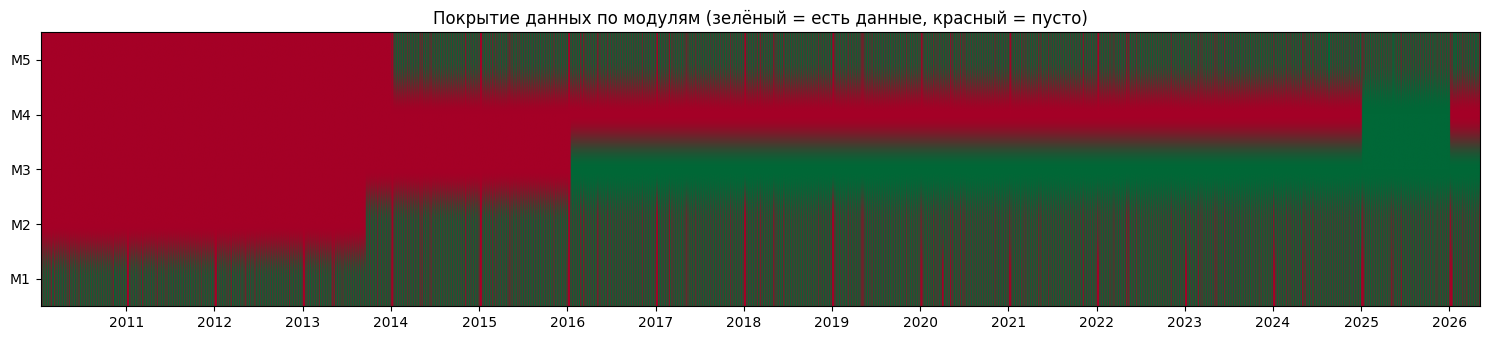

In [10]:
# --- Диагностика дыр в модулях M1..M5 ---
# Цель: понять, где у нас систематические пропуски по дате/модулю.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

assert "wide" in globals(), "Сначала запустите ячейку объединения модулей (wide)."

_w_diag = wide.copy()
_w_diag["date"] = pd.to_datetime(_w_diag["date"])
_w_diag = _w_diag.sort_values("date").reset_index(drop=True)

MODULES_DIAG = ("m1_", "m2_", "m3_", "m4_", "m5_")
# 1) Доля заполненности по модулям и в целом (по дням).
rows = []
for prefix in MODULES_DIAG:
    mod_cols = [c for c in _w_diag.columns if c.startswith(prefix)]
    if not mod_cols:
        continue
    block = _w_diag[mod_cols]
    coverage_day = block.notna().any(axis=1)
    rows.append({
        "module": prefix.rstrip("_"),
        "cols_total": len(mod_cols),
        "rows_total": len(_w_diag),
        "rows_with_any_data": int(coverage_day.sum()),
        "rows_full_missing": int((~coverage_day).sum()),
        "mean_cell_coverage_%": round(float(block.notna().mean().mean() * 100), 2),
        "first_data_date": str(_w_diag.loc[coverage_day, "date"].min().date()) if coverage_day.any() else "—",
        "last_data_date":  str(_w_diag.loc[coverage_day, "date"].max().date()) if coverage_day.any() else "—",
    })

cov_df = pd.DataFrame(rows)
print("Покрытие модулей данными:")
print(cov_df.to_string(index=False))

# 2) Гэп-репорт: внутри активного интервала ищем подряд идущие дни без данных >= GAP_THRESHOLD.
GAP_THRESHOLD = 14  # «странная дыра» = пустой блок > 2 недель внутри активного интервала
print("\nКрупные внутренние дыры (>14 подряд дней без данных):")
gap_rows = []
for prefix in MODULES_DIAG:
    mod_cols = [c for c in _w_diag.columns if c.startswith(prefix)]
    if not mod_cols:
        continue
    s = _w_diag[mod_cols].notna().any(axis=1).astype(int)
    if not s.any():
        continue
    lo = _w_diag.loc[s == 1, "date"].min()
    hi = _w_diag.loc[s == 1, "date"].max()
    mask_active = (_w_diag["date"] >= lo) & (_w_diag["date"] <= hi)
    sub = _w_diag.loc[mask_active, ["date"]].copy()
    sub["has"] = s[mask_active].values
    # Запускаем run-length по нулям.
    runs = []
    cur_start = None
    cur_len = 0
    for _, r in sub.iterrows():
        if r["has"] == 0:
            if cur_start is None:
                cur_start = r["date"]
            cur_len += 1
        else:
            if cur_start is not None and cur_len >= GAP_THRESHOLD:
                runs.append((cur_start, cur_start + pd.Timedelta(days=cur_len - 1), cur_len))
            cur_start, cur_len = None, 0
    if cur_start is not None and cur_len >= GAP_THRESHOLD:
        runs.append((cur_start, cur_start + pd.Timedelta(days=cur_len - 1), cur_len))
    for s_d, e_d, l in runs:
        gap_rows.append({
            "module": prefix.rstrip("_"),
            "gap_start": str(s_d.date()),
            "gap_end": str(e_d.date()),
            "days": l,
        })
if gap_rows:
    print(pd.DataFrame(gap_rows).to_string(index=False))
else:
    print("  не найдено")

# 3) Визуальный heatmap по дням: цвет = наличие данных в модуле.
fig, ax = plt.subplots(figsize=(15, 3.5))
active_prefixes = [p for p in MODULES_DIAG if any(c.startswith(p) for c in _w_diag.columns)]
matrix = np.zeros((len(active_prefixes), len(_w_diag)), dtype=float)
for i, prefix in enumerate(active_prefixes):
    mod_cols = [c for c in _w_diag.columns if c.startswith(prefix)]
    matrix[i, :] = _w_diag[mod_cols].notna().any(axis=1).astype(int).values

dates_num = mdates.date2num(_w_diag["date"].dt.to_pydatetime())
extent = [dates_num.min(), dates_num.max(), -0.5, len(active_prefixes) - 0.5]
ax.imshow(matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1, extent=extent, origin="lower")
ax.set_yticks(range(len(active_prefixes)))
ax.set_yticklabels([p.rstrip("_").upper() for p in active_prefixes])
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Покрытие данных по модулям (зелёный = есть данные, красный = пусто)")
plt.tight_layout()
plt.show()


In [11]:
# --- Анализ пропусков (по столбцам) ---
na_share = wide.isna().mean().sort_values(ascending=False)
na_cnt = wide.isna().sum()
summary = pd.DataFrame({"na_count": na_cnt, "na_share": na_share})
print("Топ-30 столбцов по доле NaN:")
print(summary.head(30).to_string())

print("Строки без единого признака модулей (все m*-столбцы NaN) — оценка:")
mcols = [c for c in wide.columns if c.startswith(("m1_", "m2_", "m3_", "m4_", "m5_"))]
if mcols:
    row_any = wide[mcols].notna().any(axis=1)
    print(f"Строк с хотя бы одним признаком: {row_any.sum()} / {len(wide)}")


Топ-30 столбцов по доле NaN:
                            na_count  na_share
date                               0  0.000000
m1_Flag_EndOfPeriod             1944  0.326065
m1_MaxRate                      4660  0.781617
m1_MinRate                      4660  0.781617
m1_fact                         1984  0.332774
m1_need                         1959  0.328581
m1_ruo                          1944  0.326065
m1_ruo_mad                      1944  0.326065
m1_shift                        1984  0.332774
m1_shift_mad                    3078  0.516270
m1_vol                          1961  0.328916
m2_Cover_ratio                  5776  0.968802
m2_Flag_Demand                  2795  0.468802
m2_MAD_score_cover              4253  0.713351
m2_MAD_score_rate_spread        5046  0.846360
m2_Rate_spread                  5776  0.968802
m2_Ключевая_ставка              2795  0.468802
m2_Размещение                   5776  0.968802
m2_Спрос                        5776  0.968802
m2_Средневзвешенная_ставка     

In [12]:
# --- Первые строки широкой таблицы ---
pd.set_option("display.max_columns", 40)
print(wide.head().to_string())


        date     m1_fact  m1_need    m1_shift  m1_ruo  m1_vol  m1_MinRate  m1_MaxRate  m1_shift_mad  m1_ruo_mad  m1_Flag_EndOfPeriod  m2_Ключевая_ставка  m2_Спрос  m2_Размещение  m2_Ставка_отсечения  m2_Средневзвешенная_ставка  m2_Срок  m2_Cover_ratio  m2_Rate_spread  m2_Flag_Demand  m2_MAD_score_cover  m2_MAD_score_rate_spread  m3_volume_offer  m3_volume_demand  m3_volume_placement  m3_cover_ratio  m3_yield_avg  m3_yield_spread  m3_flag_nedospros  m3_flag_perespros  m3_mad_score_cover  m3_mad_score_yield  m3_mad_score_yield_spread  m4_year  m4_month  m4_day  m4_n_events_html  m4_n_important  m4_tax_event_weight  m4_Акцизы  m4_Водный налог  m4_ЕНП  m4_ЕСХН  m4_Земельный налог  m4_Косвенные налоги  m4_НДПИ  m4_НДС  m4_НДФЛ  m4_НПД  m4_Налог на имущество организаций  m4_Налог на имущество физлиц  m4_Налог на прибыль  m4_Плата за НВОС  m4_Страхование от НС и ПЗ  m4_Страховые взносы  m4_Торговый сбор  m4_Транспортный налог  m4_Туристический налог  m4_УСН  m4_Экологический сбор  m4_m4_day_t

## EDA: обзор единого датасета `wide` (M1–M5)

Ниже — размерность, пропуски по модулям, динамика ключевых рядов (ликвидность ЦБ, репо/ставка, ОФЗ, M1), налоговый календарь (M4) и корреляции между важными числовыми признаками. Запускайте после построения `wide`.

**Робастные масштабы в пайплайне (проверка):** целевой teacher LSI использует скользящие **медиану и MAD** (`_robust_stress01` в ячейке LSI). Бустинги обучаются с **`sklearn.preprocessing.RobustScaler`** (медиана и IQR по каждому признаку). Модель **DLinear** также нормирует окно через **RobustScaler**. Это устойчивее к выбросам, чем z-score по среднему/σ.

**Графики ниже:** для наглядности ряды на рисунках 2–4 можно **подрезать хвосты по квантилям IQR** (правило Тьюки) — меняется только отображение, не исходная таблица `wide`.

=== Shape === (3050, 72)
Период: 2018-01-01 — 2026-05-08
Числовых столбцов: 71 | всего столбцов: 72

=== Пропуски по модулям (средняя доля NaN по столбцам) ===
module  n_cols  mean_na_share
    m4      28       0.880328
    m2      11       0.797347
    m1      10       0.419344
    m5      11       0.310492
    m3      11       0.038867

=== Топ-20 столбцов по доле NaN ===
m2_Спрос                             0.980328
m2_Срок                              0.980328
m2_Rate_spread                       0.980328
m2_Cover_ratio                       0.980328
m2_Ставка_отсечения                  0.980328
m2_Размещение                        0.980328
m2_Средневзвешенная_ставка           0.980328
m4_n_events_html                     0.880328
m4_m4_day_type_code                  0.880328
m4_Экологический сбор                0.880328
m4_УСН                               0.880328
m4_Плата за НВОС                     0.880328
m4_Налог на прибыль                  0.880328
m4_Налог на имущество физ

,count,mean,std,min,5%,25%,50%,75%,95%,max
m5_liquidity_deficit,2103.0,-2044.843319,2.995690e+03,-9928.000000,-7181.600000,-3345.300000,-2030.700000,-1181.350000,3433.120000,9.795000e+03
m5_liquidity_deficit_ex_corr,2103.0,-2203.248978,3.147535e+03,-9992.000000,-8306.200000,-3433.200000,-2340.500000,-1225.500000,3642.600000,9.942000e+03
m5_MAD_score_liquidity_deficit,2103.0,0.041086,1.871342e+00,-8.059661,-3.635224,-0.419802,0.070390,0.698276,3.280124,7.115911e+00
m5_MAD_score_treasury_pressure,2103.0,0.045533,1.824388e+01,-146.028011,-14.322289,-1.008655,-0.005245,0.654331,15.303232,1.560582e+02
m2_Ключевая_ставка,2102.0,1058.789248,5.408110e+02,425.000000,425.000000,700.000000,750.000000,1600.000000,2100.000000,2.100000e+03
m2_Cover_ratio,60.0,1.602829,5.125078e-01,1.000000,1.000000,1.229100,1.500746,1.900336,2.547412,3.070973e+00
m2_Rate_spread,60.0,-1755.488665,2.082560e+02,-2078.850100,-2078.758765,-1979.834050,-1682.917350,-1583.972400,-1484.967340,-1.435451e+03
m3_yield_avg,2347.0,9.455588,3.750875e+00,1.315173,4.883409,7.105000,8.300000,12.907001,16.247172,1.803008e+01
m3_cover_ratio,3048.0,0.927601,1.079429e+00,0.011259,0.066714,0.185101,0.416973,1.409760,3.028723,7.587518e+00
m3_mad_score_cover,3048.0,1.200241,5.383495e+00,-2.927264,-1.392657,-0.375870,0.000000,0.505704,6.614557,4.478579e+01


EDA: для графиков включена подрезка выбросов (Tukey IQR, K=1.5); сырые данные не трогаем.


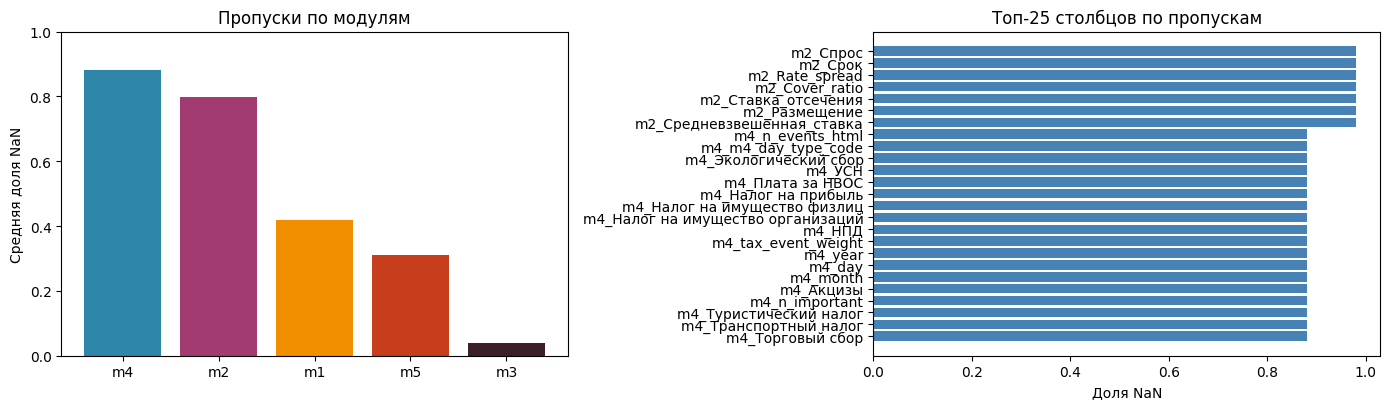

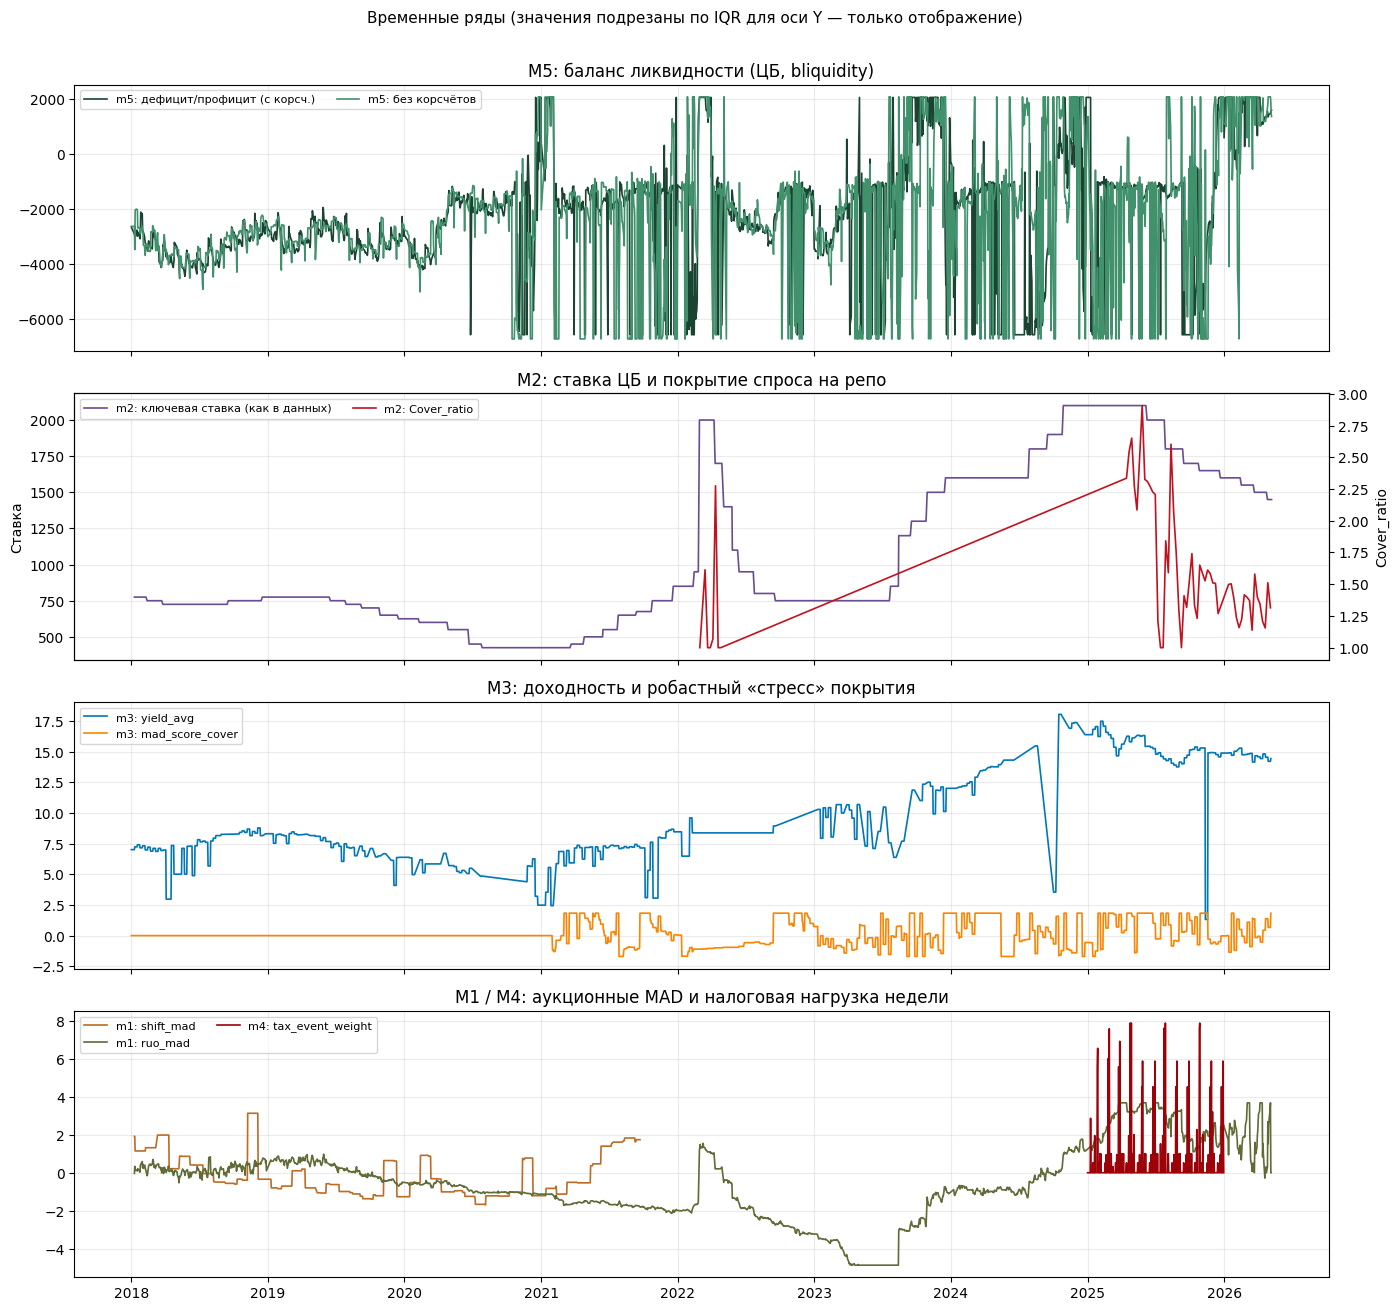

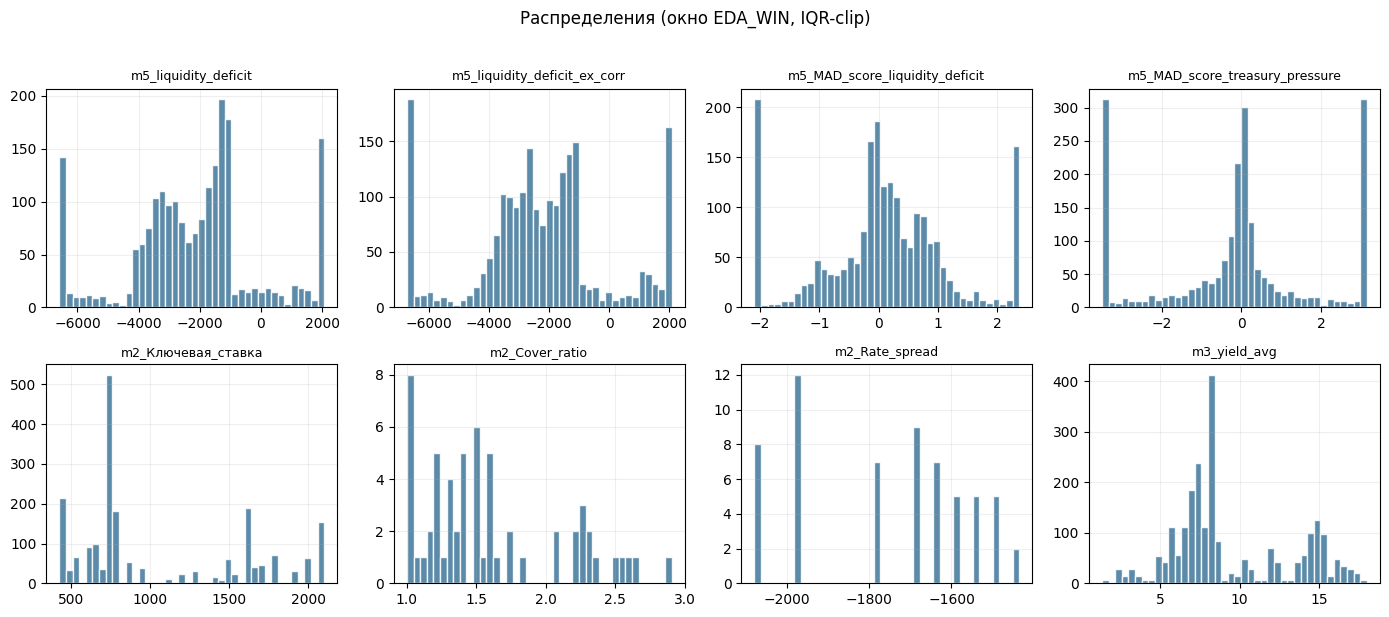

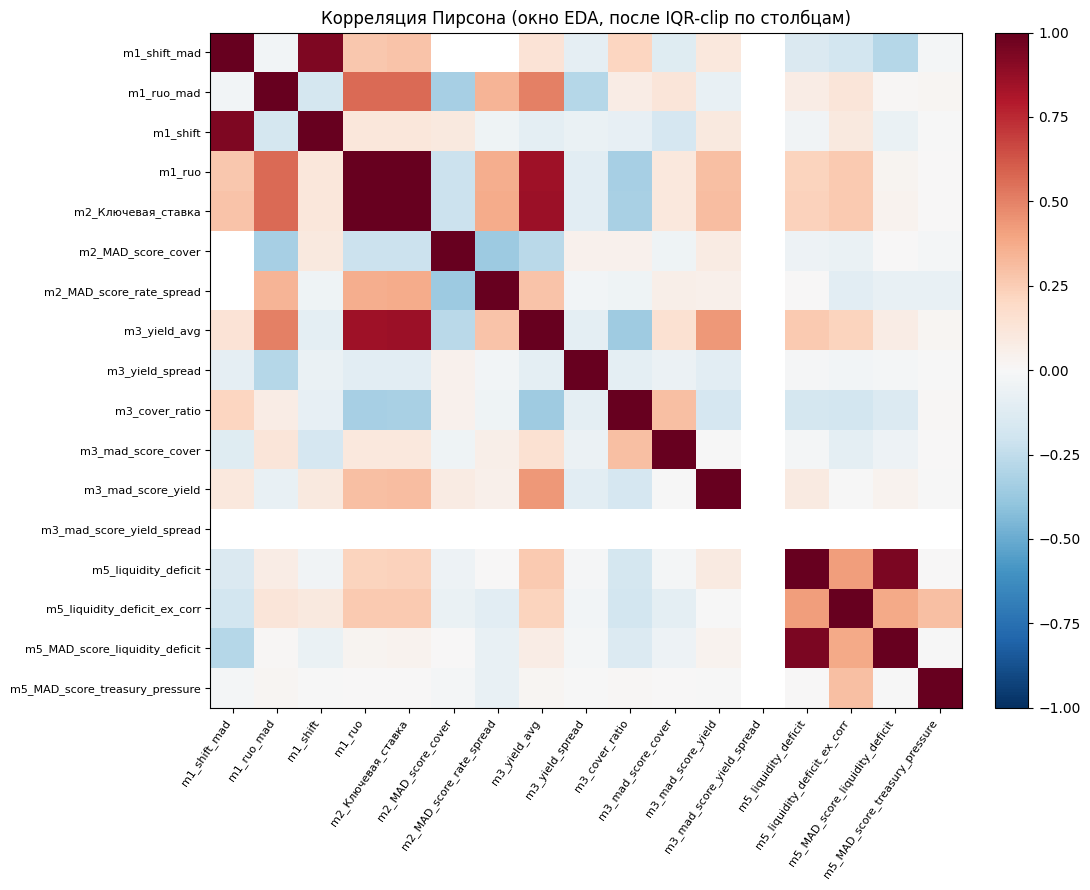


EDA готово. Измените EDA_WIN в начале ячейки для другого горизонта.


In [13]:
# --- EDA: таблицы + графики по `wide` ---
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EDA_WIN = "2018-01-01"  # окно для рядов и гистограмм (None = весь ряд)

# Подрезка выбросов по квартилям (Tukey IQR) только для графиков — таблица `wide` не изменяется.
EDA_CLIP_IQR = True
EDA_IQR_K = 1.5  # границы Q1 - K*IQR … Q3 + K*IQR; если IQR≈0 — fallback на 1% и 99% по окну

_w = wide.sort_values("date").reset_index(drop=True).copy()
if EDA_WIN is not None:
    _w = _w[_w["date"] >= pd.Timestamp(EDA_WIN)]

print("=== Shape ===", _w.shape)
print("Период:", _w["date"].min().date(), "—", _w["date"].max().date())
num_cols = _w.select_dtypes(include=[np.number]).columns.tolist()
print("Числовых столбцов:", len(num_cols), "| всего столбцов:", _w.shape[1])

# --- Пропуски по префиксам модулей ---
_prefix = ("m1_", "m2_", "m3_", "m4_", "m5_")
rows_mod = []
for p in _prefix:
    cols = [c for c in _w.columns if c.startswith(p)]
    if not cols:
        continue
    na = _w[cols].isna().mean().mean()
    rows_mod.append({"module": p.rstrip("_"), "n_cols": len(cols), "mean_na_share": float(na)})
mod_na = pd.DataFrame(rows_mod).sort_values("mean_na_share", ascending=False)
print("\n=== Пропуски по модулям (средняя доля NaN по столбцам) ===")
print(mod_na.to_string(index=False))

# Топ столбцов по доле пропусков
na_s = _w.isna().mean().sort_values(ascending=False)
print("\n=== Топ-20 столбцов по доле NaN ===")
print(na_s.head(20).to_string())

# --- Описательная статистика для «якорных» рядов ---
ANCHOR = [
    c
    for c in (
        "m5_liquidity_deficit",
        "m5_liquidity_deficit_ex_corr",
        "m5_MAD_score_liquidity_deficit",
        "m5_MAD_score_treasury_pressure",
        "m2_Ключевая_ставка",
        "m2_Cover_ratio",
        "m2_Rate_spread",
        "m3_yield_avg",
        "m3_cover_ratio",
        "m3_mad_score_cover",
        "m1_shift_mad",
        "m1_ruo_mad",
        "m4_tax_event_weight",
        "m4_n_important",
    )
    if c in _w.columns
]
if ANCHOR:
    desc = _w[ANCHOR].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
    print("\n=== describe() по ключевым столбцам ===")
    try:
        from IPython.display import display as _disp_eda

        _disp_eda(desc)
    except Exception:
        print(desc.to_string())


def _series_for_eda_plot(series: pd.Series) -> pd.Series:
    """Обрезка хвостов по IQR для визуализации (без изменения исходных данных)."""
    s = pd.to_numeric(series, errors="coerce")
    if not EDA_CLIP_IQR:
        return s
    m = s.notna()
    if m.sum() < 10:
        return s
    x = s[m]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = float(q3 - q1)
    if iqr > 1e-12:
        lo, hi = float(q1) - EDA_IQR_K * iqr, float(q3) + EDA_IQR_K * iqr
    else:
        lo, hi = float(x.quantile(0.01)), float(x.quantile(0.99))
    return s.clip(lower=lo, upper=hi)


if EDA_CLIP_IQR:
    print(
        f"EDA: для графиков включена подрезка выбросов (Tukey IQR, K={EDA_IQR_K}); сырые данные не трогаем."
    )


def _plot_exists(ax, dates, series, label, color):
    s = _series_for_eda_plot(series)
    m = s.notna()
    if m.sum() < 3:
        ax.text(0.5, 0.5, f"мало данных: {label}", ha="center", va="center", transform=ax.transAxes)
        return
    ax.plot(dates[m], s[m], label=label, color=color, linewidth=1.2)


# --- Рисунок 1: пропуски по модулям + топ столбцов ---
fig1, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 4.2))
if len(mod_na):
    ax_a.bar(mod_na["module"], mod_na["mean_na_share"], color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"][: len(mod_na)])
    ax_a.set_ylabel("Средняя доля NaN")
    ax_a.set_title("Пропуски по модулям")
    ax_a.set_ylim(0, min(1.0, mod_na["mean_na_share"].max() * 1.15 + 0.02))
topk = na_s.head(25)
ax_b.barh(topk.index[::-1], topk.values[::-1], color="steelblue")
ax_b.set_xlabel("Доля NaN")
ax_b.set_title("Топ-25 столбцов по пропускам")
plt.tight_layout()
plt.show()

# --- Рисунок 2: ключевые временные ряды (панели) ---
fig2, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
dt = _w["date"]

ax = axes[0]
if "m5_liquidity_deficit" in _w.columns:
    _plot_exists(ax, dt, _w["m5_liquidity_deficit"], "m5: дефицит/профицит (с корсч.)", "#1b4332")
if "m5_liquidity_deficit_ex_corr" in _w.columns:
    _plot_exists(ax, dt, _w["m5_liquidity_deficit_ex_corr"], "m5: без корсчётов", "#40916c")
ax.set_title("M5: баланс ликвидности (ЦБ, bliquidity)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.25)

ax = axes[1]
if "m2_Ключевая_ставка" in _w.columns:
    _plot_exists(ax, dt, _w["m2_Ключевая_ставка"], "m2: ключевая ставка (как в данных)", "#6a4c93")
ax.set_ylabel("Ставка")
ax.grid(True, alpha=0.25)
ax2 = ax.twinx()
if "m2_Cover_ratio" in _w.columns:
    _plot_exists(ax2, dt, _w["m2_Cover_ratio"], "m2: Cover_ratio", "#c1121f")
ax2.set_ylabel("Cover_ratio")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=8, ncol=2)
ax.set_title("M2: ставка ЦБ и покрытие спроса на репо")

ax = axes[2]
if "m3_yield_avg" in _w.columns:
    _plot_exists(ax, dt, _w["m3_yield_avg"], "m3: yield_avg", "#0077b6")
if "m3_mad_score_cover" in _w.columns:
    _plot_exists(ax, dt, _w["m3_mad_score_cover"], "m3: mad_score_cover", "#fb8500")
ax.set_title("M3: доходность и робастный «стресс» покрытия")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.25)

ax = axes[3]
if "m1_shift_mad" in _w.columns:
    _plot_exists(ax, dt, _w["m1_shift_mad"], "m1: shift_mad", "#bc6c25")
if "m1_ruo_mad" in _w.columns:
    _plot_exists(ax, dt, _w["m1_ruo_mad"], "m1: ruo_mad", "#606c38")
if "m4_tax_event_weight" in _w.columns:
    _plot_exists(ax, dt, _w["m4_tax_event_weight"], "m4: tax_event_weight", "#9d0208")
elif "m4_n_important" in _w.columns:
    _plot_exists(ax, dt, _w["m4_n_important"], "m4: n_important", "#9d0208")
ax.set_title("M1 / M4: аукционные MAD и налоговая нагрузка недели")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
fig2.suptitle(
    "Временные ряды"
    + (" (значения подрезаны по IQR для оси Y — только отображение)" if EDA_CLIP_IQR else ""),
    y=1.005,
    fontsize=11,
)
plt.tight_layout()
plt.show()

# --- Рисунок 3: гистограммы выбранных признаков (после отсечения окна) ---
hist_cols = [c for c in ANCHOR if c in _w.columns and c not in ("m4_n_important",)]
hist_cols = hist_cols[:8]
if hist_cols:
    fig3, axh = plt.subplots(2, 4, figsize=(14, 6))
    axh = axh.ravel()
    for i, col in enumerate(hist_cols):
        v = _series_for_eda_plot(_w[col]).dropna()
        axh[i].hist(v, bins=40, color="#457b9d", edgecolor="white", alpha=0.88)
        axh[i].set_title(col, fontsize=9)
        axh[i].grid(True, alpha=0.2)
    for j in range(len(hist_cols), len(axh)):
        axh[j].set_visible(False)
    fig3.suptitle(
        "Распределения (окно EDA_WIN"
        + (", IQR-clip" if EDA_CLIP_IQR else "")
        + ")",
        y=1.02,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

# --- Рисунок 4: корреляции (столбцы с достаточной заполненностью) ---
CORR_CANDIDATES = [
    c
    for c in (
        "m1_shift_mad",
        "m1_ruo_mad",
        "m1_shift",
        "m1_ruo",
        "m2_Ключевая_ставка",
        "m2_Cover_ratio",
        "m2_Rate_spread",
        "m2_MAD_score_cover",
        "m2_MAD_score_rate_spread",
        "m3_yield_avg",
        "m3_yield_spread",
        "m3_cover_ratio",
        "m3_mad_score_cover",
        "m3_mad_score_yield",
        "m3_mad_score_yield_spread",
        "m5_liquidity_deficit",
        "m5_liquidity_deficit_ex_corr",
        "m5_MAD_score_liquidity_deficit",
        "m5_MAD_score_treasury_pressure",
        "m4_tax_event_weight",
    )
    if c in wide.columns
]
min_non_na = max(80, int(len(_w) * 0.12))
usable = [c for c in CORR_CANDIDATES if _w[c].notna().sum() >= min_non_na]
usable = usable[:18]
if len(usable) >= 3:
    _wc = _w[usable].copy()
    if EDA_CLIP_IQR:
        for c in usable:
            _wc[c] = _series_for_eda_plot(_wc[c])
    C = _wc.corr(method="pearson", min_periods=30)
    fig4, axc = plt.subplots(figsize=(11, 9))
    im = axc.imshow(C.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    axc.set_xticks(range(len(usable)))
    axc.set_yticks(range(len(usable)))
    axc.set_xticklabels(usable, rotation=55, ha="right", fontsize=8)
    axc.set_yticklabels(usable, fontsize=8)
    axc.set_title(
        "Корреляция Пирсона (окно EDA"
        + (", после IQR-clip по столбцам" if EDA_CLIP_IQR else "")
        + ")"
    )
    plt.colorbar(im, ax=axc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print("Корреляционная матрица: слишком мало столбцов с данными в окне EDA.")

print("\nEDA готово. Измените EDA_WIN в начале ячейки для другого горизонта.")

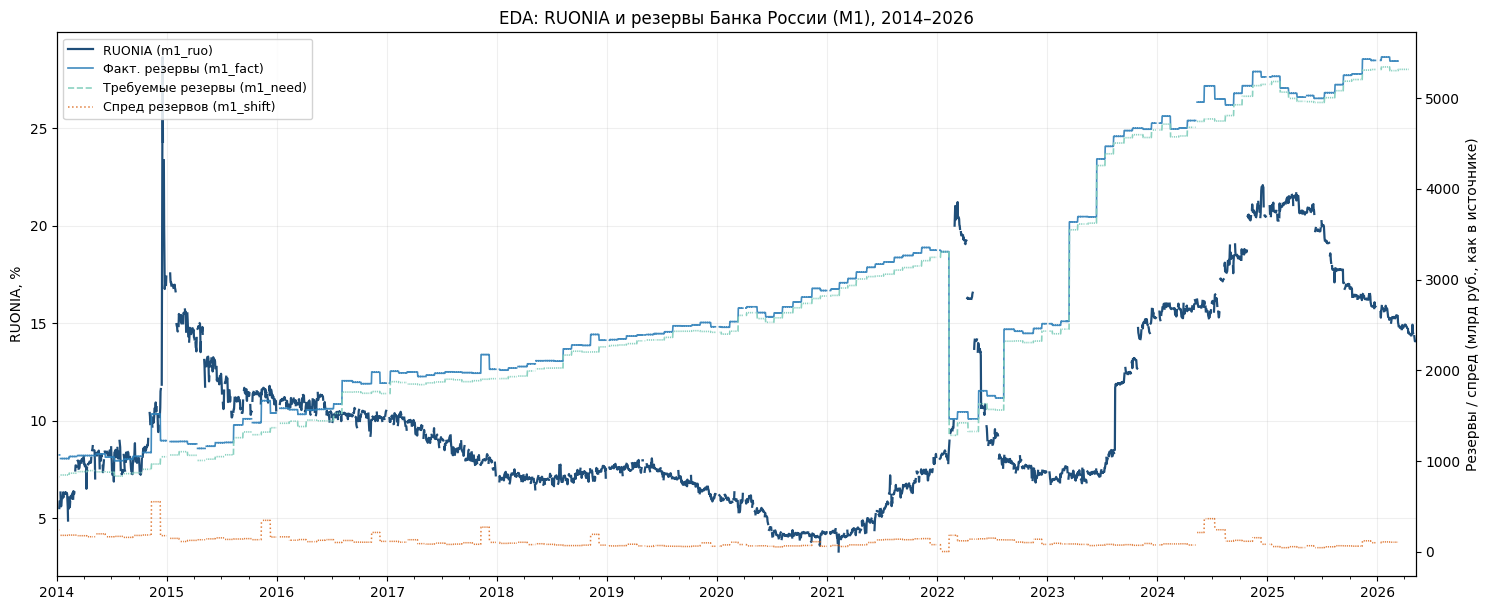

In [14]:
# --- EDA доп.: RUONIA и резервы в Банке России (2014–2026) ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

if "wide" in globals():
    _w_eda = wide.copy()
elif "wide_lsi" in globals():
    _w_eda = wide_lsi.copy()
else:
    raise RuntimeError("Не найден wide/wide_lsi. Сначала запустите ячейку объединения данных.")

_w_eda = _w_eda.copy()
_w_eda["date"] = pd.to_datetime(_w_eda["date"])
_w_eda = _w_eda.sort_values("date")
_w_eda = _w_eda[(_w_eda["date"] >= "2014-01-01") & (_w_eda["date"] <= "2026-12-31")]

need_cols = ["m1_ruo", "m1_fact", "m1_need", "m1_shift"]
miss = [c for c in need_cols if c not in _w_eda.columns]
if miss:
    raise RuntimeError(f"В wide отсутствуют колонки для графика M1: {miss}")

fig, ax1 = plt.subplots(figsize=(15, 6.2))
ax2 = ax1.twinx()

# Левая ось: RUONIA.
ax1.plot(
    _w_eda["date"], _w_eda["m1_ruo"],
    color="#1f4e79", linewidth=1.6, label="RUONIA (m1_ruo)",
)
ax1.set_ylabel("RUONIA, %")

# Правая ось: фактические и требуемые резервы + спред.
ax2.plot(
    _w_eda["date"], _w_eda["m1_fact"],
    color="#2c7fb8", linewidth=1.2, alpha=0.9, label="Факт. резервы (m1_fact)",
)
ax2.plot(
    _w_eda["date"], _w_eda["m1_need"],
    color="#7fcdbb", linewidth=1.2, alpha=0.9, linestyle="--", label="Требуемые резервы (m1_need)",
)
ax2.plot(
    _w_eda["date"], _w_eda["m1_shift"],
    color="#d95f0e", linewidth=1.1, alpha=0.8, linestyle=":", label="Спред резервов (m1_shift)",
)
ax2.set_ylabel("Резервы / спред (млрд руб., как в источнике)")

ax1.grid(True, alpha=0.2)
ax1.set_xlim(_w_eda["date"].min(), _w_eda["date"].max())
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_title("EDA: RUONIA и резервы Банка России (M1), 2014–2026")

# Общая легенда.
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.show()


## Агрегационный слой: LSI (Liquidity Stress Index, 0–100)

**Идея:** отдельной размеченной цели «истинного LSI» нет. **Опорная метка (teacher)** строится в первую очередь из **официальных рядов** раздела [bliquidity](https://www.cbr.ru/hd_base/bliquidity/) ЦБ: дефицит/профицит **с учётом корсчётов** и **без учёта корсчётов** (после лёгкого сглаживания уровней и робастной нормировки). Дополнительно — выпуклая комбинация сигналов **только M1–M4** (без производных признаков M5), чтобы календарь налогов, ставки и рынок ОФЗ давали объяснимый вклад без «подсказки» модели из M5.

**Важно (нет утечки):** колонки **`m5_*` не входят в матрицу признаков `X`** — модель не видит сырые данные ликвидности ЦБ и не может воспроизвести их дословно. Ряды bliquidity используются **только** для расчёта teacher.

Обучение: несколько бустингов **независимо** дают столбцы `LSI_<имя модели>`; **`LSI_ensemble`** — среднее по бустингам после постобработки. Сглаживание метки учителя, **Huber** (где поддерживается) и сглаживание прогнозов по времени — в ячейке обучения.


In [15]:
# --- Подготовка признаков и teacher-цели LSI [0, 100] ---
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

wide_lsi = wide.sort_values("date").reset_index(drop=True).copy()

# M4: Tax_Week_Flag, сезонность (неделя считается «нагружённой», если сумма весов типов налогов ≥ порога).
TAX_WEEK_WEIGHT_THRESHOLD = 0.85

if "m4_tax_event_weight" in wide_lsi.columns:
    tw_w = wide_lsi["m4_tax_event_weight"].fillna(0).astype(float)
    wide_lsi["Tax_Week_Flag"] = (
        tw_w.rolling(7, min_periods=1).max() >= TAX_WEEK_WEIGHT_THRESHOLD
    ).astype(np.int8)
elif "m4_n_important" in wide_lsi.columns:
    tw = wide_lsi["m4_n_important"].fillna(0).astype(float)
    wide_lsi["Tax_Week_Flag"] = (tw.rolling(7, min_periods=1).max() > 0).astype(np.int8)
else:
    wide_lsi["Tax_Week_Flag"] = np.int8(0)

doy = wide_lsi["date"].dt.dayofyear.astype(float)
wide_lsi["Seasonal_Factor_sin"] = np.sin(2 * np.pi * doy / 365.25)
wide_lsi["Seasonal_Factor_cos"] = np.cos(2 * np.pi * doy / 365.25)

# M4 (налоговый календарь ФНС) сильно коррелирует с m1/m2/m3 (тот же недельный паттерн платежей),
# поэтому мы НЕ кладём его признаки в X и НЕ добавляем в teacher. Налоговая нагрузка
# учитывается отдельным post-hoc слагаемым (см. ячейку с обучением).
EXCLUDE_M4_FROM_X = True

CORE_NO_M5 = [
    "m1_shift_mad", "m1_ruo_mad", "m1_Flag_EndOfPeriod",
    "m2_MAD_score_cover", "m2_MAD_score_rate_spread", "m2_Flag_Demand",
    "m3_mad_score_cover", "m3_mad_score_yield_spread",
    "m3_flag_nedospros", "m3_flag_perespros",
    "Seasonal_Factor_sin", "Seasonal_Factor_cos",
]


def _is_m4(col: str) -> bool:
    return str(col).startswith("m4_") or str(col) == "Tax_Week_Flag"


num_all = wide_lsi.select_dtypes(include=[np.number]).columns.tolist()
extra = [c for c in num_all if c not in CORE_NO_M5 and "date" not in str(c).lower()]
extra = [c for c in extra if not str(c).startswith("LSI")]
extra = [c for c in extra if not str(c).startswith("m5_")]
if EXCLUDE_M4_FROM_X:
    extra = [c for c in extra if not _is_m4(c)]

feature_cols = []
seen = set()
for c in CORE_NO_M5 + sorted(extra):
    if c in wide_lsi.columns and not str(c).startswith("m5_") and c not in seen:
        if EXCLUDE_M4_FROM_X and _is_m4(c):
            continue
        feature_cols.append(c)
        seen.add(c)

X = wide_lsi[feature_cols].copy()
if EXCLUDE_M4_FROM_X:
    _m4_in_x = [c for c in X.columns if _is_m4(c)]
    assert not _m4_in_x, f"В X не должно быть M4: {_m4_in_x}"
    print("M4 (налоги) исключён из X — будет учитываться post-hoc.")


def _relu_mad(s: pd.Series, cap: float = 4.0) -> np.ndarray:
    v = np.asarray(s.fillna(0.0), dtype=float)
    v = np.clip(v, 0.0, cap) / cap
    return v


def _robust_stress01(s: pd.Series, win: int = 756) -> np.ndarray:
    """Робастный z → [0,1]: для официальных уровней bliquidity (млрд руб.)."""
    s = pd.to_numeric(s, errors="coerce").ffill()
    min_p = max(30, win // 10)
    med = s.rolling(window=win, min_periods=min_p).median()
    mad = (s - med).abs().rolling(window=win, min_periods=min_p).median()
    z = (s - med) / (1.4826 * mad.replace(0, np.nan))
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-4.0, 4.0)
    return np.clip((z.to_numpy(dtype=float) / 8.0) + 0.5, 0.0, 1.0)


# --- Teacher: обязательные ряды с cbr.ru/hd_base/bliquidity (парсятся в ячейке M5) ---
liq_lv = wide_lsi["m5_liquidity_deficit"].astype(float).ffill()
ex_lv = wide_lsi["m5_liquidity_deficit_ex_corr"].astype(float).ffill()
liq_s = liq_lv.rolling(5, min_periods=1).mean()
ex_s = ex_lv.rolling(5, min_periods=1).mean()
liquidity_teacher = 0.6 * _robust_stress01(liq_s) + 0.4 * _robust_stress01(ex_s)

# --- Доп. сигнал только M1–M4 (без m5_* в teacher) ---
t_parts = []
w = []


def add_term(col, weight=1.0, cap=4.0):
    if col in wide_lsi.columns:
        t_parts.append(_relu_mad(wide_lsi[col], cap) * weight)
        w.append(weight)


add_term("m1_shift_mad", 1.0)
add_term("m1_ruo_mad", 1.0)
add_term("m2_MAD_score_cover", 1.0, cap=8.0)
add_term("m2_MAD_score_rate_spread", 1.0, cap=8.0)
add_term("m3_mad_score_cover", 1.0)
add_term("m3_mad_score_yield_spread", 1.0)

flags = []
if "m1_Flag_EndOfPeriod" in wide_lsi.columns:
    flags.append(wide_lsi["m1_Flag_EndOfPeriod"].fillna(0).astype(float) * 0.08)
if "m2_Flag_Demand" in wide_lsi.columns:
    flags.append(wide_lsi["m2_Flag_Demand"].fillna(0).astype(float) * 0.10)
if "m3_flag_nedospros" in wide_lsi.columns:
    flags.append(wide_lsi["m3_flag_nedospros"].fillna(0).astype(float) * 0.10)
# Tax_Week_Flag из teacher исключён: налоговая нагрузка применяется post-hoc к прогнозу LSI.

base = np.sum(t_parts, axis=0) / max(sum(w), 1e-9)
flag_bonus = np.sum(flags, axis=0) if flags else 0.0
m1m4_stress = np.clip(base + flag_bonus, 0.0, 1.0)

raw = np.clip(0.55 * liquidity_teacher + 0.45 * m1m4_stress, 0.0, None)
wide_lsi["_raw_stress_teacher"] = raw


# --- M4 (post-hoc): нагрузка налоговой недели в единицах LSI 0–100 ---
# Это НЕ признак модели и НЕ часть teacher. Применяется к итоговому прогнозу как добавка.
TAX_KICK_MAX = 6.0   # макс. добавка к LSI в пунктах за «тяжёлую» налоговую неделю
TAX_KICK_HALF = 1.0  # значение веса налогов, при котором добавка ≈ TAX_KICK_MAX/2 (сглаженная сатурация)


def _build_tax_kick(df: pd.DataFrame) -> np.ndarray:
    if "m4_tax_event_weight" in df.columns:
        w_tax = pd.to_numeric(df["m4_tax_event_weight"], errors="coerce").fillna(0.0).astype(float)
    elif "m4_n_important" in df.columns:
        w_tax = pd.to_numeric(df["m4_n_important"], errors="coerce").fillna(0.0).astype(float)
    else:
        return np.zeros(len(df), dtype=float)
    # «Окно» налоговой недели: максимум по последним 7 дням (платёж может прийтись на любой день).
    w7 = w_tax.rolling(7, min_periods=1).max().to_numpy(dtype=float)
    # Гладкая сатурация: x / (x + half) ∈ [0, 1) — без скачков.
    half = max(float(TAX_KICK_HALF), 1e-6)
    sat = w7 / (w7 + half)
    return float(TAX_KICK_MAX) * sat


wide_lsi["_m4_tax_kick"] = _build_tax_kick(wide_lsi)

print("Признаков в X:", len(feature_cols))
print("Первые 30:", feature_cols[:30])
print(
    "M4 post-hoc tax kick: max=%.1f, ненулевых дней=%d (доля=%.2f)"
    % (
        float(np.max(wide_lsi["_m4_tax_kick"])),
        int((wide_lsi["_m4_tax_kick"] > 0.05).sum()),
        float((wide_lsi["_m4_tax_kick"] > 0.05).mean()),
    )
)


M4 (налоги) исключён из X — будет учитываться post-hoc.
Признаков в X: 34
Первые 30: ['m1_shift_mad', 'm1_ruo_mad', 'm1_Flag_EndOfPeriod', 'm2_MAD_score_cover', 'm2_MAD_score_rate_spread', 'm2_Flag_Demand', 'm3_mad_score_cover', 'm3_mad_score_yield_spread', 'm3_flag_nedospros', 'm3_flag_perespros', 'Seasonal_Factor_sin', 'Seasonal_Factor_cos', 'm1_MaxRate', 'm1_MinRate', 'm1_fact', 'm1_need', 'm1_ruo', 'm1_shift', 'm1_vol', 'm2_Cover_ratio', 'm2_Rate_spread', 'm2_Ключевая_ставка', 'm2_Размещение', 'm2_Спрос', 'm2_Средневзвешенная_ставка', 'm2_Срок', 'm2_Ставка_отсечения', 'm3_cover_ratio', 'm3_mad_score_yield', 'm3_volume_demand']
M4 post-hoc tax kick: max=5.4, ненулевых дней=333 (доля=0.06)


## Аудит утечек и корреляции (`X` vs teacher)

**Причинность:** в фичах и сглаживании **не используются** окна с `center=True` (они подмешивают будущие дни). Teacher по bliquidity заполняется только **`ffill`**, робастная нормировка и rolling — только **назад включая текущий день**.

Далее — **корреляционная матрица** (подмножество признаков + `_raw_stress_teacher`), список **топ-|ρ|** с меткой учителя, и таблица **«признак из будущего»**: `corr(X.shift(-k), teacher_t)` должна быть умеренной (высокий прирост относительно k=0 у отдельных колонок — повод проверить происхождение признака).

**Известные неточности в апстриме (не исправлены здесь):** в блоке M1 для `m1_fact` / `m1_need` может использоваться **`bfill`**, то есть ранним дням подставляется **известное будущее** по отчётности — см. отдельную ячейку M1 при необходимости строгой реконструкции.

Топ 25 признаков по |corr(X, teacher)| (перед обучением, median-impute):

m1_vol                        0.2734
m2_Ключевая_ставка            0.2525
m3_flag_nedospros             0.2459
m1_ruo                        0.2418
m3_cover_ratio               -0.2407
m1_need                       0.2139
m3_volume_offer               0.2043
m1_fact                       0.1971
m3_yield_avg                  0.1895
m3_flag_perespros            -0.1843
m1_Flag_EndOfPeriod           0.1672
m3_volume_placement           0.1351
m2_Rate_spread               -0.1339
m2_Flag_Demand                0.1298
m2_Ставка_отсечения           0.1192
m3_volume_demand              0.1191
m2_Средневзвешенная_ставка    0.1190
m3_mad_score_cover            0.1142
m2_Cover_ratio                0.0978
m2_MAD_score_cover            0.0850
m3_mad_score_yield            0.0835
m1_MinRate                    0.0793
m1_MaxRate                    0.0730
Seasonal_Factor_cos           0.0622
m2_Спрос                      0.0573


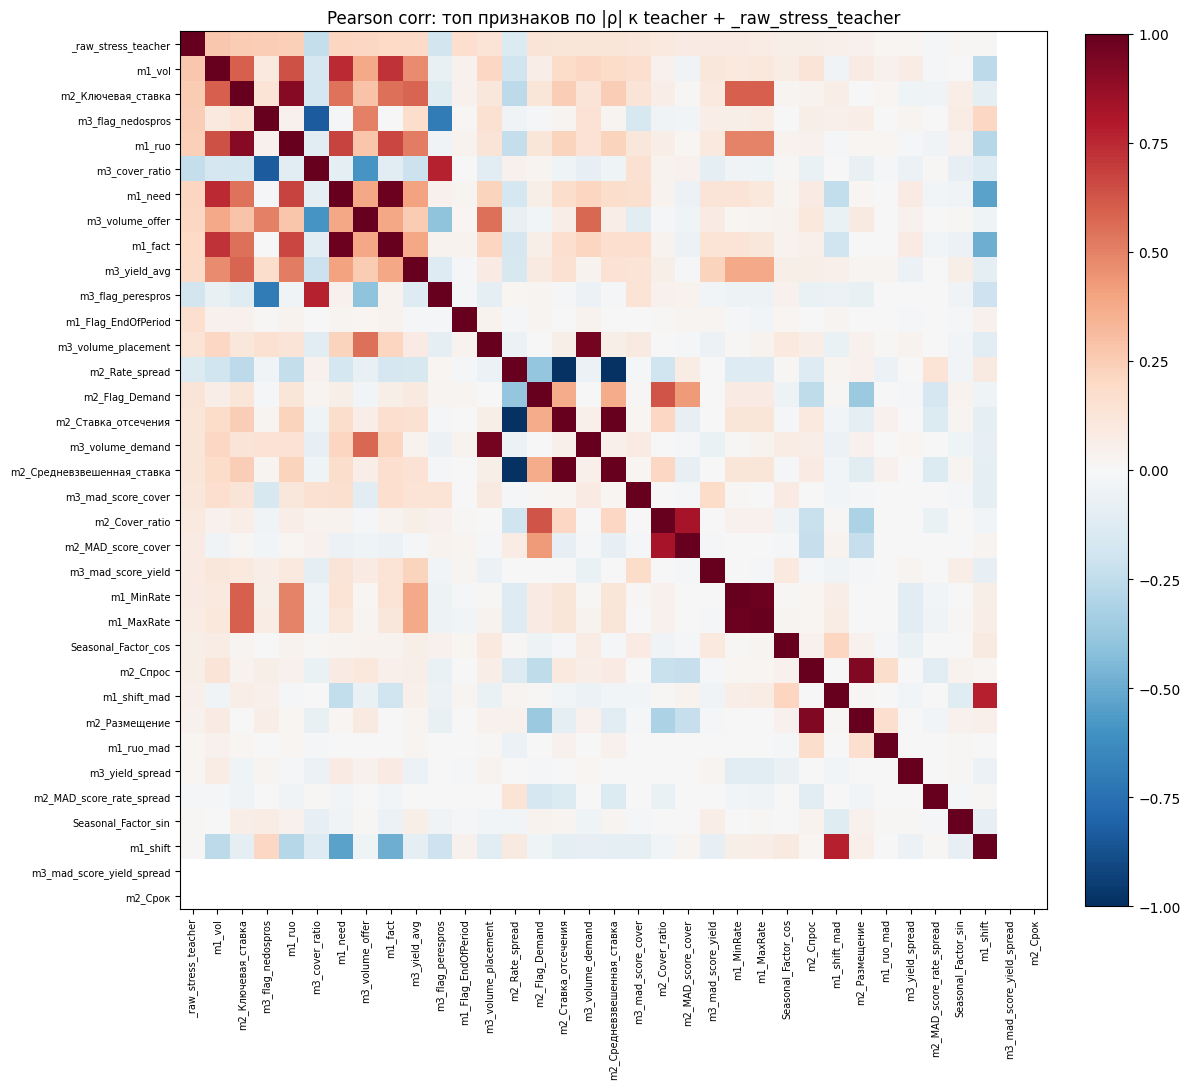


Признак = X.shift(-k) (на дату t подставлено значение с t+k). Корреляция с teacher на t:
 k_future_days  abs_corr_median  abs_corr_p90  abs_corr_max  worst_feature  worst_corr
             1         0.082930      0.222414      0.255835         m1_vol    0.255835
             3         0.077410      0.227677      0.235389         m1_vol    0.235389
             5         0.081229      0.223156      0.229559 m3_cover_ratio   -0.229559

Медиана |corr(X_t, teacher_t)| по всем фичам: 0.1191
  при k=1: ratio median_future / median_same_day = 0.697
  при k=3: ratio median_future / median_same_day = 0.650
  при k=5: ratio median_future / median_same_day = 0.682


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
# --- Корреляции и проверка на «подглядывание в будущее» по рядам ---
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

_imp_audit = SimpleImputer(strategy="median")
Z_aud = pd.DataFrame(
    _imp_audit.fit_transform(X),
    columns=feature_cols,
    index=X.index,
)
y_aud = wide_lsi["_raw_stress_teacher"].astype(float)

aligned_a = pd.concat([Z_aud, y_aud.rename("_raw_stress_teacher")], axis=1)
aligned_a = aligned_a.dropna(subset=["_raw_stress_teacher"])

C = aligned_a.corr(method="pearson", min_periods=200)
feat_only = [c for c in C.columns if c != "_raw_stress_teacher" and c in feature_cols]

# Топ-|ρ| с teacher для полного списка признаков
rho_te = C["_raw_stress_teacher"].reindex(feat_only).sort_values(key=lambda s: s.abs(), ascending=False)
print("Топ 25 признаков по |corr(X, teacher)| (перед обучением, median-impute):\n")
print(rho_te.head(25).round(4).to_string())

# Подматрица для теплокарты: teacher + топ-N фич по |ρ|
HEAT_N = min(34, len(feat_only))
top_for_heat = rho_te.head(HEAT_N).index.tolist()
heat_cols = ["_raw_stress_teacher"] + top_for_heat
CH = C.loc[heat_cols, heat_cols]

fig, ax = plt.subplots(figsize=(max(12, HEAT_N * 0.28), max(11, HEAT_N * 0.28)))
im = ax.imshow(CH.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(heat_cols)))
ax.set_yticks(np.arange(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=90, fontsize=7)
ax.set_yticklabels(heat_cols, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Pearson corr: топ признаков по |ρ| к teacher + _raw_stress_teacher")
plt.tight_layout()
plt.show()

# «Будущие» значения признака: shift(-k) поднимает наблюдения с даты t+k к строке t
leak_rows = []
for k in (1, 3, 5):
    Fut = aligned_a[feat_only].shift(-k)
    r = Fut.corrwith(aligned_a["_raw_stress_teacher"])
    leak_rows.append(
        dict(
            k_future_days=k,
            abs_corr_median=float(r.abs().median()),
            abs_corr_p90=float(r.abs().quantile(0.9)),
            abs_corr_max=float(r.abs().max()),
            worst_feature=str(r.abs().idxmax()),
            worst_corr=float(r.loc[r.abs().idxmax()]),
        )
    )

LEAKAGE_FUTURE_SHIFT_TABLE = pd.DataFrame(leak_rows)
print('\nПризнак = X.shift(-k) (на дату t подставлено значение с t+k). Корреляция с teacher на t:')
print(LEAKAGE_FUTURE_SHIFT_TABLE.to_string(index=False))

rho0_med = rho_te.abs().median()
print(f"\nМедиана |corr(X_t, teacher_t)| по всем фичам: {rho0_med:.4f}")
for _, row in LEAKAGE_FUTURE_SHIFT_TABLE.iterrows():
    ratio = row["abs_corr_median"] / max(rho0_med, 1e-9)
    print(f"  при k={int(row['k_future_days'])}: ratio median_future / median_same_day = {ratio:.3f}")


In [17]:
!pip install catboost
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


## Макро-события на графиках LSI (официальные RSS)

Якорные даты под вертикали собираются из **публичных лент регуляторов** (без логина и cookie):

| Источник | Содержание |
|----------|------------|
| **Банк России** | `RssPress`, `eventrss`, `RssNews` — пресс-релизы и события (ставка, ликвидность, надзор и т.п.). |
| **ФРС США** | Общая лента пресс-релизов с отбором только **монетарной** повестки (FOMC, monetary policy, ставки и т.д.), чтобы отсечь второстепенные заявления. |
| **ЕЦБ** | `press.xml` — пресс-релизы и заявления Совета управляющих. |
| **Опора** `CURATED_MACRO_DATES_*` | Фиксированные даты для длинного горизонта (шоки 2014–2024). |

В коде сохранены имена **`SMARTLAB_MACRO_EVENTS`** и **`add_smartlab_macro_vlines`**, чтобы не менять ячейки с графиками. **`SMARTLAB_CHAT_MESSAGES`** — пустая заглушка.


In [18]:
# --- Макро-события для вертикалей: официальные RSS (ЦБ РФ, ФРС США, ЕЦБ) + опорный список дат ---
# Источники публичные, без cookie. Переменные SMARTLAB_MACRO_EVENTS / add_smartlab_macro_vlines сохранены для графиков ниже.

import email.utils
import html
import re
import textwrap
import xml.etree.ElementTree as ET

import pandas as pd
import requests

# Сколько item'ов брать с каждой RSS-ленты (больше — глубже в историю, если фид отдаёт).
RSS_ITEMS_CAP = 200

# Официальные ленты: пресс и события регуляторов (актуально для ликвидности и ставок).
OFFICIAL_RSS_FEEDS: tuple[tuple[str, str], ...] = (
    ("https://www.cbr.ru/rss/RssPress", "cbr_press"),
    ("https://www.cbr.ru/rss/eventrss", "cbr_events"),
    ("https://www.cbr.ru/rss/RssNews", "cbr_news"),
    ("https://www.federalreserve.gov/feeds/press_all.xml", "fed_press"),
    ("https://www.ecb.europa.eu/rss/press.xml", "ecb_press"),
)

# Только события с сильным макро/системным эффектом на экономику РФ:
# крупные шоки и внеочередные/«ступенчатые» решения ЦБ по ключевой ставке.
CURATED_MACRO_DATES_DEFAULT = (
    ("2014-12-16", "Резкий рост ключевой ставки ЦБ до 17% (валютный кризис)"),
    ("2020-03-18", "COVID: стресс на рынке РФ"),
    ("2022-02-24", "Начало СВО / геополитический шок"),
    ("2022-02-28", "Заморозка резервов ЦБ; ключевая ставка 9.5% → 20% (внеочередно)"),
    ("2022-03-09", "Visa/Mastercard приостановили операции в РФ"),
    ("2022-09-21", "Частичная мобилизация"),
    ("2023-08-15", "Внеочередной подъём ключевой ставки 8.5% → 12% (рубль > 100 ₽/$)"),
    ("2024-06-12", "Санкции США против Мосбиржи/НКЦ — остановка биржевых торгов USD/EUR"),
    ("2024-10-25", "Ключевая ставка ЦБ: 19% → 21% (исторический максимум)"),
)

MACRO_KW = (
    ("ключев", 3),
    ("ставк", 3),
    ("цб ", 3),
    ("банк россии", 4),
    ("банком россии", 4),
    ("денежно-кредитн", 3),
    ("инфляц", 3),
    ("рубл", 2),
    ("курс", 2),
    ("валют", 2),
    ("санкц", 4),
    ("офз", 3),
    ("ликвидност", 3),
    ("репо", 2),
    ("ruonia", 2),
    ("руония", 2),
    ("дефолт", 4),
    ("эмбарго", 4),
    ("fomc", 7),
    ("federal open market", 6),
    ("federal reserve board", 3),
    ("interest rate", 4),
    ("monetary policy", 5),
    ("policy normalization", 4),
    ("discount rate", 3),
    ("ecb", 3),
    ("eurosystem", 3),
    ("governing council", 4),
    ("deposit facility", 3),
    ("refinancing opera", 2),
    ("quantitative easing", 3),
    ("taper", 3),
    ("treasury", 2),
    ("sanction", 3),
    ("inflation target", 3),
    ("совет директор", 5),
    ("решение совета директоров", 5),
    ("операций на открытом рынке", 4),
)


def _strip_tags(blob: str) -> str:
    if not blob:
        return ""
    t = html.unescape(re.sub(r"<[^>]+>", " ", blob))
    return " ".join(t.split())


def _kw_score(text: str) -> tuple[float, tuple[str, ...]]:
    s = text.lower()
    pts = 0.0
    hit: list[str] = []
    for needle, w in MACRO_KW:
        if needle in s:
            pts += float(w)
            hit.append(needle.strip())
    return pts, tuple(hit[:8])


def _parse_pub_day(pub_raw: str) -> pd.Timestamp | None:
    if not (pub_raw or "").strip():
        return None
    raw = pub_raw.strip()
    try:
        dt = email.utils.parsedate_to_datetime(raw)
        return pd.Timestamp(dt).tz_convert(None).normalize()
    except Exception:
        try:
            ts = pd.to_datetime(raw)
            if getattr(ts, "tzinfo", None) is not None:
                ts = ts.tz_convert(None)
            return pd.Timestamp(ts).normalize()
        except Exception:
            return None


def _fed_macro_hit(title: str, descr: str, category: str) -> bool:
    blob = f"{category} {title} {descr}".lower()
    keys = (
        "monetary policy",
        "fomc",
        "federal reserve issues",
        "interest rates",
        "discount rate",
        "money market",
        "balance sheet",
        "policy statement",
    )
    return any(k in blob for k in keys)


def _parse_rss_feed(
    sess: requests.Session,
    url: str,
    source_tag: str,
    *,
    items_cap: int,
) -> list[tuple[pd.Timestamp, str, float, str]]:
    """Список (день, заголовок, балл, метка источника)."""
    out: list[tuple[pd.Timestamp, str, float, str]] = []
    cap = max(15, int(items_cap))
    try:
        r = sess.get(
            url,
            timeout=45,
            headers={"User-Agent": "Mozilla/5.0 (compatible; LSI-notebook/1; macro-rss)"},
        )
        r.raise_for_status()
        root = ET.fromstring(r.content)
    except Exception as e:
        print(f"RSS {source_tag} ({url}): {e}")
        return out

    channel = root.find("channel")
    items = list(channel.findall("item")[:cap]) if channel is not None else root.findall(".//item")[:cap]
    for it in items:
        title = _strip_tags(it.findtext("title", default=""))
        descr = _strip_tags(it.findtext("description", default=""))
        pub_raw = it.findtext("pubDate", default="") or ""
        category = _strip_tags(it.findtext("category", default=""))
        combo = f"{title}. {descr}"
        day = _parse_pub_day(pub_raw)
        if day is None or not title.strip():
            continue

        if source_tag == "fed_press" and not _fed_macro_hit(title, descr, category):
            continue

        pts, _ = _kw_score(combo)
        if category and source_tag == "fed_press" and "monetary policy" in category.lower():
            pts += 8.0
        if "fomc" in title.lower() or "fomc" in descr.lower():
            pts += 6.0

        pts = pts * (1.0 + min(1.0, len(title) / 240.0))

        # Чуть ниже порог для ECB/событий ЦБ — иначе на график попадает слишком мало точек при max_events.
        floor_map = {"cbr_press": 2.7, "cbr_events": 2.35, "cbr_news": 2.85, "fed_press": 3.55, "ecb_press": 2.65}
        floor = floor_map.get(source_tag, 3.45)
        if pts < floor:
            continue

        label = title[:280] + ("…" if len(title) > 280 else "")
        out.append((day, label, pts, source_tag))
    return out


def build_macro_events_official_rss(
    date_min: pd.Timestamp | None,
    date_max: pd.Timestamp | None,
    max_events: int = 52,
    curated: tuple[tuple[str, str], ...] = CURATED_MACRO_DATES_DEFAULT,
) -> pd.DataFrame:
    d0 = pd.to_datetime(date_min).normalize() if date_min is not None else pd.Timestamp("2010-01-01")
    d1 = pd.to_datetime(date_max).normalize() if date_max is not None else pd.Timestamp.today()

    sess = requests.Session()
    sess.headers.update({"User-Agent": "Mozilla/5.0 (compatible; LSI-notebook/1; macro-rss)"})

    buckets: dict[pd.Timestamp, dict] = {}

    def add_row(day: pd.Timestamp, label: str, score: float, source: str):
        day = pd.Timestamp(day).normalize()
        if day < d0 or day > d1:
            return
        cur = buckets.get(day)
        if cur is None or score > cur["score"]:
            buckets[day] = {"event_date": day, "label": label, "score": score, "source": source}

    for ds, lbl in curated:
        add_row(pd.Timestamp(ds), lbl, 1000.0, "curated")

    for url, tag in OFFICIAL_RSS_FEEDS:
        for day_ev, lbl_ev, pts_ev, stag in _parse_rss_feed(sess, url, tag, items_cap=RSS_ITEMS_CAP):
            add_row(day_ev, lbl_ev, pts_ev, stag)

    df = pd.DataFrame(list(buckets.values())).sort_values(["score", "event_date"], ascending=[False, True])
    df = df.drop_duplicates(subset=["event_date"], keep="first").head(max_events)
    return df.sort_values("event_date").reset_index(drop=True)


def add_smartlab_macro_vlines(ax, events_df: pd.DataFrame, xmin=None, xmax=None, **style) -> int:
    """Рисует вертикали; возвращает число строк описания под графиком (для tight_layout(rect=…)).

    На линии — только номер снизу; расшифровка — текстом под областью осей (figure).
    """
    if events_df is None or getattr(events_df, "empty", True):
        return 0
    kw = dict(color="dimgray", alpha=0.6, linestyle="--", linewidth=3.6, zorder=2)
    kw.update(style)
    rows = []
    for _, r in events_df.iterrows():
        x = pd.Timestamp(r["event_date"])
        if xmin is not None and x < pd.Timestamp(xmin):
            continue
        if xmax is not None and x > pd.Timestamp(xmax):
            continue
        rows.append((x, str(r["label"]), str(r.get("source", ""))))

    rows.sort(key=lambda t: t[0])
    if not rows:
        return 0

    y0, _y1 = ax.get_ylim()
    fig = ax.figure

    for i, (x, lbl, src) in enumerate(rows, start=1):
        ax.axvline(x, **kw)
        ax.annotate(
            str(i),
            xy=(x, y0),
            xycoords=("data", "data"),
            xytext=(0, -12),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            color=kw["color"],
            alpha=0.9,
            zorder=kw["zorder"] + 3,
            clip_on=False,
        )

    caption_raw = [
        f"{i}. {x.strftime('%Y-%m-%d')} — {lbl}" + (f" ({src})" if src else "")
        for i, (x, lbl, src) in enumerate(rows, start=1)
    ]
    caption_wrapped: list[str] = []
    for line in caption_raw:
        caption_wrapped.extend(textwrap.wrap(line, width=118, break_long_words=False))

    cap = "\n".join(caption_wrapped)
    fig.text(
        0.02,
        0.01,
        cap,
        transform=fig.transFigure,
        fontsize=7,
        va="bottom",
        ha="left",
        color="#333333",
        linespacing=1.35,
        family="sans-serif",
    )
    return len(caption_wrapped)


_t0 = wide["date"].min() if "wide" in dir() else None
_t1 = wide["date"].max() if "wide" in dir() else None

print(
    "Макрособытия: официальные RSS — ЦБ РФ (RssPress, eventrss, RssNews), "
    "пресс-релизы ФРС (фильтр по ДКП/FOMC/ставкам), пресс ЕЦБ; без cookie."
)

SMARTLAB_CHAT_MESSAGES = pd.DataFrame(
    columns=["comment_id", "article_id", "room_title", "dt", "username", "text", "kw_score"]
)

# Удобная ручка: уменьшите для «чистого» отчёта, увеличьте (например 80) для плотной разметки.
MACRO_EVENTS_MAX = 12
SMARTLAB_MACRO_EVENTS = build_macro_events_official_rss(_t0, _t1, max_events=MACRO_EVENTS_MAX)

try:
    from IPython.display import display as _dsp

    _dsp(SMARTLAB_MACRO_EVENTS[["event_date", "label", "score", "source"]])
except Exception:
    print(SMARTLAB_MACRO_EVENTS[["event_date", "label", "score", "source"]].to_string(index=False))


Макрособытия: официальные RSS — ЦБ РФ (RssPress, eventrss, RssNews), пресс-релизы ФРС (фильтр по ДКП/FOMC/ставкам), пресс ЕЦБ; без cookie.


,event_date,label,score,source
0,2014-12-16,Резкий рост ключевой ставки ЦБ до 17% (валютны...,1000.0000,curated
1,2020-03-18,COVID: стресс на рынке РФ,1000.0000,curated
2,2022-02-24,Начало СВО / геополитический шок,1000.0000,curated
3,2022-02-28,Заморозка резервов ЦБ; ключевая ставка 9.5% → ...,1000.0000,curated
4,2022-03-09,Visa/Mastercard приостановили операции в РФ,1000.0000,curated
5,2022-09-21,Частичная мобилизация,1000.0000,curated
6,2023-08-15,Внеочередной подъём ключевой ставки 8.5% → 12%...,1000.0000,curated
7,2024-06-12,Санкции США против Мосбиржи/НКЦ — остановка би...,1000.0000,curated
8,2024-10-25,Ключевая ставка ЦБ: 19% → 21% (исторический ма...,1000.0000,curated
9,2026-03-18,Federal Reserve Board and Federal Open Market ...,44.7500,fed_press


Сравнение скейлеров (одинаковый HGB-shallow, holdout по времени):
  scaler  mae_test  rmse_test   r2_test  hf_jitter  mean_abs_d1
    none 29.138514  36.658772 -0.788152   5.841552     3.420095
  robust 29.138514  36.658772 -0.788152   5.841552     3.420095
standard 29.138514  36.658772 -0.788152   5.841552     3.420095
Масштабирование входов бустингов (после SimpleImputer median): robust (robust = sklearn.RobustScaler по медиане и IQR)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Дрожание прогноза на holdout (mean |Δ²| по времени; меньше — тише модель):
          model  hf_jitter_holdout  mae_holdout
xgb_pseudohuber           0.000000    27.895575
      cat_huber           1.122056     7.964196
     lgbm_huber           1.124487     6.857019
        hgb_abs           1.266344     7.088986
      gbr_huber           1.375296     7.154328


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Holdout: MAE без tax-kick = 9.689 | с tax-kick = 10.536


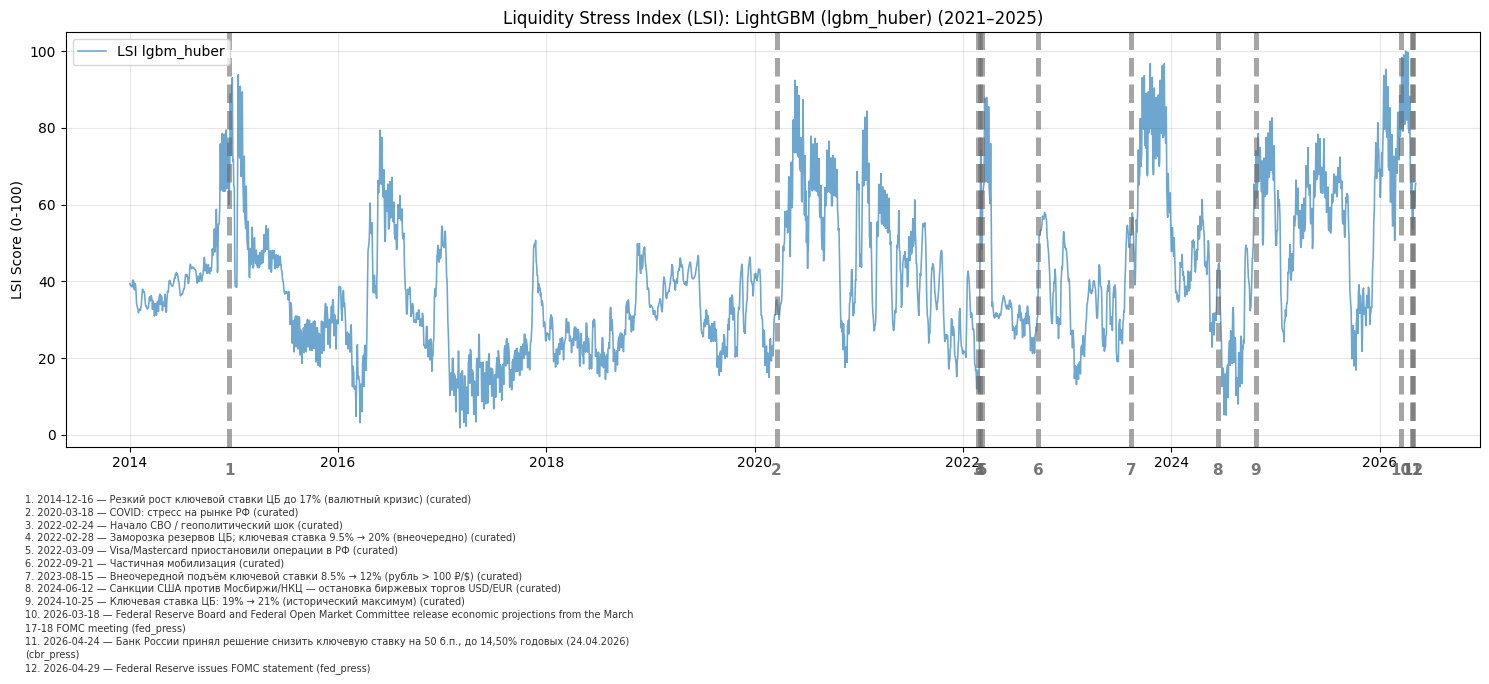

In [19]:
# --- Бустинги (Huber где доступно): teacher сглажен, прогнозы — постобработка по времени ---
import matplotlib.pyplot as plt

# Окно обучения/предсказания: 2016-01-01 .. 2026-12-31.
TRAIN_FROM = pd.Timestamp("2016-01-01")
TRAIN_TO = pd.Timestamp("2026-12-31")

# Для строк teacher нужны официальные уровни bliquidity (см. ячейку M5 — parse_m5_data).
key_sig_teacher = ["m5_liquidity_deficit", "m5_liquidity_deficit_ex_corr"]
if all(c in wide_lsi.columns for c in key_sig_teacher):
    present = wide_lsi[key_sig_teacher].notna().any(axis=1)
else:
    present = pd.Series(True, index=wide_lsi.index)

# Сужаем до целевого окна 2016–2026 (вне этого окна модель не учится и не предсказывает).
present &= (wide_lsi["date"] >= TRAIN_FROM) & (wide_lsi["date"] <= TRAIN_TO)
print(f"Окно обучения/предсказания: {TRAIN_FROM.date()} .. {TRAIN_TO.date()}  ({int(present.sum())} строк)")

X_fit = X.loc[present].copy()
assert not any(str(c).startswith("m5_") for c in X_fit.columns), "В X не должно быть столбцов m5_* (только teacher)"

y_raw = wide_lsi["_raw_stress_teacher"].values
y_raw_fit = y_raw[present.values]
dates_fit = wide_lsi.loc[present, "date"].reset_index(drop=True)

order = np.argsort(dates_fit.values)
n = len(order)
cut = int(n * 0.8)
train_idx = order[:cut]
test_idx = order[cut:]

raw_train = y_raw_fit[train_idx]
q05, q95 = np.quantile(raw_train, [0.05, 0.95])
span = max(q95 - q05, 1e-6)

def to_lsi_0_100(r: np.ndarray) -> np.ndarray:
    z = (r - q05) / span
    return np.clip(100.0 * z, 0.0, 100.0)


def _smooth_by_calendar(y: np.ndarray, dts: pd.Series, window: int) -> np.ndarray:
    """Причинное сглаживание: по отсортированному календарю trailing mean (только t и раньше), без center=True."""
    o = np.argsort(pd.to_datetime(dts).values)
    ys = pd.Series(y[o].astype(float))
    sm = ys.rolling(int(window), min_periods=1).mean().to_numpy()
    out = np.empty_like(y, dtype=float)
    out[o] = sm
    return np.clip(out, 0.0, 100.0)


TEACHER_SMOOTH_WINDOW = 7
POSTPROC_SMOOTH_WINDOW = 5

y_all = _smooth_by_calendar(to_lsi_0_100(y_raw_fit), dates_fit, TEACHER_SMOOTH_WINDOW)
y_train = y_all[train_idx]
y_test = y_all[test_idx]
X_train = X_fit.iloc[train_idx]
X_test = X_fit.iloc[test_idx]
dates_test_ord = dates_fit.iloc[test_idx].values
_order_test = np.argsort(dates_test_ord)


def postprocess_lsi(y: np.ndarray, d_calendar: pd.Series) -> np.ndarray:
    """Постобработка прогноза LSI: сглаживание по времени + [0, 100]."""
    return _smooth_by_calendar(np.clip(np.asarray(y, dtype=float), 0.0, 100.0), d_calendar, POSTPROC_SMOOTH_WINDOW)

# --- Масштабирование признаков: RobustScaler vs StandardScaler vs без скейлера ---
# По умолчанию — robust (медиана и IQR по признаку), устойчиво к выбросам во временных рядах с MAD/ставками.
# Для подбора по holdout верните SCALER_MODE = "auto".
SCALER_MODE = "robust"  # "robust" | "auto" | "none" | "standard"


def _pipe_with_scaler(est, scaler_name: str) -> Pipeline:
    steps = [("imp", SimpleImputer(strategy="median"))]
    if scaler_name == "robust":
        steps.append(("sc", RobustScaler(with_centering=True, with_scaling=True)))
    elif scaler_name == "standard":
        steps.append(("sc", StandardScaler()))
    elif scaler_name != "none":
        raise ValueError(scaler_name)
    steps.append(("m", est))
    return Pipeline(steps)


def _rmse(y_t, y_p):
    return float(np.sqrt(mean_squared_error(y_t, y_p)))


def _hf_noise(pred_sorted: np.ndarray) -> float:
    """Среднее |вторая разность| по времени — прокси «дрожания» прогноза (меньше → глаже)."""
    if len(pred_sorted) < 3:
        return float("nan")
    d2 = np.diff(np.diff(pred_sorted.astype(float)))
    return float(np.mean(np.abs(d2)))


_scaler_candidates = ["none", "robust", "standard"]
_probe = HistGradientBoostingRegressor(max_depth=5, learning_rate=0.06, max_iter=400, random_state=42)
_rows_sc = []
for sn in _scaler_candidates:
    p = _pipe_with_scaler(clone(_probe), sn)
    p.fit(X_train, y_train)
    pred_t = np.clip(p.predict(X_test), 0.0, 100.0)
    pred_sorted = pred_t[_order_test]
    _rows_sc.append(
        dict(
            scaler=sn,
            mae_test=float(mean_absolute_error(y_test, pred_t)),
            rmse_test=_rmse(y_test, pred_t),
            r2_test=float(r2_score(y_test, pred_t)),
            hf_jitter=_hf_noise(pred_sorted),
            mean_abs_d1=float(np.mean(np.abs(np.diff(pred_sorted)))) if len(pred_sorted) > 1 else float("nan"),
        )
    )
_scaler_compare = pd.DataFrame(_rows_sc).sort_values(["mae_test", "hf_jitter"], ascending=[True, True])
print("Сравнение скейлеров (одинаковый HGB-shallow, holdout по времени):")
print(_scaler_compare.to_string(index=False))
if SCALER_MODE == "auto":
    CHOSEN_SCALER = str(_scaler_compare.iloc[0]["scaler"])
    print("SCALER_MODE=auto → выбран:", CHOSEN_SCALER)
else:
    CHOSEN_SCALER = SCALER_MODE
    if CHOSEN_SCALER not in _scaler_candidates:
        raise ValueError("SCALER_MODE должен быть one of " + str(_scaler_candidates + ["auto"]))

def make_pipe(est):
    return _pipe_with_scaler(est, CHOSEN_SCALER)


print(
    "Масштабирование входов бустингов (после SimpleImputer median):",
    CHOSEN_SCALER,
    "(robust = sklearn.RobustScaler по медиане и IQR)" if CHOSEN_SCALER == "robust" else "",
)

HUBER_DELTA = 5.0  # общий масштаб для псевдо-Хьюбера / delta в деревьях (в единицах LSI 0–100)

# --- Регуляризация весов листьев и подвыборки (чтобы прогноз не «убегал»/не шкалил) ---
# Идея: ограничить влияние одиночного листа (большие L2/min_samples), уменьшить шаг и оставить subsample
# для бэггинга. Эти настройки обычно резко снижают «дрожание» и резкие выбросы прогноза.
LEAF_L2 = 1.5         # L2 на веса листьев (HGB/XGB/LGBM)
LEAF_L1 = 0.0         # L1 на веса листьев (XGB/LGBM); включайте при нужде в селекции
LEAF_MIN_SAMPLES = 40 # min_samples_leaf / min_child_samples / min_child_weight
SUBSAMPLE_ROW = 0.85  # подвыборка строк
SUBSAMPLE_COL = 0.85  # подвыборка признаков

models = {}
models["hgb_abs"] = make_pipe(
    HistGradientBoostingRegressor(
        loss="absolute_error",
        max_depth=5,
        learning_rate=0.04,
        max_iter=400,
        l2_regularization=LEAF_L2,
        min_samples_leaf=LEAF_MIN_SAMPLES,
        max_leaf_nodes=31,
        random_state=41,
    )
)
models["gbr_huber"] = make_pipe(
    GradientBoostingRegressor(
        loss="huber",
        alpha=0.9,
        n_estimators=320,
        max_depth=4,
        learning_rate=0.04,
        min_samples_leaf=LEAF_MIN_SAMPLES,
        subsample=SUBSAMPLE_ROW,
        random_state=42,
    )
)

try:
    from xgboost import XGBRegressor

    models["xgb_pseudohuber"] = make_pipe(
        XGBRegressor(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.035,
            random_state=45,
            n_jobs=-1,
            verbosity=0,
            objective="reg:pseudohubererror",
            pseudohuber_delta=HUBER_DELTA,
            reg_lambda=LEAF_L2,
            reg_alpha=LEAF_L1,
            min_child_weight=float(LEAF_MIN_SAMPLES),
            subsample=SUBSAMPLE_ROW,
            colsample_bytree=SUBSAMPLE_COL,
            max_delta_step=2.0,  # ограничивает шаг по листу (≈ clipping веса) → стабильнее
        )
    )
except Exception as _xe:
    print("XGBoost (pseudo-Huber) не подключился:", _xe)

try:
    import lightgbm as lgb

    models["lgbm_huber"] = make_pipe(
        lgb.LGBMRegressor(
            objective="huber",
            alpha=HUBER_DELTA,
            n_estimators=500,
            learning_rate=0.035,
            max_depth=-1,
            num_leaves=31,
            min_child_samples=LEAF_MIN_SAMPLES,
            reg_lambda=LEAF_L2,
            reg_alpha=LEAF_L1,
            subsample=SUBSAMPLE_ROW,
            subsample_freq=1,
            colsample_bytree=SUBSAMPLE_COL,
            random_state=46,
            verbose=-1,
        )
    )
except Exception as _le:
    print("LightGBM (huber) не подключился:", _le)

try:
    from catboost import CatBoostRegressor

    models["cat_huber"] = make_pipe(
        CatBoostRegressor(
            iterations=500,
            depth=6,
            learning_rate=0.035,
            loss_function="Huber:delta=" + str(HUBER_DELTA),
            l2_leaf_reg=8.0,
            random_strength=1.0,
            bagging_temperature=1.0,
            random_seed=47,
            verbose=0,
            thread_count=-1,
        )
    )
except Exception as e:
    print("CatBoost (Huber) не подключился:", e)

# --- DLinear (thuml/Time-Series-Library): скользящее окно по ряду [X | teacher] ---
# Совместимость с Google Colab: cwd обычно /content; репозиторий подтягиваем при отсутствии.
import sys
import subprocess
from pathlib import Path
from sklearn.preprocessing import RobustScaler

_TSL = (Path.cwd() / "Time-Series-Library").resolve()
if not _TSL.is_dir():
    try:
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/thuml/Time-Series-Library.git",
                str(_TSL),
            ],
            check=True,
            capture_output=True,
            text=True,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, OSError) as _e:
        print(
            "Не удалось получить Time-Series-Library (нужен git или уже есть папка). Colab: !git clone ... или загрузите репозиторий в сессию."
        )
        if isinstance(_e, subprocess.CalledProcessError) and _e.stderr:
            print(_e.stderr.strip())
if _TSL.is_dir() and str(_TSL) not in sys.path:
    sys.path.insert(0, str(_TSL))


class DLinearLSIWrapper:
    """Обёртка под интерфейс .fit(X, y) / .predict(X); даты берутся из wide_lsi по индексу X."""

    def __init__(self, wide_lsi_df, seq_len=32, label_len=16, pred_len=1, train_epochs=15, batch_size=64, lr=1e-3,
                 weight_decay=1e-3, grad_clip=1.0):
        self.wide_lsi = wide_lsi_df
        self.seq_len = int(seq_len)
        self.label_len = int(label_len)
        self.pred_len = int(pred_len)
        self.train_epochs = int(train_epochs)
        self.batch_size = int(batch_size)
        self.lr = float(lr)
        self.weight_decay = float(weight_decay)  # L2 на веса DLinear
        self.grad_clip = float(grad_clip)        # clip нормы градиента
        self.imputer = SimpleImputer(strategy="median")
        self.scaler = RobustScaler(with_centering=True, with_scaling=True)
        self._model = None
        self._device = None
        self._enc_in = None
        self._feat_cols = None
        self._idx_by_date = None
        self._Zn = None
        self._dates_ord = None

    def _acquire_device(self):
        import torch
        if torch.cuda.is_available():
            return torch.device("cuda")
        if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")

    def fit(self, X, y):
        import torch
        import torch.nn as nn
        from models.DLinear import Model as DLinearModel

        self._feat_cols = list(X.columns)
        self._device = self._acquire_device()
        dates = self.wide_lsi.loc[X.index, "date"].map(pd.Timestamp)
        idx_sorted = np.argsort(dates.values)
        X_imp = self.imputer.fit_transform(X).astype(np.float32)
        y_col = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        Z = np.concatenate([X_imp, y_col], axis=1)
        Z_s = Z[idx_sorted]
        Zn = self.scaler.fit_transform(Z_s).astype(np.float32)
        n, c = Zn.shape
        self._enc_in = c
        sl, ll, pl = self.seq_len, self.label_len, self.pred_len
        xs, ys = [], []
        n_win = n - sl - pl + 1
        for s_begin in range(max(0, n_win)):
            s_end = s_begin + sl
            r_begin = s_end - ll
            r_end = r_begin + ll + pl
            xs.append(Zn[s_begin:s_end])
            ys.append(Zn[r_begin:r_end])
        if len(xs) == 0:
            raise ValueError("DLinear: недостаточно точек для окон (уменьшите seq_len).")
        Xw = torch.tensor(np.stack(xs), dtype=torch.float32)
        Yw = torch.tensor(np.stack(ys), dtype=torch.float32)
        mark_f = 4
        Xmark = torch.zeros(Xw.shape[0], sl, mark_f)
        Ymark = torch.zeros(Yw.shape[0], ll + pl, mark_f)
        class _Cfg:
            pass
        cfg = _Cfg()
        cfg.task_name = "long_term_forecast"
        cfg.seq_len = sl
        cfg.pred_len = pl
        cfg.enc_in = c
        cfg.moving_avg = min(25, max(3, sl - 1))

        self._model = DLinearModel(cfg).to(self._device)
        opt = torch.optim.AdamW(self._model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        crit = nn.SmoothL1Loss(beta=1.0)  # робастная Хьюбер-подобная — реже даёт «убегающие» веса
        self._model.train()
        ds = torch.utils.data.TensorDataset(Xw, Yw, Xmark, Ymark)
        dl = torch.utils.data.DataLoader(ds, batch_size=min(self.batch_size, len(ds)), shuffle=True, drop_last=False)
        for _ in range(self.train_epochs):
            for bx, by, bxm, bym in dl:
                bx = bx.to(self._device)
                by = by.to(self._device)
                bxm = bxm.to(self._device)
                bym = bym.to(self._device)
                dec_inp_b = torch.cat([by[:, :ll, :], torch.zeros(by.shape[0], pl, c, device=self._device)], dim=1)
                opt.zero_grad()
                out = self._model(bx, bxm, dec_inp_b, bym)
                pred = out[:, -pl:, -1:]
                true = by[:, -pl:, -1:]
                loss = crit(pred, true)
                loss.backward()
                if self.grad_clip and self.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self._model.parameters(), self.grad_clip)
                opt.step()

        d_ord = dates.values[idx_sorted]
        self._dates_ord = pd.Series(d_ord).map(pd.Timestamp)
        self._idx_by_date = {pd.Timestamp(t): i for i, t in enumerate(self._dates_ord)}
        self._Zn = Zn
        return self

    def _window(self, j):
        sl = self.seq_len
        Zn = self._Zn
        if j <= 0:
            return np.tile(Zn[0:1], (sl, 1)).astype(np.float32)
        a = max(0, j - sl)
        w = Zn[a:j]
        if w.shape[0] < sl:
            pad = np.tile(Zn[0:1], (sl - w.shape[0], 1))
            w = np.vstack([pad, w])
        return w.astype(np.float32)

    def _forward_one(self, win):
        import torch
        sl, ll, pl, c = self.seq_len, self.label_len, self.pred_len, self._enc_in
        mark_f = 4
        bx = torch.from_numpy(win).view(1, sl, c).float().to(self._device)
        bxm = torch.zeros(1, sl, mark_f, device=self._device)
        bym = torch.zeros(1, ll + pl, mark_f, device=self._device)
        y_dummy = np.tile(win[-1:], (ll + pl, 1)).astype(np.float32)
        by = torch.from_numpy(y_dummy).view(1, ll + pl, c).float().to(self._device)
        dec_inp = torch.cat([by[:, :ll, :], torch.zeros(1, pl, c, device=self._device)], dim=1)
        self._model.eval()
        with torch.no_grad():
            out = self._model(bx, bxm, dec_inp, bym)
            zhat = out[0, -1, -1].item()
        zrow = np.zeros((1, c))
        zrow[0, -1] = zhat
        yhat = self.scaler.inverse_transform(zrow)[0, -1]
        return float(yhat)

    def predict(self, X):
        out = np.zeros(len(X), dtype=float)
        for r, idx in enumerate(X.index):
            d = pd.Timestamp(self.wide_lsi.loc[idx, "date"])
            j = self._idx_by_date.get(d)
            if j is None:
                out[r] = np.nan
                continue
            win = self._window(j)
            try:
                out[r] = self._forward_one(win)
            except Exception:
                out[r] = np.nan
        med = np.nanmedian(out)
        if not np.isfinite(med):
            med = 50.0
        out = np.where(np.isfinite(out), out, med)
        return out


if _TSL.is_dir():
    models["dlinear_tsl"] = DLinearLSIWrapper(wide_lsi, seq_len=32, label_len=16, train_epochs=15)
else:
    print("DLinear пропущен: ожидается репозиторий Time-Series-Library в", _TSL)

# --- Обучение, контроль «шума» на holdout, график окна обучения ---
mask_plot = (wide_lsi["date"] >= TRAIN_FROM) & (wide_lsi["date"] <= TRAIN_TO)
plot_data = wide_lsi.loc[mask_plot].copy()
X_plot = X.loc[mask_plot]
plot_dates = plot_data["date"].reset_index(drop=True)

plt.figure(figsize=(15, 7))
final_models = {}
for name, pipe in models.items():
    if name == "dlinear_tsl":
        try:
            pipe.fit(X_fit, y_all)
            final_models[name] = pipe
        except Exception as _de:
            print("DLinear (Time-Series-Library): обучение не удалось:", _de)
            continue
    else:
        pipe.fit(X_fit, y_all)
        final_models[name] = pipe

boost_names = [k for k in final_models if k != "dlinear_tsl"]
noise_rows = []

for nm in boost_names:
    m = final_models[nm]
    pred_te_raw = np.clip(np.asarray(m.predict(X_test), dtype=float), 0.0, 100.0)
    pred_te = postprocess_lsi(pred_te_raw, dates_fit.iloc[test_idx])
    pred_sorted = pred_te[_order_test]
    noise_rows.append(
        dict(
            model=nm,
            hf_jitter_holdout=float(_hf_noise(pred_sorted)),
            mae_holdout=float(mean_absolute_error(y_test, pred_te)),
        )
    )
    # Only plot LightGBM boosting result
    if nm == "lgbm_huber":
        raw_plot = np.clip(m.predict(X_plot), 0.0, 100.0)
        pp_plot = postprocess_lsi(raw_plot, plot_dates)
        plt.plot(plot_data["date"], pp_plot, label="LSI " + nm, alpha=0.65, linewidth=1.15)

_noise_df = pd.DataFrame(noise_rows).sort_values(["hf_jitter_holdout", "mae_holdout"], ascending=[True, True])
print("Дрожание прогноза на holdout (mean |Δ²| по времени; меньше — тише модель):")
print(_noise_df.to_string(index=False))

stack_plot = []
stack_all_pp = []
for nm in boost_names:
    raw_p = np.clip(final_models[nm].predict(X_plot), 0.0, 100.0)
    stack_plot.append(postprocess_lsi(raw_p, plot_dates))
for nm in boost_names:
    raw_f = np.clip(final_models[nm].predict(X_fit), 0.0, 100.0)
    stack_all_pp.append(postprocess_lsi(raw_f, dates_fit))

lsi_ens_plot = np.mean(stack_plot, axis=0)
# plt.plot(plot_data["date"], lsi_ens_plot, color="black", linewidth=2.8, label="Ensemble boostings") # Commented out ensemble plot

wide_lsi.loc[present, "LSI_teacher"] = y_all
for nm, col_pp in zip(boost_names, stack_all_pp):
    wide_lsi.loc[present, "LSI_" + nm] = col_pp
wide_lsi.loc[present, "LSI_ensemble"] = np.mean(stack_all_pp, axis=0)

if "dlinear_tsl" in final_models:
    wide_lsi.loc[present, "LSI_dlinear_tsl"] = postprocess_lsi(
        np.clip(final_models["dlinear_tsl"].predict(X_fit), 0.0, 100.0),
        dates_fit,
    )

# --- Post-hoc M4: налоговая нагрузка как добавка к LSI (а не как признак модели) ---
# kick уже посчитан в `wide_lsi["_m4_tax_kick"]`. Применяем к LSI без выхода из [0, 100].
def apply_tax_kick(lsi_pred: np.ndarray, kick: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(lsi_pred, dtype=float) + np.asarray(kick, dtype=float), 0.0, 100.0)


_kick_full = wide_lsi["_m4_tax_kick"].to_numpy(dtype=float)
wide_lsi["LSI_ensemble_tax_adj"] = apply_tax_kick(
    wide_lsi["LSI_ensemble"].to_numpy(dtype=float),
    _kick_full,
)

# Метрики до/после tax kick на holdout (только для информации).
try:
    _ens_te = np.mean(
        [postprocess_lsi(np.clip(m.predict(X_test), 0.0, 100.0), dates_fit.iloc[test_idx]) for m in
         [final_models[k] for k in boost_names]],
        axis=0,
    )
    _kick_te = wide_lsi.loc[present, "_m4_tax_kick"].to_numpy(dtype=float)[test_idx]
    _ens_te_adj = apply_tax_kick(_ens_te, _kick_te)
    print(
        "Holdout: MAE без tax-kick = %.3f | с tax-kick = %.3f"
        % (
            float(mean_absolute_error(y_test, _ens_te)),
            float(mean_absolute_error(y_test, _ens_te_adj)),
        )
    )
except Exception as _te:
    print("Tax-kick MAE diff: пропуск:", _te)

plt.title("Liquidity Stress Index (LSI): LightGBM (lgbm_huber) (2021–2025)") # Update title
plt.ylabel("LSI Score (0-100)")
plt.legend()
plt.grid(True, alpha=0.3)
_nm = 0
_ev = globals().get("SMARTLAB_MACRO_EVENTS")
if _ev is not None and not getattr(_ev, "empty", True):
    _nm = add_smartlab_macro_vlines(plt.gca(), _ev, plot_data["date"].min(), plot_data["date"].max())
_b17 = 0.06 if not _nm else min(0.52, 0.03 + 0.017 * _nm)
plt.tight_layout(rect=[0, _b17, 1, 0.98])
plt.show()

### Результаты обучения LSI

После ячейки с ансамблем ниже считается **одна таблица** `LSI_TRAINING_METRICS_TABLE`: регрессионные метрики (ошибки, R², корреляция с teacher, «дрожание» ряда), proxy **точности и полноты** для пороговых «тревог» LSI ≥ 60 и ≥ 70 (precision / recall / F1 / ROC-AUC относительно teacher), плюс **покрытие данных** (объёмы train/test, диапазоны дат, полнота признаков, число моделей, выбранный скейлер).


In [20]:
# --- Результаты обучения LSI: единая таблица метрик (после обучения моделей выше) ---
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)


def _hf_stability(pred_sorted: np.ndarray) -> float:
    """Среднее |вторая разность| по времени (ниже → глаже предсказания)."""
    if len(pred_sorted) < 3:
        return float("nan")
    d2 = np.diff(np.diff(pred_sorted.astype(float)))
    return float(np.mean(np.abs(d2)))


def _mean_abs_delta1(pred_sorted: np.ndarray) -> float:
    if len(pred_sorted) < 2:
        return float("nan")
    return float(np.mean(np.abs(np.diff(pred_sorted.astype(float)))))


def _row(part: str, model: str, metric: str, value: float, detail: str = "") -> dict:
    return {"partition": part, "model": model, "metric": metric, "value": float(value), "detail": detail}


def _clasf_metrics_row(part: str, model: str, y_true: np.ndarray, y_pred: np.ndarray, thr: float) -> list[dict]:
    """Точность / полнота / F1: teacher задаёт истинную «тревогу» по порогу, модель — по предсказанию."""
    yt = (np.asarray(y_true, dtype=float) >= thr).astype(np.int32)
    yp = (np.asarray(y_pred, dtype=float) >= thr).astype(np.int32)
    y_score = np.asarray(y_pred, dtype=float)
    out: list[dict] = []

    try:
        if np.unique(yt).size >= 2:
            auc = float(roc_auc_score(yt, y_score))
            out.append(
                _row(part, model, "roc_auc_alert_GE_" + str(int(thr)), auc, "Teacher даёт метку класса, score = предсказание"),
            )
        else:
            out.append(
                _row(
                    part,
                    model,
                    "roc_auc_alert_GE_" + str(int(thr)),
                    float("nan"),
                    "нет двух классов в teacher при этом пороге",
                ),
            )
    except ValueError:
        out.append(_row(part, model, "roc_auc_alert_GE_" + str(int(thr)), float("nan"), ""))

    prec = float(precision_score(yt, yp, zero_division=0))
    rec = float(recall_score(yt, yp, zero_division=0))
    f1v = float(f1_score(yt, yp, zero_division=0))
    out.extend(
        [
            _row(part, model, "precision_alert_GE_" + str(int(thr)), prec, ""),
            _row(part, model, "recall_alert_GE_" + str(int(thr)), rec, ""),
            _row(part, model, "f1_alert_GE_" + str(int(thr)), f1v, ""),
        ],
    )
    return out


rows: list[dict] = []

try:
    _fm = globals()["final_models"]
    _Xt = globals()["X_test"]
    _Xr = globals()["X_train"]
    _yte = globals()["y_test"]
    _ytr = globals()["y_train"]
    _tidx = globals()["test_idx"]
    _ridx = globals()["train_idx"]
    dates_fit_arr = globals()["dates_fit"]
    _Xall = globals()["X_fit"]
except KeyError:
    print("Запустите сначала ячейку с обучением ансамбля (final_models, X_train/X_test…).")
    LSI_TRAINING_METRICS_TABLE = pd.DataFrame()
else:
    dt_test = pd.to_datetime(dates_fit_arr.iloc[_tidx].values)
    dt_train = pd.to_datetime(dates_fit_arr.iloc[_ridx].values)
    scaler_name = str(globals().get("CHOSEN_SCALER", ""))

    rows.append(
        _row(
            "data_coverage",
            "—",
            "n_calendar_train",
            float(len(_ridx)),
            str(pd.Timestamp(dt_train.min()).date()) + " … " + str(pd.Timestamp(dt_train.max()).date()),
        ),
    )
    rows.append(
        _row(
            "data_coverage",
            "—",
            "n_calendar_test",
            float(len(_tidx)),
            str(pd.Timestamp(dt_test.min()).date()) + " … " + str(pd.Timestamp(dt_test.max()).date()),
        ),
    )
    rows.append(_row("data_coverage", "—", "n_features", float(_Xall.shape[1]), ""))
    rows.append(
        _row(
            "data_coverage",
            "—",
            "features_nonmissing_rate",
            float(pd.DataFrame(_Xall).notna().to_numpy().mean()),
            "доля непустых в X на всех строках обучения",
        ),
    )
    rows.append(
        _row("data_coverage", "—", "n_ensemble_members", float(len(_fm)), "; ".join(_fm.keys())),
    )
    rows.append(
        _row(
            "data_coverage",
            "—",
            "n_boost_models",
            float(len([k for k in _fm if k != "dlinear_tsl"])),
            "для среднего LSI ансамбля учитываются только бустинги (без dlinear)",
        ),
    )
    rows.append(
        {"partition": "config", "model": "—", "metric": "chosen_scaler", "value": float("nan"), "detail": scaler_name},
    )

    o_te = np.argsort(dt_test)
    o_tr = np.argsort(dt_train)

    _boost_names = globals().get("boost_names")
    if _boost_names:
        _iter_models = [(nm, _fm[nm]) for nm in _boost_names if nm in _fm]
    else:
        _iter_models = [(nm, model) for nm, model in _fm.items() if nm != "dlinear_tsl"]

    post_fn = globals().get("postprocess_lsi")

    def _finalize_split(pred_arr, ix):
        raw = np.clip(np.asarray(pred_arr, dtype=float), 0.0, 100.0)
        if callable(post_fn):
            try:
                return np.asarray(post_fn(raw, dates_fit_arr.iloc[ix]), dtype=float)
            except Exception:
                return raw
        return raw

    for nm, model in _iter_models:
        p_te = _finalize_split(model.predict(_Xt), _tidx)
        p_tr = _finalize_split(model.predict(_Xr), _ridx)
        yt = np.asarray(_yte, dtype=float)
        ytr = np.asarray(_ytr, dtype=float)

        for part, pred, ref in [
            ("holdout_test", p_te[o_te], yt[o_te]),
            ("holdout_train", p_tr[o_tr], ytr[o_tr]),
        ]:
            rows.extend(
                [
                    _row(part, nm, "mae", mean_absolute_error(ref, pred), ""),
                    _row(part, nm, "rmse", float(np.sqrt(mean_squared_error(ref, pred))), ""),
                    _row(part, nm, "r2", float(r2_score(ref, pred)), ""),
                    _row(part, nm, "mean_bias_pred_minus_true", float(np.mean(pred - ref)), ""),
                    _row(part, nm, "median_ae", float(np.median(np.abs(pred - ref))), ""),
                    _row(part, nm, "max_abs_error", float(np.max(np.abs(pred - ref))), ""),
                    _row(
                        part,
                        nm,
                        "pearson_corr",
                        float(np.corrcoef(ref, pred)[0, 1]) if len(ref) > 1 else float("nan"),
                        "",
                    ),
                    _row(part, nm, "stability_hf_jitter", _hf_stability(pred), ""),
                    _row(part, nm, "stability_mean_abs_d1", _mean_abs_delta1(pred), ""),
                ],
            )

    stack_te = [_finalize_split(m.predict(_Xt), _tidx) for _, m in _iter_models]
    stack_tr = [_finalize_split(m.predict(_Xr), _ridx) for _, m in _iter_models]
    ens_te = np.mean(stack_te, axis=0)
    ens_tr = np.mean(stack_tr, axis=0)

    yt = np.asarray(_yte, dtype=float)
    ytr = np.asarray(_ytr, dtype=float)
    for part, pred, ref in [
        ("holdout_test", ens_te[o_te], yt[o_te]),
        ("holdout_train", ens_tr[o_tr], ytr[o_tr]),
    ]:
        rows.extend(
            [
                _row(part, "ensemble_mean", "mae", mean_absolute_error(ref, pred), ""),
                _row(part, "ensemble_mean", "rmse", float(np.sqrt(mean_squared_error(ref, pred))), ""),
                _row(part, "ensemble_mean", "r2", float(r2_score(ref, pred)), ""),
                _row(part, "ensemble_mean", "mean_bias_pred_minus_true", float(np.mean(pred - ref)), ""),
                _row(
                    part,
                    "ensemble_mean",
                    "pearson_corr",
                    float(np.corrcoef(ref, pred)[0, 1]) if len(ref) > 1 else float("nan"),
                    "",
                ),
                _row(part, "ensemble_mean", "stability_hf_jitter", _hf_stability(pred), ""),
                _row(part, "ensemble_mean", "stability_mean_abs_d1", _mean_abs_delta1(pred), ""),
            ],
        )

    yt_te_ord = yt[o_te]
    yp_te_ord = ens_te[o_te]
    for thr in (60.0, 70.0):
        rows.extend(_clasf_metrics_row("holdout_test", "ensemble_mean", yt_te_ord, yp_te_ord, thr))

    if "wide_lsi" in dir():
        w = globals()["wide_lsi"]
        if {"LSI_teacher", "LSI_ensemble"}.issubset(w.columns):
            sub = w[["LSI_teacher", "LSI_ensemble"]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) > 10:
                a = sub["LSI_teacher"].to_numpy(dtype=float)
                b = sub["LSI_ensemble"].to_numpy(dtype=float)
                rows.extend(
                    [
                        _row("full_fit_panel", "ensemble_mean", "mae_vs_teacher", mean_absolute_error(a, b), "все строки с непустыми столбцами"),
                        _row(
                            "full_fit_panel",
                            "ensemble_mean",
                            "rmse_vs_teacher",
                            float(np.sqrt(mean_squared_error(a, b))),
                            "",
                        ),
                        _row("full_fit_panel", "ensemble_mean", "r2_vs_teacher", float(r2_score(a, b)), ""),
                        _row(
                            "full_fit_panel",
                            "ensemble_mean",
                            "pearson_corr_vs_teacher",
                            float(np.corrcoef(a, b)[0, 1]),
                            "",
                        ),
                    ],
                )
        for nm_boost, _m in _iter_models:
            ccol = "LSI_" + nm_boost
            if ccol in w.columns:
                sub_b = w[["LSI_teacher", ccol]].replace([np.inf, -np.inf], np.nan).dropna()
                if len(sub_b) > 10:
                    a = sub_b["LSI_teacher"].to_numpy(dtype=float)
                    b = sub_b[ccol].to_numpy(dtype=float)
                    rows.extend(
                        [
                            _row(
                                "full_fit_panel",
                                nm_boost,
                                "mae_vs_teacher",
                                mean_absolute_error(a, b),
                                "постобработанный столбец " + ccol,
                            ),
                            _row(
                                "full_fit_panel",
                                nm_boost,
                                "r2_vs_teacher",
                                float(r2_score(a, b)),
                                "",
                            ),
                            _row(
                                "full_fit_panel",
                                nm_boost,
                                "pearson_corr_vs_teacher",
                                float(np.corrcoef(a, b)[0, 1]),
                                "",
                            ),
                        ],
                    )
        if "LSI_dlinear_tsl" in w.columns:
            sub2 = w[["LSI_teacher", "LSI_dlinear_tsl"]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub2) > 10:
                a = sub2["LSI_teacher"].to_numpy(dtype=float)
                b = sub2["LSI_dlinear_tsl"].to_numpy(dtype=float)
                rows.extend(
                    [
                        _row("full_fit_panel", "dlinear_tsl", "mae_vs_teacher", mean_absolute_error(a, b), ""),
                        _row("full_fit_panel", "dlinear_tsl", "r2_vs_teacher", float(r2_score(a, b)), ""),
                        _row(
                            "full_fit_panel",
                            "dlinear_tsl",
                            "pearson_corr_vs_teacher",
                            float(np.corrcoef(a, b)[0, 1]),
                            "",
                        ),
                    ],
                )

    LSI_TRAINING_METRICS_TABLE = pd.DataFrame(rows).sort_values(
        ["partition", "model", "metric"],
        kind="stable",
    ).reset_index(drop=True)

try:
    from IPython.display import display as _dsp_metric

    _dsp_metric(LSI_TRAINING_METRICS_TABLE)
except NameError:
    print(LSI_TRAINING_METRICS_TABLE)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/l

,partition,model,metric,value,detail
0,config,—,chosen_scaler,NaN,robust
1,data_coverage,—,features_nonmissing_rate,0.658443,доля непустых в X на всех строках обучения
2,data_coverage,—,n_boost_models,5.000000,для среднего LSI ансамбля учитываются только б...
3,data_coverage,—,n_calendar_test,619.000000,2023-12-15 … 2026-05-08
4,data_coverage,—,n_calendar_train,2476.000000,2014-01-01 … 2023-12-14
...,...,...,...,...,...
136,holdout_train,xgb_pseudohuber,pearson_corr,NaN,
137,holdout_train,xgb_pseudohuber,r2,-2.443272,
138,holdout_train,xgb_pseudohuber,rmse,44.928150,
139,holdout_train,xgb_pseudohuber,stability_hf_jitter,0.000000,


/tmp/ipykernel_34522/1749965860.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b18, 1, 0.97])
/tmp/ipykernel_34522/1749965860.py:57: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b18, 1, 0.97])
/tmp/ipykernel_34522/1749965860.py:57: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b18, 1, 0.97])
/tmp/ipykernel_34522/1749965860.py:57: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b18, 1, 0.97])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu

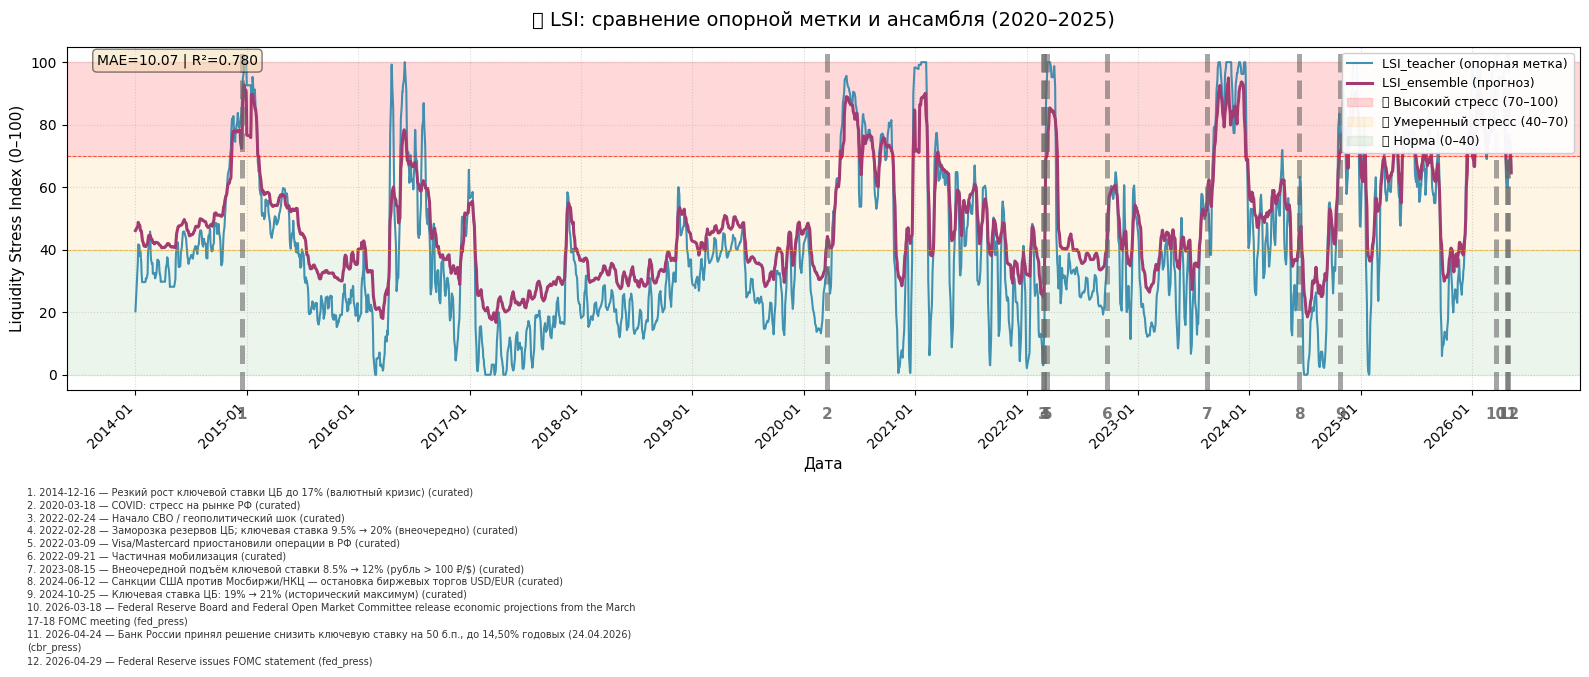


📋 Последние 15 дней:
      date  LSI_teacher  LSI_ensemble     Δ Статус
2026-04-19    72.933283     78.342771  5.41      🔴
2026-04-20    66.637520     74.082389  7.44      🔴
2026-04-21    62.872982     69.532008  6.66      🟡
2026-04-22    60.669504     67.635715  6.97      🟡
2026-04-23    60.158556     65.873151  5.71      🟡
2026-04-24    59.881912     67.984408  8.10      🟡
2026-04-27    60.216666     66.310012  6.09      🟡
2026-04-28    64.025743     65.327712  1.30      🟡
2026-04-29    65.594376     66.492568  0.90      🟡
2026-04-30    67.254620     67.677504  0.42      🟡
2026-05-04    69.817977     68.394409 -1.42      🟡
2026-05-05    73.345708     70.543981 -2.80      🔴
2026-05-06    74.526624     70.319627 -4.21      🔴
2026-05-07    71.269833     68.172887 -3.10      🟡
2026-05-08    65.057381     64.612392 -0.44      🟡


In [21]:
# --- Визуализация LSI: 2014–2026 (финальный график) ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Фильтр периода
_F = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_T = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
mask = (wide_lsi['date'] >= _F) & (wide_lsi['date'] <= _T)
plot_df = wide_lsi.loc[mask, ['date', 'LSI_teacher', 'LSI_ensemble']].dropna().copy()

if len(plot_df) == 0:
    print("⚠️ Нет данных для отображения в периоде 2020–2025")
else:
    fig, ax = plt.subplots(figsize=(16, 7))

    # Основной график
    ax.plot(plot_df['date'], plot_df['LSI_teacher'],
            label='LSI_teacher (опорная метка)', color='#2E86AB', linewidth=1.5, alpha=0.9)
    ax.plot(plot_df['date'], plot_df['LSI_ensemble'],
            label='LSI_ensemble (прогноз)', color='#A23B72', linewidth=2.2)

    # Зоны стресса
    ax.axhspan(70, 100, alpha=0.15, color='red', label='🔴 Высокий стресс (70–100)')
    ax.axhspan(40, 70, alpha=0.1, color='orange', label='🟡 Умеренный стресс (40–70)')
    ax.axhspan(0, 40, alpha=0.08, color='green', label='🟢 Норма (0–40)')

    # Алерт-линии
    ax.axhline(40, color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axhline(70, color='red', linestyle='--', linewidth=0.7, alpha=0.6)

    _nmsl = 0
    _evsl = globals().get("SMARTLAB_MACRO_EVENTS")
    if _evsl is not None and not getattr(_evsl, "empty", True):
        _nmsl = add_smartlab_macro_vlines(ax, _evsl, plot_df["date"].min(), plot_df["date"].max())

    # Оформление
    ax.set_xlabel('Дата', fontsize=11)
    ax.set_ylabel('Liquidity Stress Index (0–100)', fontsize=11)
    ax.set_title('📊 LSI: сравнение опорной метки и ансамбля (2020–2025)', fontsize=14, pad=15)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylim(-5, 105)

    # Формат дат
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45, ha='right')

    # Метрики в заголовок
    mae = np.mean(np.abs(plot_df['LSI_ensemble'] - plot_df['LSI_teacher']))
    r2 = 1 - np.sum((plot_df['LSI_ensemble'] - plot_df['LSI_teacher'])**2) / \
             np.sum((plot_df['LSI_teacher'] - plot_df['LSI_teacher'].mean())**2)
    ax.text(0.02, 0.98, f'MAE={mae:.2f} | R²={r2:.3f}',
           transform=ax.transAxes, fontsize=10,
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
           verticalalignment='top')

    _b18 = 0.06 if not _nmsl else min(0.52, 0.03 + 0.017 * _nmsl)
    plt.tight_layout(rect=[0, _b18, 1, 0.97])
    plt.show()

    # Бонус: таблица последних 15 дней
    print("\n📋 Последние 15 дней:")
    display_df = wide_lsi[['date', 'LSI_teacher', 'LSI_ensemble']].dropna().tail(15).copy()
    display_df['Δ'] = (display_df['LSI_ensemble'] - display_df['LSI_teacher']).round(2)
    display_df['Статус'] = display_df['LSI_ensemble'].apply(
        lambda x: '🔴' if x >= 70 else '🟡' if x >= 40 else '🟢'
    )
    print(display_df.to_string(index=False))

/tmp/ipykernel_34522/37302346.py:77: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b19, 1, 0.97])
/tmp/ipykernel_34522/37302346.py:77: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b19, 1, 0.97])
/tmp/ipykernel_34522/37302346.py:77: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b19, 1, 0.97])
/tmp/ipykernel_34522/37302346.py:77: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, _b19, 1, 0.97])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missi

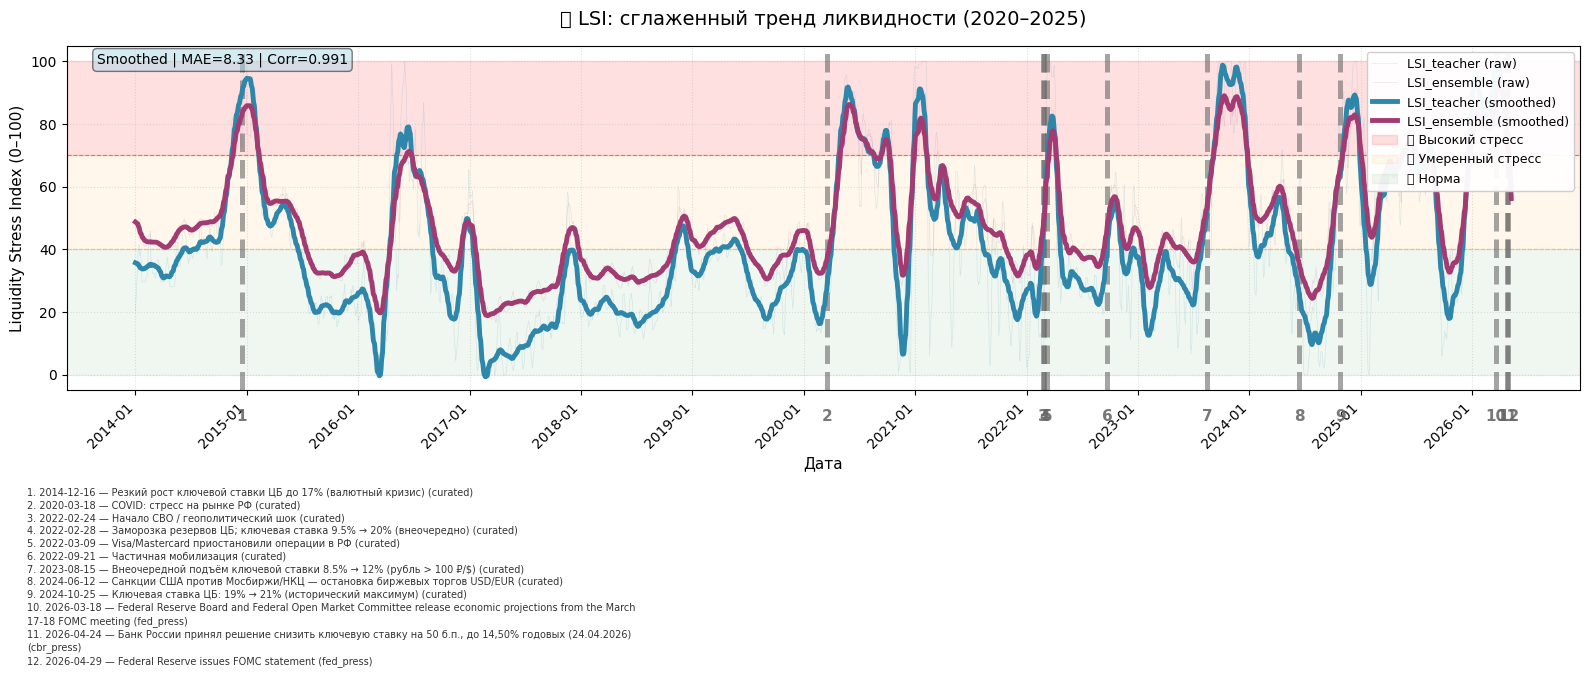

In [22]:
# --- Сглаженный график LSI (2014–2026) ---
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Фильтр периода
# Используем wide_lsi, так как расчеты записаны именно туда
_F = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_T = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
mask = (wide_lsi['date'] >= _F) & (wide_lsi['date'] <= _T)
plot_df = wide_lsi.loc[mask, ['date', 'LSI_teacher', 'LSI_ensemble']].dropna().copy()

if len(plot_df) < 100:
    print("⚠️ Недостаточно данных для сглаживания")
else:
    # === Параметры сглаживания ===
    # window_length должен быть нечётным и < len(data)
    # polyorder < window_length
    WINDOW = 61      # окно ~2 месяца (для сильного сглаживания)
    POLYORDER = 3    # полином 3-й степени

    # Подготавливаем данные
    y_teacher = plot_df['LSI_teacher'].values
    y_ens = plot_df['LSI_ensemble'].values
    x_dates = plot_df['date'].values

    # Сглаживание Savitzky-Golay (сохраняет пики, но убирает шум)
    y_teacher_smooth = savgol_filter(y_teacher, window_length=WINDOW, polyorder=POLYORDER)
    y_ens_smooth = savgol_filter(y_ens, window_length=WINDOW, polyorder=POLYORDER)

    # === Построение графика ===
    fig, ax = plt.subplots(figsize=(16, 7))

    # Фон: исходные данные (очень бледные)
    ax.plot(x_dates, y_teacher, color='#2E86AB', alpha=0.15, linewidth=0.5, label='LSI_teacher (raw)')
    ax.plot(x_dates, y_ens, color='#A23B72', alpha=0.15, linewidth=0.5, label='LSI_ensemble (raw)')

    # Основной акцент: сглаженные кривые
    ax.plot(x_dates, y_teacher_smooth, color='#2E86AB', linewidth=3.5, label='LSI_teacher (smoothed)', zorder=5)
    ax.plot(x_dates, y_ens_smooth, color='#A23B72', linewidth=3.5, label='LSI_ensemble (smoothed)', zorder=5)

    # Зоны стресса
    ax.axhspan(70, 100, alpha=0.12, color='red', label='🔴 Высокий стресс')
    ax.axhspan(40, 70, alpha=0.08, color='orange', label='🟡 Умеренный стресс')
    ax.axhspan(0, 40, alpha=0.06, color='green', label='🟢 Норма')

    # Пороговые линии
    ax.axhline(40, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(70, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

    _nmsm = 0
    _evsm = globals().get("SMARTLAB_MACRO_EVENTS")
    if _evsm is not None and not getattr(_evsm, "empty", True):
        _nmsm = add_smartlab_macro_vlines(ax, _evsm, pd.Timestamp(x_dates.min()), pd.Timestamp(x_dates.max()))

    # Оформление
    ax.set_xlabel('Дата', fontsize=11)
    ax.set_ylabel('Liquidity Stress Index (0–100)', fontsize=11)
    ax.set_title('📈 LSI: сглаженный тренд ликвидности (2020–2025)', fontsize=14, pad=15)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(-5, 105)

    # Формат дат
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45, ha='right')

    # Метрики для сглаженных рядов
    mae_s = np.mean(np.abs(y_ens_smooth - y_teacher_smooth))
    corr_s = np.corrcoef(y_ens_smooth, y_teacher_smooth)[0, 1]
    ax.text(0.02, 0.98, f'Smoothed | MAE={mae_s:.2f} | Corr={corr_s:.3f}',
           transform=ax.transAxes, fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
           verticalalignment='top')

    _b19 = 0.06 if not _nmsm else min(0.52, 0.03 + 0.017 * _nmsm)
    plt.tight_layout(rect=[0, _b19, 1, 0.97])
    plt.show()

In [23]:
# --- Интерпретируемость: усреднённые важности признаков ---
importances = []
for name, pipe in final_models.items():
    if not hasattr(pipe, "named_steps"):
        continue
    m = pipe.named_steps["m"]
    fi = getattr(m, "feature_importances_", None)
    if fi is not None:
        importances.append(np.asarray(fi, dtype=float))

if importances:
    imp_mean = np.mean(importances, axis=0)
    imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp_mean})
    imp_df = imp_df.sort_values("importance", ascending=False)
    print("Топ-20 признаков (средняя важность по моделям с feature_importances_):")
    print(imp_df.head(20).to_string(index=False))
else:
    print("Нет feature_importances_ (проверьте версии sklearn/xgboost/lightgbm).")

print("\nПоследние 10 дней с LSI:")
# Используем wide_lsi, так как расчеты записаны именно туда
_lsi_cols = ["date", "LSI_teacher", "LSI_ensemble"]
if "LSI_dlinear_tsl" in wide_lsi.columns:
    _lsi_cols.append("LSI_dlinear_tsl")
print(wide_lsi[_lsi_cols].dropna().tail(10).to_string(index=False))

Топ-20 признаков (средняя важность по моделям с feature_importances_):
            feature  importance
Seasonal_Factor_cos  395.207101
Seasonal_Factor_sin  329.941056
         m1_ruo_mad  251.782021
             m1_ruo  241.845378
   m3_volume_demand  221.698582
       m3_yield_avg  210.921067
           m1_shift  204.962119
            m1_need  203.259752
            m1_fact  199.174128
    m3_volume_offer  198.513225
m3_volume_placement  196.044089
 m2_Ключевая_ставка  176.004451
 m3_mad_score_yield  172.238054
     m3_cover_ratio  166.293654
       m1_shift_mad  152.369284
 m3_mad_score_cover  131.919404
         m1_MaxRate  104.147378
             m1_vol   93.483086
         m1_MinRate   68.333878
m1_Flag_EndOfPeriod   14.010880

Последние 10 дней с LSI:
      date  LSI_teacher  LSI_ensemble  LSI_dlinear_tsl
2026-04-24    59.881912     67.984408        61.735492
2026-04-27    60.216666     66.310012        59.984510
2026-04-28    64.025743     65.327712        59.624706
2026-04-29 

## Подбор гиперпараметров: LightGBM (lgbm_huber)

Выбираем одну модель бустинга и тюним её на **временной кросс-валидации** (`TimeSeriesSplit`) случайным поиском по сетке:

- регуляризация листьев (`reg_lambda`, `reg_alpha`),
- шаг и количество деревьев (`learning_rate`, `n_estimators`),
- сложность дерева (`num_leaves`, `min_child_samples`),
- подвыборки (`subsample`, `colsample_bytree`).

Затем фиксируем лучшие параметры, переобучаем на полном train, считаем метрики на holdout и строим **отдельный график LSI** только для этой модели (с post-hoc tax kick из M4).

Поиск по 30 конфигурациям × 4 фолдов TimeSeriesSplit (gap=7)…


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['m3_mad_score_cover' 'm3_mad_score_yield_spread' 'm3_flag_nedospros'
 'm3_flag_perespros' 'm1_MaxRate' 'm1_MinRate' 'm3_cover_ratio'
 'm3_mad_score_yield' 'm3_volume_demand' 'm3_volume_offer'
 'm3_volume_placement' 'm3_yield_avg' 'm3_yield_spread']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['m3_mad_score_cover' 'm3_mad_score_yield_spread' 'm3_flag_nedospros'
 'm3_flag_perespros' 'm1_MaxRate' 'm1_MinRate' 'm3_cover_ratio'
 'm3_mad_score_yield' 'm3_volume_demand' 'm3_volume_offer'
 'm3_volume_placement' 'm3_yield_avg' 'm3_yield_spread']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklear

Готово за 104.8 c. Лучший CV MAE = 19.628
Лучшие параметры:
  m__subsample: 0.7
  m__reg_lambda: 0.5
  m__reg_alpha: 0.0
  m__num_leaves: 47
  m__n_estimators: 300
  m__min_child_samples: 40
  m__max_depth: -1
  m__learning_rate: 0.02
  m__colsample_bytree: 0.8

Топ-10 кандидатов (CV MAE, ниже лучше):
   cv_mae  std_test_score                                                                                                                                                                                                              params
19.627999        5.606458 {'m__subsample': 0.7, 'm__reg_lambda': 0.5, 'm__reg_alpha': 0.0, 'm__num_leaves': 47, 'm__n_estimators': 300, 'm__min_child_samples': 40, 'm__max_depth': -1, 'm__learning_rate': 0.02, 'm__colsample_bytree': 0.8}
19.833649        5.723237  {'m__subsample': 0.9, 'm__reg_lambda': 0.0, 'm__reg_alpha': 0.0, 'm__num_leaves': 23, 'm__n_estimators': 300, 'm__min_child_samples': 60, 'm__max_depth': 9, 'm__learning_rate': 0.04, 'm__colsamp

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


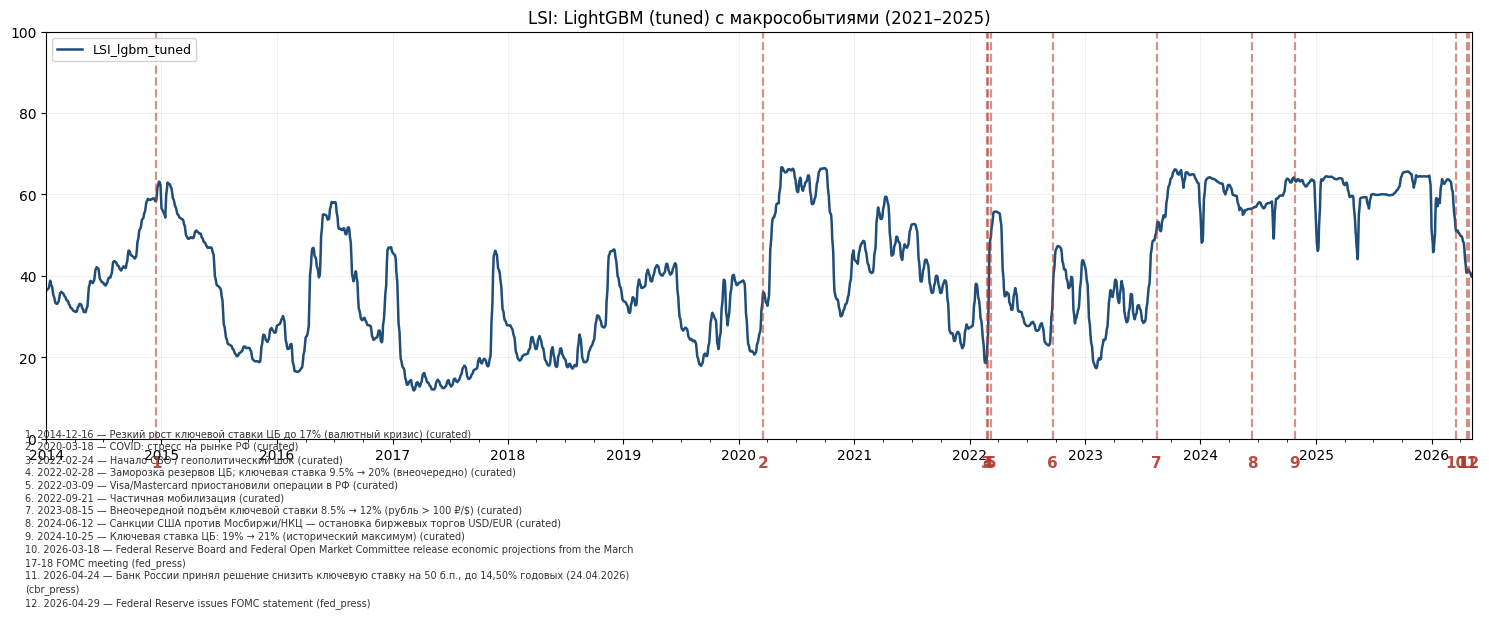

In [24]:
# --- HP-tuning LightGBM (lgbm_huber) на временной CV + отдельный график LSI ---
import time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

try:
    import lightgbm as lgb
except ImportError as _e:
    raise SystemExit("Нужен lightgbm: `pip install lightgbm`") from _e

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# --- Дефолты, чтобы ячейку можно было запускать изолированно ---
HUBER_DELTA = float(globals().get("HUBER_DELTA", 5.0))


def _local_make_pipe(est) -> Pipeline:
    """Тот же пайплайн, что и в основной ячейке: median impute + RobustScaler + модель."""
    return Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", RobustScaler(with_centering=True, with_scaling=True)),
            ("m", est),
        ]
    )


make_pipe = globals().get("make_pipe", _local_make_pipe)


def _local_rmse(y_t, y_p):
    return float(np.sqrt(mean_squared_error(y_t, y_p)))


_rmse = globals().get("_rmse", _local_rmse)


def _local_postprocess_lsi(y, d_calendar):
    """Сглаживание по календарю (как в cell 21): trailing rolling mean окно 5."""
    o = np.argsort(pd.to_datetime(d_calendar).values)
    ys = pd.Series(np.asarray(y, dtype=float)[o])
    sm = ys.rolling(5, min_periods=1).mean().to_numpy()
    out = np.empty_like(np.asarray(y, dtype=float))
    out[o] = sm
    return np.clip(out, 0.0, 100.0)


postprocess_lsi = globals().get("postprocess_lsi", _local_postprocess_lsi)


def _local_apply_tax_kick(lsi_pred, kick):
    return np.clip(np.asarray(lsi_pred, dtype=float) + np.asarray(kick, dtype=float), 0.0, 100.0)


apply_tax_kick = globals().get("apply_tax_kick", _local_apply_tax_kick)

# 1) Сетка гиперпараметров (узкая, но осмысленная — train быстрый).
LGBM_PARAM_DIST = {
    "m__n_estimators":      [300, 450, 600, 800, 1000],
    "m__learning_rate":     [0.02, 0.03, 0.04, 0.05, 0.07],
    "m__num_leaves":        [15, 23, 31, 47, 63],
    "m__min_child_samples": [20, 30, 40, 60, 80],
    "m__reg_lambda":        [0.0, 0.5, 1.0, 2.0, 5.0],
    "m__reg_alpha":         [0.0, 0.1, 0.5, 1.0],
    "m__subsample":         [0.7, 0.8, 0.9, 1.0],
    "m__colsample_bytree":  [0.7, 0.8, 0.9, 1.0],
    "m__max_depth":         [-1, 5, 7, 9],
}

# 2) Базовая модель внутри нашего пайплайна (RobustScaler + LGBM Huber).
_lgbm_base = lgb.LGBMRegressor(
    objective="huber",
    alpha=HUBER_DELTA,
    subsample_freq=1,
    random_state=46,
    verbose=-1,
    n_jobs=-1,
)
_lgbm_pipe = make_pipe(_lgbm_base)

# 3) Временные фолды на train: gap=7 предотвращает «утечки» через сглаживание (window=7).
_tscv = TimeSeriesSplit(n_splits=4, gap=7)

# 4) Сам поиск. neg_MAE → ищем минимальную ошибку.
N_ITER_SEARCH = 30  # увеличьте до 60–100 для более качественного поиска
search = RandomizedSearchCV(
    estimator=_lgbm_pipe,
    param_distributions=LGBM_PARAM_DIST,
    n_iter=N_ITER_SEARCH,
    scoring="neg_mean_absolute_error",
    cv=_tscv,
    n_jobs=1,           # каждая модель LGBM сама использует все ядра
    random_state=11,
    refit=True,
    verbose=0,
)

print(f"Поиск по {N_ITER_SEARCH} конфигурациям × {_tscv.n_splits} фолдов TimeSeriesSplit (gap=7)…")
_t0 = time.time()
search.fit(X_train, y_train)
print(f"Готово за {time.time() - _t0:0.1f} c. Лучший CV MAE = {-search.best_score_:.3f}")
print("Лучшие параметры:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# 5) Топ-10 конфигураций по CV (для понимания «плато»).
_cv = pd.DataFrame(search.cv_results_)
_top = (
    _cv[["mean_test_score", "std_test_score", "params"]]
    .assign(cv_mae=lambda d: -d["mean_test_score"])
    .sort_values("cv_mae")
    .head(10)
    .reset_index(drop=True)
)
print("\nТоп-10 кандидатов (CV MAE, ниже лучше):")
print(_top[["cv_mae", "std_test_score", "params"]].to_string(index=False))

# 6) Лучшая модель уже переобучена на train благодаря refit=True.
lgbm_tuned = search.best_estimator_

# 7) Метрики на holdout до post-hoc tax-kick и после.
_pred_te_raw = np.clip(np.asarray(lgbm_tuned.predict(X_test), dtype=float), 0.0, 100.0)
_pred_te = postprocess_lsi(_pred_te_raw, dates_fit.iloc[test_idx])
_kick_te = wide_lsi.loc[present, "_m4_tax_kick"].to_numpy(dtype=float)[test_idx]
_pred_te_adj = apply_tax_kick(_pred_te, _kick_te)

print(
    "\nHoldout метрики LightGBM (tuned):"
    f"\n  MAE  без tax-kick = {mean_absolute_error(y_test, _pred_te):.3f}"
    f"\n  MAE  с  tax-kick = {mean_absolute_error(y_test, _pred_te_adj):.3f}"
    f"\n  RMSE без tax-kick = {_rmse(y_test, _pred_te):.3f}"
    f"\n  R²   без tax-kick = {r2_score(y_test, _pred_te):.3f}"
)

# 8) Сохраняем колонку прогноза в wide_lsi (на полной панели).
_pred_full_raw = np.clip(np.asarray(lgbm_tuned.predict(X_fit), dtype=float), 0.0, 100.0)
_pred_full = postprocess_lsi(_pred_full_raw, dates_fit)
wide_lsi.loc[present, "LSI_lgbm_tuned"] = _pred_full
wide_lsi.loc[present, "LSI_lgbm_tuned_tax_adj"] = apply_tax_kick(
    _pred_full,
    wide_lsi.loc[present, "_m4_tax_kick"].to_numpy(dtype=float),
)

# 9) Отдельный график LSI для дотюненной модели — окно 2014–2026.
# Собираем данные напрямую из массивов прогноза и dates_fit (без присоединения к wide_lsi),
# чтобы не было дырок (NaN-строки на нерабочие/нестыкуемые даты вне `present`).
_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
_PLOT_SMOOTH = 5  # мягкое сглаживание линий (rolling mean), чтобы убрать «зубцы»

# Прогноз модели на полном fit-наборе уже посчитан выше как `_pred_full`.
_kick_full = wide_lsi.loc[present, "_m4_tax_kick"].to_numpy(dtype=float)

_panel = (
    pd.DataFrame(
        {
            "date": pd.to_datetime(dates_fit.values),
            "teacher": np.asarray(y_all, dtype=float),
            "lgbm": np.asarray(_pred_full, dtype=float),
            "lgbm_tax": apply_tax_kick(_pred_full, _kick_full),
        }
    )
    .sort_values("date")
    .reset_index(drop=True)
)
_panel = _panel[(_panel["date"] >= _PLOT_FROM) & (_panel["date"] <= _PLOT_TO)].copy()

# Заполняем редкие пропуски сначала вперёд, потом назад (на случай редких NaN на краях).
for _c in ("teacher", "lgbm", "lgbm_tax"):
    _panel[_c] = _panel[_c].ffill().bfill()

# Лёгкое сглаживание для отображения (на сами колонки в `wide_lsi` не влияет).
if _PLOT_SMOOTH and _PLOT_SMOOTH > 1:
    for _c in ("teacher", "lgbm", "lgbm_tax"):
        _panel[_c + "_s"] = _panel[_c].rolling(int(_PLOT_SMOOTH), min_periods=1, center=True).mean()
else:
    for _c in ("teacher", "lgbm", "lgbm_tax"):
        _panel[_c + "_s"] = _panel[_c]

# Палитра в синих тонах: основной прогноз и тот же прогноз с post-hoc tax-kick.
COLOR_MODEL = "#1f4e79"
COLOR_TAX = "#0a3d62"

fig_t, ax_t = plt.subplots(figsize=(15, 6.2))

ax_t.plot(
    _panel["date"], _panel["lgbm_s"],
    color=COLOR_MODEL, linewidth=1.8, label="LSI_lgbm_tuned",
)
# ax_t.plot(
#     _panel["date"], _panel["lgbm_tax_s"],
#     color=COLOR_TAX, linewidth=1.4, linestyle="--", alpha=0.95,
#     label="LSI_lgbm_tuned + tax-kick",
# )

ax_t.set_xlim(_panel["date"].min(), _panel["date"].max())
ax_t.set_ylim(0, 100)
ax_t.grid(True, alpha=0.2)
ax_t.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax_t.xaxis.set_major_locator(mdates.YearLocator())
ax_t.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_t.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_t.set_title("LSI: LightGBM (tuned) с макрособытиями (2021–2025)")

# Вертикальные линии макрособытий (ключевая ставка ЦБ + системные события)
_ev_t = globals().get("SMARTLAB_MACRO_EVENTS")
_nm_t = 0
if _ev_t is not None and not getattr(_ev_t, "empty", True):
    _nm_t = add_smartlab_macro_vlines(
        ax_t,
        _ev_t,
        _panel["date"].min(),
        _panel["date"].max(),
        color="#b03a2e",
        alpha=0.55,
        linestyle="--",
        linewidth=1.6,
    )

_bottom_margin = max(0.06, min(0.55, 0.04 + 0.012 * _nm_t))
plt.tight_layout(rect=(0, _bottom_margin, 1, 1))
plt.show()

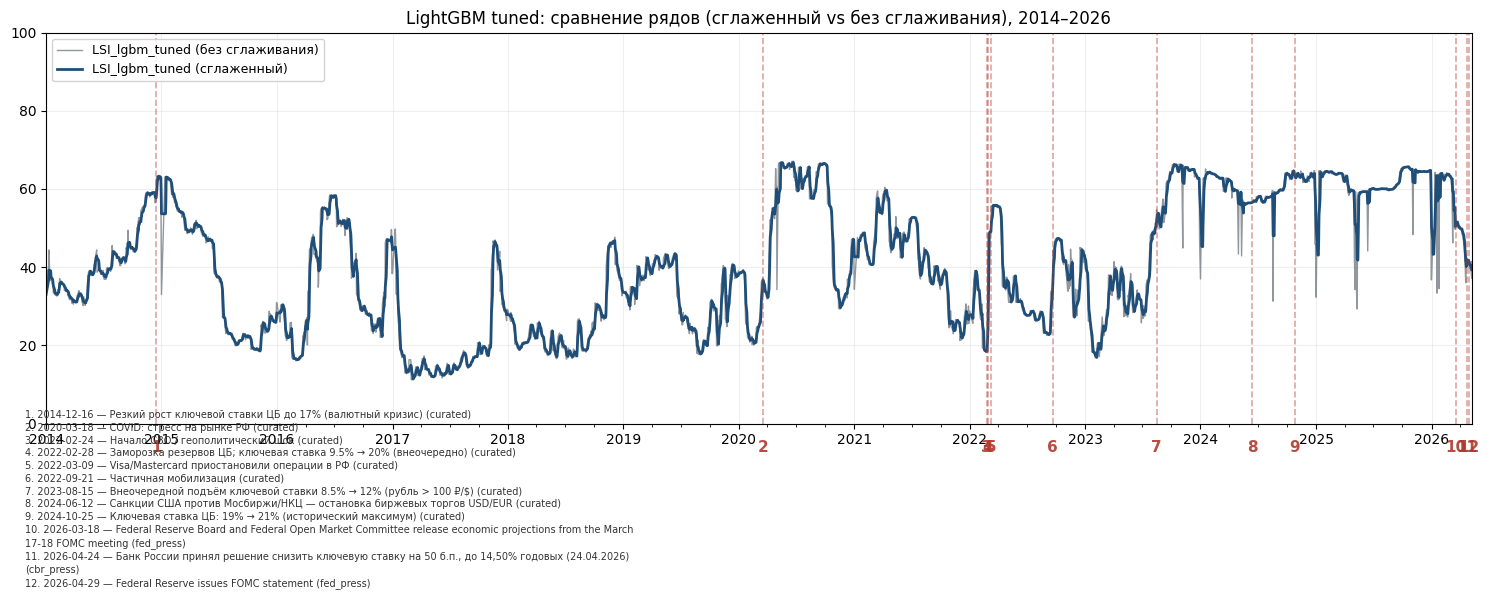

In [25]:
# --- Сравнение для tuned-LightGBM: без сглаживания vs сглаженный (на одном графике) ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))

# Пытаемся взять сырые и сглаженные ряды из последней ячейки tuned-LightGBM.
if "_pred_full_raw" in globals() and "_pred_full" in globals() and "dates_fit" in globals():
    _cmp = pd.DataFrame(
        {
            "date": pd.to_datetime(dates_fit.values),
            "raw": np.clip(np.asarray(_pred_full_raw, dtype=float), 0.0, 100.0),
            "smooth": np.clip(np.asarray(_pred_full, dtype=float), 0.0, 100.0),
        }
    )
# Fallback: если raw не сохранился в сессии, показываем postprocessed vs доп. визуально сглаженный.
elif "wide_lsi" in globals() and "LSI_lgbm_tuned" in wide_lsi.columns:
    _tmp = wide_lsi[["date", "LSI_lgbm_tuned"]].dropna().copy()
    _tmp["date"] = pd.to_datetime(_tmp["date"])
    _tmp = _tmp.sort_values("date").reset_index(drop=True)
    _cmp = pd.DataFrame(
        {
            "date": _tmp["date"],
            "raw": _tmp["LSI_lgbm_tuned"],
            "smooth": _tmp["LSI_lgbm_tuned"].rolling(7, min_periods=1, center=True).mean(),
        }
    )
else:
    raise RuntimeError("Нет данных для сравнения. Сначала запустите ячейку с tuned-LightGBM.")

_cmp = _cmp[(_cmp["date"] >= _PLOT_FROM) & (_cmp["date"] <= _PLOT_TO)].copy()
_cmp = _cmp.sort_values("date").reset_index(drop=True)

fig_cmp, ax_cmp = plt.subplots(figsize=(15, 6.0))
ax_cmp.plot(
    _cmp["date"],
    _cmp["raw"],
    color="#6c757d",
    linewidth=1.0,
    alpha=0.75,
    label="LSI_lgbm_tuned (без сглаживания)",
)
ax_cmp.plot(
    _cmp["date"],
    _cmp["smooth"],
    color="#1f4e79",
    linewidth=2.0,
    label="LSI_lgbm_tuned (сглаженный)",
)

ax_cmp.set_xlim(_cmp["date"].min(), _cmp["date"].max())
ax_cmp.set_ylim(0, 100)
ax_cmp.grid(True, alpha=0.2)
ax_cmp.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax_cmp.set_title("LightGBM tuned: сравнение рядов (сглаженный vs без сглаживания), 2014–2026")
ax_cmp.xaxis.set_major_locator(mdates.YearLocator())
ax_cmp.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_cmp.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Вертикали макрособытий оставляем для контекста.
_ev_cmp = globals().get("SMARTLAB_MACRO_EVENTS")
_nm_cmp = 0
if _ev_cmp is not None and not getattr(_ev_cmp, "empty", True):
    _nm_cmp = add_smartlab_macro_vlines(
        ax_cmp,
        _ev_cmp,
        _cmp["date"].min(),
        _cmp["date"].max(),
        color="#b03a2e",
        alpha=0.45,
        linestyle="--",
        linewidth=1.2,
    )

_bottom = max(0.06, min(0.55, 0.04 + 0.012 * _nm_cmp))
plt.tight_layout(rect=(0, _bottom, 1, 1))
plt.show()


## Локальный LSI (LightGBM, окно 1 год)

Второй итоговый LSI отвечает на вопрос: **«хорошо ли сейчас торговать относительно своего годового нормала?»**.

Глобальный `LSI_lgbm_tuned` (выше) корректно учитывает многолетний тренд ухудшения макро-среды, поэтому к 2024–2026 годам базовый уровень индекса дрейфует вверх — и «спокойные» окна последних лет всё равно выглядят «жёлто-красными». Локальный взгляд устраняет этот сдвиг: цель учителя пересчитывается **внутри скользящего годового окна** как перцентильный ранг (0..100), а LightGBM переобучается walk-forward на последних 365 днях, прогнозируя следующие ~30 дней. Так у каждого момента есть «свои 100%»: даже в самом стрессовом году будут видны локальные «зелёные» окна, а в спокойном году — локальные «красные» пики.


In [ ]:
# --- Локальный LSI: LightGBM walk-forward, окно = 1 год, цель = перцентиль в окне ---
# Глобальный LSI растёт со временем (правильно с точки зрения долгосрочного риска),
# но локально мы хотим понимать, «сейчас торгуем выше или ниже годового нормала».
# Решение: walk-forward переобучение LightGBM. Окно тренировки = 365 дней, шаг = 30 дней.
# Внутри каждого окна цель y_local = перцентильный ранг y_all (0..100), что устраняет
# глобальный тренд и заставляет модель ловить именно локальную структуру.
import time

import lightgbm as lgb
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

assert "X_fit" in globals(), "Нет X_fit. Сначала запустите блок обучения LSI."
assert "y_all" in globals(), "Нет y_all (teacher LSI). Запустите блок обучения LSI."
assert "dates_fit" in globals(), "Нет dates_fit. Запустите блок обучения LSI."
assert "wide_lsi" in globals() and "present" in globals(), "Нет wide_lsi/present."

# --- Гиперпараметры walk-forward ---
LOCAL_WINDOW_DAYS = 365         # окно тренировки — ровно один год (≤ года требует ТЗ)
LOCAL_STEP_DAYS = 30            # шаг переобучения
LOCAL_MIN_HISTORY_DAYS = 240    # минимум 8 мес. истории до первого прогноза
LOCAL_SMOOTH_WINDOW = 5         # постобработка (как у глобальной модели)
LOCAL_MIN_OBS = 60              # минимум строк во вкладе тренировочного окна

HUBER_DELTA = float(globals().get("HUBER_DELTA", 5.0))

# Параметры LightGBM берём из best_params_ глобального тюнинга (если он был),
# но n_estimators сокращаем — обучаемся всего на ~365 точках за раз.
_search = globals().get("search", None)
if _search is not None and hasattr(_search, "best_params_"):
    _best_kwargs = {k.replace("m__", ""): v for k, v in _search.best_params_.items()}
else:
    _best_kwargs = {
        "n_estimators": 400, "learning_rate": 0.04, "num_leaves": 31,
        "min_child_samples": 30, "reg_lambda": 1.0, "reg_alpha": 0.1,
        "subsample": 0.85, "colsample_bytree": 0.85, "max_depth": -1,
    }
_best_kwargs["n_estimators"] = int(min(int(_best_kwargs.get("n_estimators", 400)), 400))


def _make_local_pipe() -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler(with_centering=True, with_scaling=True)),
        ("m", lgb.LGBMRegressor(
            objective="huber",
            alpha=HUBER_DELTA,
            subsample_freq=1,
            random_state=46,
            verbose=-1,
            n_jobs=-1,
            **_best_kwargs,
        )),
    ])


def _percentile_rank(arr: np.ndarray) -> np.ndarray:
    """Перцентильный ранг 0..100, устойчивый к равенствам (average rank)."""
    s = pd.Series(np.asarray(arr, dtype=float))
    return (s.rank(method="average", pct=True).to_numpy() * 100.0)


# --- Сортируем по времени (dates_fit может быть не отсортирован) ---
_order = np.argsort(pd.to_datetime(dates_fit.values).values)
_dates_sorted = pd.to_datetime(pd.Series(dates_fit.values).iloc[_order].reset_index(drop=True))
_X_sorted = X_fit.iloc[_order].reset_index(drop=True)
_y_sorted = np.asarray(y_all, dtype=float)[_order]
_n = len(_dates_sorted)

# --- «Эталонный» локальный teacher: перцентильный ранг y_all в скользящем годовом окне ---
# Это не зависит от модели и нужно нам как (a) метрика для оценки и (b) сравнение на графике.
_y_local_teacher_sorted = np.full(_n, np.nan, dtype=float)
_dates_vals = _dates_sorted.values
for _i in range(_n):
    _t0 = _dates_sorted.iloc[_i] - pd.Timedelta(days=LOCAL_WINDOW_DAYS)
    _mask_i = (_dates_vals >= np.datetime64(_t0)) & (_dates_vals <= _dates_vals[_i])
    _window = _y_sorted[_mask_i]
    if len(_window) < 30:
        continue
    _y_local_teacher_sorted[_i] = float((_window <= _y_sorted[_i]).mean() * 100.0)

# --- Walk-forward: каждые LOCAL_STEP_DAYS переобучаем модель на последних 365 днях ---
_pred_local_sorted = np.full(_n, np.nan, dtype=float)
_first_pred_ix = int(np.searchsorted(
    _dates_vals,
    np.datetime64(_dates_sorted.iloc[0] + pd.Timedelta(days=LOCAL_MIN_HISTORY_DAYS)),
))
_cur = max(_first_pred_ix, 1)

print(
    f"Walk-forward LightGBM (локальный LSI):"
    f"  окно тренировки = {LOCAL_WINDOW_DAYS}d, шаг = {LOCAL_STEP_DAYS}d,"
    f"  мин. история = {LOCAL_MIN_HISTORY_DAYS}d, всего точек = {_n},"
    f"  старт прогноза = {_dates_sorted.iloc[_cur].date() if _cur < _n else 'нет данных'}"
)

_t_start = time.time()
_n_models = 0
while _cur < _n:
    _train_end_date = _dates_sorted.iloc[_cur - 1]
    _train_start_date = _train_end_date - pd.Timedelta(days=LOCAL_WINDOW_DAYS)
    _tr_mask = (_dates_vals >= np.datetime64(_train_start_date)) & (_dates_vals <= np.datetime64(_train_end_date))
    if int(_tr_mask.sum()) < LOCAL_MIN_OBS:
        _cur += LOCAL_STEP_DAYS
        continue
    _X_tr = _X_sorted.loc[_tr_mask]
    _y_tr_global = _y_sorted[_tr_mask]
    _y_tr_local = _percentile_rank(_y_tr_global)

    _pred_end = min(_cur + LOCAL_STEP_DAYS, _n)
    _X_pred = _X_sorted.iloc[_cur:_pred_end]

    _pipe = _make_local_pipe()
    _pipe.fit(_X_tr, _y_tr_local)
    _pred_local_sorted[_cur:_pred_end] = np.clip(_pipe.predict(_X_pred), 0.0, 100.0)

    _cur = _pred_end
    _n_models += 1

print(f"Готово за {time.time() - _t_start:0.1f} c. Моделей обучено: {_n_models}.")

# --- Возвращаемся к исходному порядку wide_lsi[present] ---
_pred_local = np.full(_n, np.nan, dtype=float)
_pred_local[_order] = _pred_local_sorted
_y_local_teacher = np.full(_n, np.nan, dtype=float)
_y_local_teacher[_order] = _y_local_teacher_sorted


def _smooth_by_calendar_local(y: np.ndarray, dts, window: int) -> np.ndarray:
    o = np.argsort(pd.to_datetime(dts).values)
    s = pd.Series(np.asarray(y, dtype=float)[o]).rolling(int(window), min_periods=1).mean().to_numpy()
    out = np.full(len(y), np.nan, dtype=float)
    out[o] = s
    return np.clip(out, 0.0, 100.0)


_pred_local_smooth = _smooth_by_calendar_local(_pred_local, dates_fit, LOCAL_SMOOTH_WINDOW)

# --- Сохраняем в wide_lsi (это автоматически попадёт в экспорт) ---
wide_lsi.loc[present, "LSI_lgbm_local"] = _pred_local_smooth
wide_lsi.loc[present, "LSI_local_teacher"] = _y_local_teacher
print("Сохранено в wide_lsi: LSI_lgbm_local, LSI_local_teacher.")

# --- Holdout-метрики против локального teacher (если есть test_idx) ---
if "test_idx" in globals():
    try:
        _yt = _y_local_teacher[test_idx]
        _yp = _pred_local[test_idx]
        _both = ~np.isnan(_yt) & ~np.isnan(_yp)
        if int(_both.sum()) > 30:
            print(
                "Локальный LSI · holdout (vs локальный teacher):"
                f"  MAE  = {mean_absolute_error(_yt[_both], _yp[_both]):.3f}"
                f"  R²   = {r2_score(_yt[_both], _yp[_both]):.3f}"
                f"  corr = {float(np.corrcoef(_yt[_both], _yp[_both])[0, 1]):+.3f}"
            )
    except Exception as _e:  # noqa: BLE001
        print("Локальные метрики не посчитаны:", _e)

# --- Последние 10 дней: глобальный vs локальный LSI ---
_tail_cols = ["date", "LSI_lgbm_tuned", "LSI_lgbm_local", "LSI_local_teacher"]
_tail = wide_lsi.loc[present, _tail_cols].dropna(subset=["LSI_lgbm_local"]).tail(10)
print("\nПоследние 10 дней (глобальный vs локальный):")
print(_tail.to_string(index=False))


In [ ]:
# --- График Локального LSI (LightGBM walk-forward, окно 1 год) ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

assert "LSI_lgbm_local" in wide_lsi.columns, (
    "Нет колонки LSI_lgbm_local. Сначала запустите ячейку обучения локального LSI."
)

_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
_PLOT_SMOOTH_DISP = 7  # сглаживание только для визуализации

_loc_cols = ["date", "LSI_lgbm_local", "LSI_local_teacher", "LSI_lgbm_tuned"]
_have_cols = [c for c in _loc_cols if c in wide_lsi.columns]
_loc_panel = wide_lsi.loc[present, _have_cols].copy()
_loc_panel["date"] = pd.to_datetime(_loc_panel["date"])
_loc_panel = _loc_panel.dropna(subset=["LSI_lgbm_local"]).sort_values("date").reset_index(drop=True)
_loc_panel = _loc_panel[(_loc_panel["date"] >= _PLOT_FROM) & (_loc_panel["date"] <= _PLOT_TO)].copy()
for _c in ("LSI_lgbm_local", "LSI_local_teacher", "LSI_lgbm_tuned"):
    if _c in _loc_panel.columns:
        _loc_panel[_c + "_s"] = _loc_panel[_c].rolling(_PLOT_SMOOTH_DISP, min_periods=1, center=True).mean()

fig_l, ax_l = plt.subplots(figsize=(15, 6.4))

# Зоны статусов — общие со «светофором» дашборда.
ax_l.axhspan(0, 40, facecolor="#d4edda", alpha=0.30, zorder=0)
ax_l.axhspan(40, 70, facecolor="#fff3cd", alpha=0.30, zorder=0)
ax_l.axhspan(70, 100, facecolor="#f8d7da", alpha=0.30, zorder=0)
ax_l.text(_loc_panel["date"].min(), 35, "  GREEN", color="#1f7a37", fontsize=8, va="top", alpha=0.65)
ax_l.text(_loc_panel["date"].min(), 65, "  YELLOW", color="#8a6d12", fontsize=8, va="top", alpha=0.65)
ax_l.text(_loc_panel["date"].min(), 95, "  RED",    color="#9c2630", fontsize=8, va="top", alpha=0.65)

# Глобальный LSI как контекст (бледно).
if "LSI_lgbm_tuned_s" in _loc_panel.columns:
    ax_l.plot(
        _loc_panel["date"], _loc_panel["LSI_lgbm_tuned_s"],
        color="#6c757d", linewidth=1.0, alpha=0.60,
        label="LSI_lgbm_tuned (глобальный)",
    )

# Локальный teacher — «идеальный локальный LSI», чтобы видеть, к чему стремится модель.
if "LSI_local_teacher_s" in _loc_panel.columns:
    ax_l.plot(
        _loc_panel["date"], _loc_panel["LSI_local_teacher_s"],
        color="#9aa0a6", linewidth=1.0, alpha=0.65, linestyle=":",
        label="Локальный teacher (rank 365d)",
    )

# Локальный LSI (основной выход модели).
ax_l.plot(
    _loc_panel["date"], _loc_panel["LSI_lgbm_local_s"],
    color="#0a6b3d", linewidth=2.2,
    label="LSI_lgbm_local (окно 1 год)",
)

ax_l.set_xlim(_loc_panel["date"].min(), _loc_panel["date"].max())
ax_l.set_ylim(0, 100)
ax_l.grid(True, alpha=0.2)
ax_l.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax_l.set_ylabel("Локальный LSI, 0..100 (перцентиль в окне 365d)")
ax_l.set_title("Локальный LSI: LightGBM walk-forward · окно = 1 год · 2016–2026")
ax_l.xaxis.set_major_locator(mdates.YearLocator())
ax_l.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_l.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Макрособытия — те же красные пунктиры, что и на глобальном графике.
_ev_l = globals().get("SMARTLAB_MACRO_EVENTS")
_nm_l = 0
if (
    _ev_l is not None
    and not getattr(_ev_l, "empty", True)
    and "add_smartlab_macro_vlines" in globals()
):
    _nm_l = add_smartlab_macro_vlines(
        ax_l, _ev_l,
        _loc_panel["date"].min(), _loc_panel["date"].max(),
        color="#b03a2e", alpha=0.50, linestyle="--", linewidth=1.4,
    )

_bm = max(0.06, min(0.55, 0.04 + 0.012 * _nm_l))
plt.tight_layout(rect=(0, _bm, 1, 1))
plt.show()


## Подбор гиперпараметров локального LSI

HP-тюнинг глобальной модели подбирал параметры под «глобальную» цель (LSI 0..100 от стресса по всей истории). Локальная задача отличается: цель — это **перцентильный ранг в скользящем 365-дневном окне**, а обучаемся мы на маленьких подвыборках по ~год. Поэтому имеет смысл искать **свои** гиперпараметры — обычно лучше работают меньшие `n_estimators`, более мягкий `min_child_samples` (на 365 строках жёсткие сплиты переобучают) и более глубокие деревья.

Поиск делаем `RandomizedSearchCV` на цели-серии «перцентильный ранг 365d» с `TimeSeriesSplit(gap=7)` — это та же логика временной CV, что и для глобальной модели, но цель уже локально нормализована.


In [ ]:
# --- HP-tuning локального LSI: RandomizedSearchCV на цели «percentile rank в 365d окне» ---
import time

import lightgbm as lgb
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

assert "X_fit" in globals() and "y_all" in globals() and "dates_fit" in globals(), (
    "Нужны X_fit / y_all / dates_fit из блока обучения LSI."
)

HUBER_DELTA = float(globals().get("HUBER_DELTA", 5.0))
LOCAL_TUNE_WINDOW_DAYS = 365   # окно для расчёта локальной цели и для тюнинга
LOCAL_TUNE_N_ITER = 30          # бюджет поиска
LOCAL_TUNE_GAP = 7              # gap в TimeSeriesSplit (учитывает 7-дневное сглаживание учителя)

# 1) Глобальная серия «локальной» цели: y_local_target[i] = percentile_rank(y_all[i] в окне 365d до i).
_loc_order = np.argsort(pd.to_datetime(dates_fit.values).values)
_loc_dates_sorted_pd = pd.to_datetime(pd.Series(dates_fit.values).iloc[_loc_order].reset_index(drop=True))
_loc_X_sorted = X_fit.iloc[_loc_order].reset_index(drop=True)
_loc_y_sorted = np.asarray(y_all, dtype=float)[_loc_order]
_loc_n = len(_loc_dates_sorted_pd)
_loc_dates_vals = _loc_dates_sorted_pd.values

_loc_target_sorted = np.full(_loc_n, np.nan, dtype=float)
for _i in range(_loc_n):
    _t0 = _loc_dates_sorted_pd.iloc[_i] - pd.Timedelta(days=LOCAL_TUNE_WINDOW_DAYS)
    _mask_i = (_loc_dates_vals >= np.datetime64(_t0)) & (_loc_dates_vals <= _loc_dates_vals[_i])
    _window = _loc_y_sorted[_mask_i]
    if len(_window) < 30:
        continue
    _loc_target_sorted[_i] = float((_window <= _loc_y_sorted[_i]).mean() * 100.0)

# Сохраняем серию для последующих ячеек, чтобы не пересчитывать.
LOCAL_TARGET_SORTED = _loc_target_sorted
LOCAL_ORDER = _loc_order
LOCAL_X_SORTED = _loc_X_sorted
LOCAL_Y_SORTED = _loc_y_sorted
LOCAL_DATES_SORTED = _loc_dates_sorted_pd

# 2) Берём только валидные точки (после ~30 дней истории), оставляем первые 80% времени на CV.
_valid = ~np.isnan(_loc_target_sorted)
_loc_X_valid = _loc_X_sorted.loc[_valid].reset_index(drop=True)
_loc_y_valid = _loc_target_sorted[_valid]
_cut = int(len(_loc_y_valid) * 0.8)
_X_tune = _loc_X_valid.iloc[:_cut]
_y_tune = _loc_y_valid[:_cut]
print(
    f"Локальная цель (rank в окне {LOCAL_TUNE_WINDOW_DAYS}d): валидных строк = {int(_valid.sum())}/{_loc_n}, "
    f"для CV беру первые {_cut} ({_cut / max(1, len(_loc_y_valid)) * 100:.0f}%)."
)

# 3) Сетка под локальную модель: меньше n_estimators (учимся на ~365 точках), мягче min_child_samples.
LGBM_LOCAL_PARAM_DIST = {
    "m__n_estimators":      [200, 300, 400, 500, 700],
    "m__learning_rate":     [0.03, 0.04, 0.05, 0.07, 0.10],
    "m__num_leaves":        [15, 23, 31, 47],
    "m__min_child_samples": [5, 10, 15, 20, 30],
    "m__reg_lambda":        [0.0, 0.5, 1.0, 2.0, 5.0],
    "m__reg_alpha":         [0.0, 0.1, 0.5, 1.0],
    "m__subsample":         [0.7, 0.85, 1.0],
    "m__colsample_bytree":  [0.7, 0.85, 1.0],
    "m__max_depth":         [-1, 4, 6, 8],
}


def _make_local_pipe_base() -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler(with_centering=True, with_scaling=True)),
        ("m", lgb.LGBMRegressor(
            objective="huber",
            alpha=HUBER_DELTA,
            subsample_freq=1,
            random_state=46,
            verbose=-1,
            n_jobs=-1,
        )),
    ])


# 4) Сам поиск.
_tscv_local = TimeSeriesSplit(n_splits=4, gap=LOCAL_TUNE_GAP)
search_local = RandomizedSearchCV(
    estimator=_make_local_pipe_base(),
    param_distributions=LGBM_LOCAL_PARAM_DIST,
    n_iter=LOCAL_TUNE_N_ITER,
    scoring="neg_mean_absolute_error",
    cv=_tscv_local,
    n_jobs=1,
    random_state=11,
    refit=False,   # переобучать здесь не нужно — параметры используются walk-forward'ом ниже
    verbose=0,
)
print(f"Поиск по {LOCAL_TUNE_N_ITER} конфигурациям × {_tscv_local.n_splits} фолдов (gap={LOCAL_TUNE_GAP})…")
_t0 = time.time()
search_local.fit(_X_tune, _y_tune)
print(f"Готово за {time.time() - _t0:0.1f} c. Лучший CV MAE = {-search_local.best_score_:.3f}")
print("Лучшие параметры локального LSI:")
for _k, _v in search_local.best_params_.items():
    print(f"  {_k}: {_v}")

# 5) Сохраняем «чистые» параметры без префикса m__ для walk-forward.
local_best_params = {k.replace("m__", ""): v for k, v in search_local.best_params_.items()}

# 6) Топ-10 для понимания «плато».
_cv = pd.DataFrame(search_local.cv_results_)
_top = (
    _cv[["mean_test_score", "std_test_score", "params"]]
    .assign(cv_mae=lambda d: -d["mean_test_score"])
    .sort_values("cv_mae")
    .head(10)
    .reset_index(drop=True)
)
print("\nТоп-10 кандидатов локального LSI (CV MAE, ниже лучше):")
print(_top[["cv_mae", "std_test_score", "params"]].to_string(index=False))


## Локальный LSI: скользящее окно (тюненные параметры)

Раньше окно тренировки сдвигалось дискретно на 30 дней — это, по сути, «11 точек в год». Теперь делаем настоящее **скользящее окно**: каждые **7 дней** заново обучаем `LightGBM` на последних 365 днях с локально нормализованной целью. Гиперпараметры берутся из ячейки тюнинга выше (`local_best_params`). В итоге переобучений примерно в четыре раза больше, чем было, поэтому переход между сегментами получается плавнее, а реакция модели на смену режима — быстрее.

Колонка `LSI_lgbm_local` в `wide_lsi` перезаписывается тюненой версией (поэтому экспорт в дашборд и эталонный график автоматически подхватят улучшенный ряд).

In [ ]:
# --- Локальный LSI с тюненными параметрами и реально скользящим окном (step = 7d) ---
import time

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

assert "LOCAL_TARGET_SORTED" in globals(), (
    "Нет LOCAL_TARGET_SORTED. Запустите ячейку HP-tuning локального LSI."
)

HUBER_DELTA = float(globals().get("HUBER_DELTA", 5.0))
LOCAL_WINDOW_DAYS = 365         # окно тренировки — год
LOCAL_STEP_DAYS = 7             # реальное скользящее окно: переобучаем каждую неделю
LOCAL_MIN_HISTORY_DAYS = 240    # минимум 8 мес. истории до первого прогноза
LOCAL_MIN_OBS = 60
LOCAL_SMOOTH_WINDOW = 5

# Параметры из ячейки тюнинга (или дефолты, если её не запускали).
_params = dict(globals().get("local_best_params", {})) or {
    "n_estimators": 400, "learning_rate": 0.05, "num_leaves": 31,
    "min_child_samples": 15, "reg_lambda": 1.0, "reg_alpha": 0.1,
    "subsample": 0.85, "colsample_bytree": 0.85, "max_depth": -1,
}
# Чуть приземляем n_estimators: на 365 строках больше 700 — почти всегда «перебуст».
_params["n_estimators"] = int(min(int(_params.get("n_estimators", 400)), 600))


def _make_local_pipe_tuned() -> Pipeline:
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler(with_centering=True, with_scaling=True)),
        ("m", lgb.LGBMRegressor(
            objective="huber",
            alpha=HUBER_DELTA,
            subsample_freq=1,
            random_state=46,
            verbose=-1,
            n_jobs=-1,
            **_params,
        )),
    ])


_order = LOCAL_ORDER
_X_sorted = LOCAL_X_SORTED
_y_sorted = LOCAL_Y_SORTED
_dates_sorted_pd = LOCAL_DATES_SORTED
_dates_vals = _dates_sorted_pd.values
_n = len(_dates_sorted_pd)

_pred_local_sorted = np.full(_n, np.nan, dtype=float)
_first_pred_ix = int(np.searchsorted(
    _dates_vals,
    np.datetime64(_dates_sorted_pd.iloc[0] + pd.Timedelta(days=LOCAL_MIN_HISTORY_DAYS)),
))
_cur = max(_first_pred_ix, 1)

print(
    f"Скользящее окно LightGBM (тюненный):"
    f"  окно = {LOCAL_WINDOW_DAYS}d, шаг = {LOCAL_STEP_DAYS}d,"
    f"  мин. история = {LOCAL_MIN_HISTORY_DAYS}d, точек = {_n},"
    f"  старт прогноза = {_dates_sorted_pd.iloc[_cur].date() if _cur < _n else 'нет данных'}"
)

_t_start = time.time()
_n_models = 0
while _cur < _n:
    _train_end_date = _dates_sorted_pd.iloc[_cur - 1]
    _train_start_date = _train_end_date - pd.Timedelta(days=LOCAL_WINDOW_DAYS)
    _tr_mask = (_dates_vals >= np.datetime64(_train_start_date)) & (_dates_vals <= np.datetime64(_train_end_date))
    if int(_tr_mask.sum()) < LOCAL_MIN_OBS:
        _cur += LOCAL_STEP_DAYS
        continue
    _X_tr = _X_sorted.loc[_tr_mask]
    _y_tr_local = pd.Series(_y_sorted[_tr_mask]).rank(method="average", pct=True).to_numpy() * 100.0
    _pred_end = min(_cur + LOCAL_STEP_DAYS, _n)
    _pipe = _make_local_pipe_tuned()
    _pipe.fit(_X_tr, _y_tr_local)
    _pred_local_sorted[_cur:_pred_end] = np.clip(_pipe.predict(_X_sorted.iloc[_cur:_pred_end]), 0.0, 100.0)
    _cur = _pred_end
    _n_models += 1

print(f"Готово за {time.time() - _t_start:0.1f} c. Моделей обучено: {_n_models}.")

# Возвращаемся к исходному порядку wide_lsi[present].
_pred_local = np.full(_n, np.nan, dtype=float)
_pred_local[_order] = _pred_local_sorted


def _smooth_by_calendar_local(y: np.ndarray, dts, window: int) -> np.ndarray:
    o = np.argsort(pd.to_datetime(dts).values)
    s = pd.Series(np.asarray(y, dtype=float)[o]).rolling(int(window), min_periods=1).mean().to_numpy()
    out = np.full(len(y), np.nan, dtype=float)
    out[o] = s
    return np.clip(out, 0.0, 100.0)


_pred_local_smooth = _smooth_by_calendar_local(_pred_local, dates_fit, LOCAL_SMOOTH_WINDOW)

# Перезаписываем «основной» локальный ряд (используется и в эталонном графике, и в экспорте).
wide_lsi.loc[present, "LSI_lgbm_local"] = _pred_local_smooth
# Сохраняем «эталонный» локальный teacher (если ещё не сохранён ранее).
if "LSI_local_teacher" not in wide_lsi.columns or wide_lsi.loc[present, "LSI_local_teacher"].isna().all():
    _teacher_local_orig = np.full(_n, np.nan, dtype=float)
    _teacher_local_orig[_order] = LOCAL_TARGET_SORTED
    wide_lsi.loc[present, "LSI_local_teacher"] = _teacher_local_orig

# Holdout-метрики против локального teacher.
if "test_idx" in globals():
    _y_local_teacher_orig = np.full(_n, np.nan, dtype=float)
    _y_local_teacher_orig[_order] = LOCAL_TARGET_SORTED
    _yt = _y_local_teacher_orig[test_idx]
    _yp = _pred_local[test_idx]
    _both = ~np.isnan(_yt) & ~np.isnan(_yp)
    if int(_both.sum()) > 30:
        print(
            "Локальный LSI (тюненный · sliding 7d) · holdout vs локальный teacher:"
            f"  MAE  = {mean_absolute_error(_yt[_both], _yp[_both]):.3f}"
            f"  R²   = {r2_score(_yt[_both], _yp[_both]):.3f}"
            f"  corr = {float(np.corrcoef(_yt[_both], _yp[_both])[0, 1]):+.3f}"
        )

# --- Сразу рисуем график тюненного локального LSI ---
_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
_PLOT_SMOOTH_DISP = 7

_loc_cols = ["date", "LSI_lgbm_local", "LSI_local_teacher", "LSI_lgbm_tuned"]
_have_cols = [c for c in _loc_cols if c in wide_lsi.columns]
_loc_panel = wide_lsi.loc[present, _have_cols].copy()
_loc_panel["date"] = pd.to_datetime(_loc_panel["date"])
_loc_panel = _loc_panel.dropna(subset=["LSI_lgbm_local"]).sort_values("date").reset_index(drop=True)
_loc_panel = _loc_panel[(_loc_panel["date"] >= _PLOT_FROM) & (_loc_panel["date"] <= _PLOT_TO)].copy()
for _c in ("LSI_lgbm_local", "LSI_local_teacher", "LSI_lgbm_tuned"):
    if _c in _loc_panel.columns:
        _loc_panel[_c + "_s"] = _loc_panel[_c].rolling(_PLOT_SMOOTH_DISP, min_periods=1, center=True).mean()

fig_st, ax_st = plt.subplots(figsize=(15, 6.4))
ax_st.axhspan(0, 40, facecolor="#d4edda", alpha=0.30, zorder=0)
ax_st.axhspan(40, 70, facecolor="#fff3cd", alpha=0.30, zorder=0)
ax_st.axhspan(70, 100, facecolor="#f8d7da", alpha=0.30, zorder=0)
if "LSI_lgbm_tuned_s" in _loc_panel.columns:
    ax_st.plot(
        _loc_panel["date"], _loc_panel["LSI_lgbm_tuned_s"],
        color="#6c757d", linewidth=1.0, alpha=0.55, label="LSI_lgbm_tuned (глобальный)",
    )
if "LSI_local_teacher_s" in _loc_panel.columns:
    ax_st.plot(
        _loc_panel["date"], _loc_panel["LSI_local_teacher_s"],
        color="#9aa0a6", linewidth=0.9, alpha=0.65, linestyle=":",
        label="Локальный teacher (rank 365d)",
    )
ax_st.plot(
    _loc_panel["date"], _loc_panel["LSI_lgbm_local_s"],
    color="#0a6b3d", linewidth=2.2,
    label="LSI_lgbm_local (tuned · sliding 7d)",
)

ax_st.set_xlim(_loc_panel["date"].min(), _loc_panel["date"].max())
ax_st.set_ylim(0, 100)
ax_st.grid(True, alpha=0.2)
ax_st.legend(loc="upper left", fontsize=9, framealpha=0.85)
ax_st.set_ylabel("Локальный LSI, 0..100 (rank в окне 365d)")
ax_st.set_title("Локальный LSI: LightGBM, тюненный, sliding-window step = 7d (2016–2026)")
ax_st.xaxis.set_major_locator(mdates.YearLocator())
ax_st.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_st.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

_ev_st = globals().get("SMARTLAB_MACRO_EVENTS")
_nm_st = 0
if (
    _ev_st is not None
    and not getattr(_ev_st, "empty", True)
    and "add_smartlab_macro_vlines" in globals()
):
    _nm_st = add_smartlab_macro_vlines(
        ax_st, _ev_st,
        _loc_panel["date"].min(), _loc_panel["date"].max(),
        color="#b03a2e", alpha=0.50, linestyle="--", linewidth=1.4,
    )
_bm = max(0.06, min(0.55, 0.04 + 0.012 * _nm_st))
plt.tight_layout(rect=(0, _bm, 1, 1))
plt.show()


## Multi-window архитектура локального LSI

Один годовой ряд — это лишь одна «линза» локального стресса. Multi-window архитектура смотрит на рынок сразу через несколько объективов:

- **Short (90d)** — квартальное относительное напряжение, очень чувствительный сигнал «здесь и сейчас».
- **Mid (180d)** — полугодовая база, сглаживает шум короткого окна.
- **Long (365d)** — годовая база (наш «стандарт»), наиболее стабильная.

Каждое окно — это отдельный walk-forward LightGBM с собственной локально-нормализованной целью (внутри своего окна). Финальный сигнал `LSI_lgbm_local_multi` — усреднение трёх рядов в точках, где все три валидны. Так модель не «застревает» на одном таймфрейме и не теряет реакцию ни на быстрые, ни на медленные смены режима.

In [ ]:
# --- Multi-window локальный LSI: walk-forward LightGBM с окнами 90 / 180 / 365 дней + блендинг ---
import time

import lightgbm as lgb
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

assert "LOCAL_X_SORTED" in globals(), (
    "Нет LOCAL_X_SORTED. Запустите ячейку HP-tuning локального LSI."
)

HUBER_DELTA = float(globals().get("HUBER_DELTA", 5.0))
LOCAL_MW_WINDOWS = [
    ("short_90",  90,  60,  7),    # window_days, min_history, step
    ("mid_180",  180, 120,  14),
    ("long_365", 365, 240,  14),
]
LOCAL_MW_SMOOTH = 5

_params_mw = dict(globals().get("local_best_params", {})) or {
    "n_estimators": 300, "learning_rate": 0.05, "num_leaves": 23,
    "min_child_samples": 10, "reg_lambda": 1.0, "reg_alpha": 0.1,
    "subsample": 0.85, "colsample_bytree": 0.85, "max_depth": -1,
}
_params_mw["n_estimators"] = int(min(int(_params_mw.get("n_estimators", 400)), 500))


def _build_local_pipe(extra_params: dict | None = None) -> Pipeline:
    p = dict(_params_mw)
    if extra_params:
        p.update(extra_params)
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", RobustScaler(with_centering=True, with_scaling=True)),
        ("m", lgb.LGBMRegressor(
            objective="huber",
            alpha=HUBER_DELTA,
            subsample_freq=1,
            random_state=46,
            verbose=-1,
            n_jobs=-1,
            **p,
        )),
    ])


_order = LOCAL_ORDER
_X_sorted = LOCAL_X_SORTED
_y_sorted = LOCAL_Y_SORTED
_dates_sorted_pd = LOCAL_DATES_SORTED
_dates_vals = _dates_sorted_pd.values
_n = len(_dates_sorted_pd)


def _walk_forward_local(window_days: int, min_history_days: int, step_days: int):
    """Walk-forward LightGBM с локально нормализованной целью внутри окна."""
    pred = np.full(_n, np.nan, dtype=float)
    teacher = np.full(_n, np.nan, dtype=float)

    # «Эталонный» локальный teacher для этого окна (для метрик).
    for _i in range(_n):
        _t0 = _dates_sorted_pd.iloc[_i] - pd.Timedelta(days=window_days)
        _mask_i = (_dates_vals >= np.datetime64(_t0)) & (_dates_vals <= _dates_vals[_i])
        _win = _y_sorted[_mask_i]
        if len(_win) < max(10, int(window_days * 0.1)):
            continue
        teacher[_i] = float((_win <= _y_sorted[_i]).mean() * 100.0)

    cur = int(np.searchsorted(
        _dates_vals,
        np.datetime64(_dates_sorted_pd.iloc[0] + pd.Timedelta(days=min_history_days)),
    ))
    cur = max(cur, 1)

    min_obs = max(20, int(window_days * 0.25))
    n_models = 0
    while cur < _n:
        train_end = _dates_sorted_pd.iloc[cur - 1]
        train_start = train_end - pd.Timedelta(days=window_days)
        tr_mask = (_dates_vals >= np.datetime64(train_start)) & (_dates_vals <= np.datetime64(train_end))
        if int(tr_mask.sum()) < min_obs:
            cur += step_days
            continue
        X_tr = _X_sorted.loc[tr_mask]
        y_tr = pd.Series(_y_sorted[tr_mask]).rank(method="average", pct=True).to_numpy() * 100.0
        pred_end = min(cur + step_days, _n)
        pipe = _build_local_pipe()
        pipe.fit(X_tr, y_tr)
        pred[cur:pred_end] = np.clip(pipe.predict(_X_sorted.iloc[cur:pred_end]), 0.0, 100.0)
        cur = pred_end
        n_models += 1
    return pred, teacher, n_models


def _smooth_by_calendar(y: np.ndarray, dts, window: int) -> np.ndarray:
    o = np.argsort(pd.to_datetime(dts).values)
    s = pd.Series(np.asarray(y, dtype=float)[o]).rolling(int(window), min_periods=1).mean().to_numpy()
    out = np.full(len(y), np.nan, dtype=float)
    out[o] = s
    return np.clip(out, 0.0, 100.0)


# --- Гоняем по окнам ---
_preds_sorted = {}
_teachers_sorted = {}
for _name, _win, _mh, _step in LOCAL_MW_WINDOWS:
    print(f"[multi-window] {_name}: window={_win}d, min_history={_mh}d, step={_step}d …")
    _t0 = time.time()
    _p, _t, _nm = _walk_forward_local(_win, _mh, _step)
    print(f"  → {_nm} моделей, {time.time() - _t0:0.1f}c")
    _preds_sorted[_name] = _p
    _teachers_sorted[_name] = _t

# --- Бленд: среднее по окнам в точках, где валиден хотя бы один прогноз ---
import warnings as _wn

_preds_stack = np.stack([_preds_sorted[n] for n, *_ in LOCAL_MW_WINDOWS])
with _wn.catch_warnings():
    _wn.simplefilter("ignore", category=RuntimeWarning)  # пустые «срезы» по дефекту дают NaN
    _blend_sorted = np.nanmean(_preds_stack, axis=0)
_avail = np.sum(~np.isnan(_preds_stack), axis=0)
_blend_sorted[_avail == 0] = np.nan

# Восстанавливаем порядок и сохраняем в wide_lsi.
for _name, *_ in LOCAL_MW_WINDOWS:
    out = np.full(_n, np.nan, dtype=float)
    out[_order] = _preds_sorted[_name]
    wide_lsi.loc[present, f"LSI_lgbm_local_{_name}"] = _smooth_by_calendar(out, dates_fit, LOCAL_MW_SMOOTH)

out_blend = np.full(_n, np.nan, dtype=float)
out_blend[_order] = _blend_sorted
wide_lsi.loc[present, "LSI_lgbm_local_multi"] = _smooth_by_calendar(out_blend, dates_fit, LOCAL_MW_SMOOTH)
print("Сохранено в wide_lsi: " + ", ".join(
    [f"LSI_lgbm_local_{n}" for n, *_ in LOCAL_MW_WINDOWS] + ["LSI_lgbm_local_multi"]
))

# --- Holdout-метрики для каждого окна (vs «свой» локальный teacher) и для бленда (vs 365d teacher) ---
if "test_idx" in globals():
    print("\nHoldout метрики (vs локальный teacher своего окна):")
    for _name, *_ in LOCAL_MW_WINDOWS:
        _p_orig = np.full(_n, np.nan, dtype=float); _p_orig[_order] = _preds_sorted[_name]
        _t_orig = np.full(_n, np.nan, dtype=float); _t_orig[_order] = _teachers_sorted[_name]
        _yp = _p_orig[test_idx]; _yt = _t_orig[test_idx]
        _both = ~np.isnan(_yp) & ~np.isnan(_yt)
        if int(_both.sum()) > 30:
            print(
                f"  {_name:9s} MAE={mean_absolute_error(_yt[_both], _yp[_both]):.3f}"
                f"  R²={r2_score(_yt[_both], _yp[_both]):.3f}"
                f"  corr={float(np.corrcoef(_yt[_both], _yp[_both])[0, 1]):+.3f}"
                f"  n={int(_both.sum())}"
            )
    # Для бленда сравним с 365d teacher (главный «годовой нормал»).
    _t365_orig = np.full(_n, np.nan, dtype=float); _t365_orig[_order] = _teachers_sorted["long_365"]
    _blend_orig = np.full(_n, np.nan, dtype=float); _blend_orig[_order] = _blend_sorted
    _yp = _blend_orig[test_idx]; _yt = _t365_orig[test_idx]
    _both = ~np.isnan(_yp) & ~np.isnan(_yt)
    if int(_both.sum()) > 30:
        print(
            f"  {'blend':9s} MAE={mean_absolute_error(_yt[_both], _yp[_both]):.3f}"
            f"  R²={r2_score(_yt[_both], _yp[_both]):.3f}"
            f"  corr={float(np.corrcoef(_yt[_both], _yp[_both])[0, 1]):+.3f}"
            f"  n={int(_both.sum())}  (учитель = rank 365d)"
        )


In [ ]:
# --- Multi-window LSI: сравнительный график ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

assert "LSI_lgbm_local_multi" in wide_lsi.columns, (
    "Нет колонки LSI_lgbm_local_multi. Запустите ячейку обучения multi-window локального LSI."
)

_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
_PLOT_SMOOTH_DISP = 7

_mw_cols = [
    "date",
    "LSI_lgbm_tuned",
    "LSI_lgbm_local_short_90",
    "LSI_lgbm_local_mid_180",
    "LSI_lgbm_local_long_365",
    "LSI_lgbm_local_multi",
]
_have = [c for c in _mw_cols if c in wide_lsi.columns]
_mw_panel = wide_lsi.loc[present, _have].copy()
_mw_panel["date"] = pd.to_datetime(_mw_panel["date"])
_mw_panel = _mw_panel.dropna(subset=["LSI_lgbm_local_multi"]).sort_values("date").reset_index(drop=True)
_mw_panel = _mw_panel[(_mw_panel["date"] >= _PLOT_FROM) & (_mw_panel["date"] <= _PLOT_TO)].copy()
for _c in _have[1:]:
    if _c in _mw_panel.columns:
        _mw_panel[_c + "_s"] = _mw_panel[_c].rolling(_PLOT_SMOOTH_DISP, min_periods=1, center=True).mean()

fig_mw, ax_mw = plt.subplots(figsize=(15, 6.6))

ax_mw.axhspan(0, 40, facecolor="#d4edda", alpha=0.30, zorder=0)
ax_mw.axhspan(40, 70, facecolor="#fff3cd", alpha=0.30, zorder=0)
ax_mw.axhspan(70, 100, facecolor="#f8d7da", alpha=0.30, zorder=0)
ax_mw.text(_mw_panel["date"].min(), 35, "  GREEN", color="#1f7a37", fontsize=8, va="top", alpha=0.65)
ax_mw.text(_mw_panel["date"].min(), 65, "  YELLOW", color="#8a6d12", fontsize=8, va="top", alpha=0.65)
ax_mw.text(_mw_panel["date"].min(), 95, "  RED", color="#9c2630", fontsize=8, va="top", alpha=0.65)

if "LSI_lgbm_tuned_s" in _mw_panel.columns:
    ax_mw.plot(
        _mw_panel["date"], _mw_panel["LSI_lgbm_tuned_s"],
        color="#6c757d", linewidth=0.9, alpha=0.55,
        label="LSI_lgbm_tuned (глобальный)",
    )
if "LSI_lgbm_local_short_90_s" in _mw_panel.columns:
    ax_mw.plot(
        _mw_panel["date"], _mw_panel["LSI_lgbm_local_short_90_s"],
        color="#e67e22", linewidth=1.1, alpha=0.85,
        label="local · short (90d)",
    )
if "LSI_lgbm_local_mid_180_s" in _mw_panel.columns:
    ax_mw.plot(
        _mw_panel["date"], _mw_panel["LSI_lgbm_local_mid_180_s"],
        color="#8e44ad", linewidth=1.1, alpha=0.85,
        label="local · mid (180d)",
    )
if "LSI_lgbm_local_long_365_s" in _mw_panel.columns:
    ax_mw.plot(
        _mw_panel["date"], _mw_panel["LSI_lgbm_local_long_365_s"],
        color="#0a6b3d", linewidth=1.4, alpha=0.85,
        label="local · long (365d)",
    )
ax_mw.plot(
    _mw_panel["date"], _mw_panel["LSI_lgbm_local_multi_s"],
    color="#1f4e79", linewidth=2.4,
    label="LSI_lgbm_local_multi (blend)",
)

ax_mw.set_xlim(_mw_panel["date"].min(), _mw_panel["date"].max())
ax_mw.set_ylim(0, 100)
ax_mw.grid(True, alpha=0.2)
ax_mw.legend(loc="upper left", fontsize=9, framealpha=0.85, ncol=2)
ax_mw.set_ylabel("Локальный LSI, 0..100")
ax_mw.set_title("Multi-window локальный LSI: 90d / 180d / 365d + blend (2016–2026)")
ax_mw.xaxis.set_major_locator(mdates.YearLocator())
ax_mw.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_mw.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

_ev_mw = globals().get("SMARTLAB_MACRO_EVENTS")
_nm_mw = 0
if (
    _ev_mw is not None
    and not getattr(_ev_mw, "empty", True)
    and "add_smartlab_macro_vlines" in globals()
):
    _nm_mw = add_smartlab_macro_vlines(
        ax_mw, _ev_mw,
        _mw_panel["date"].min(), _mw_panel["date"].max(),
        color="#b03a2e", alpha=0.45, linestyle="--", linewidth=1.2,
    )
_bm = max(0.06, min(0.55, 0.04 + 0.012 * _nm_mw))
plt.tight_layout(rect=(0, _bm, 1, 1))
plt.show()


## Стабилизация LSI: структурный фон + чистка от событий + гистерезис

Текущий `LSI_lgbm_tuned` хорошо ловит локальные стресс-эпизоды и смену режимов, но из-за высокой волатильности он часто скачет между зонами риска, а структурный стресс перемешан с событийными факторами (налоговые окна, заседания ЦБ, всплески ставок), из-за чего сигнал переоценивает напряжённость и иногда дважды учитывает один и тот же фактор.

Решаем тремя ортогональными слоями:

1. **Структурный фон (LSI_structural)** — каузальная EWMA с halflife = 30 дней. Медленный тренд, реагирующий только на устойчивые сдвиги режима, без всплесков на одиночных событиях.
2. **Чистка от событий (LSI_lgbm_clean)** — data-driven вычитание известных событийных импульсов: налоговый `_m4_tax_kick` + bell-кики вокруг заседаний ЦБ. Коэффициенты атрибуции подбираются `HuberRegressor` по высокочастотной компоненте — устраняем двойной учёт.
3. **Стабильный LSI (LSI_lgbm_stable)** — структурный фон + дампированный транзиент быстрой EWMA (halflife = 5 дней, demp = 0.5). Получаем гладкий, но реактивный ряд — это и есть основной «production» LSI.
4. **Гистерезисные зоны** — пороги входа/выхода разнесены (Schmitt-trigger: enter YELLOW=40, exit=35; enter RED=70, exit=65), плюс минимальное время пребывания 5 дней. Это убирает зону-jitter: переход требует устойчивого превышения порога.

Все четыре улучшения добавляются в `wide_lsi`, а бэктест-ячейки ниже автоматически подхватят новый стабильный ряд для эпизодного и OOS-сравнения.

In [ ]:
# --- Стабилизация LSI: структурный/транзиентный декомпозиция + событийная чистка ---
import numpy as np
import pandas as pd

from sklearn.linear_model import HuberRegressor

assert "wide_lsi" in globals() and "LSI_lgbm_tuned" in wide_lsi.columns, (
    "Нет LSI_lgbm_tuned. Сначала запустите ячейку HP-tuning глобальной модели."
)

# --- Параметры стабилизации ---
HALFLIFE_SLOW = 30   # каузальная EWMA для структурного фона (~месяц)
HALFLIFE_FAST = 5    # каузальная EWMA для быстрой компоненты
TRANSIENT_DAMP = 0.5  # сколько транзиента оставляем в LSI_lgbm_stable
CB_KICK_AMPL = 4.0   # амплитуда событийного импульса вокруг заседания ЦБ (пункты LSI)
CB_KICK_HALF = 2.0   # «полуширина» bell-кика по дням от события
CB_KICK_WINDOW = 5   # окно влияния в днях ± от события

_w = wide_lsi.copy()
_w["date"] = pd.to_datetime(_w["date"])
_dates_ord = np.argsort(_w["date"].values)

_lsi_raw = _w["LSI_lgbm_tuned"].to_numpy(dtype=float)
_lsi_sorted_arr = _lsi_raw[_dates_ord]

# --- 1) Каузальные EWMA-ряды (slow trend + fast smoothed) ---
_slow_sorted = pd.Series(_lsi_sorted_arr).ewm(halflife=HALFLIFE_SLOW, min_periods=1).mean().to_numpy()
_fast_sorted = pd.Series(_lsi_sorted_arr).ewm(halflife=HALFLIFE_FAST, min_periods=1).mean().to_numpy()
_transient_sorted = _fast_sorted - _slow_sorted

# Stable = структурный фон + затуханный транзиент
_stable_sorted = _slow_sorted + TRANSIENT_DAMP * _transient_sorted

# Возвращаем в исходный порядок wide_lsi.
_slow = np.full(len(_lsi_raw), np.nan, dtype=float)
_stable = np.full(len(_lsi_raw), np.nan, dtype=float)
_slow[_dates_ord] = _slow_sorted
_stable[_dates_ord] = _stable_sorted

wide_lsi["LSI_structural"] = np.clip(_slow, 0.0, 100.0)
wide_lsi["LSI_lgbm_stable"] = np.clip(_stable, 0.0, 100.0)

# --- 2) Событийная атрибуция (data-driven) ---
# tax_kick: уже посчитан где-то выше как «явная» налоговая надбавка
_tax_kick = wide_lsi.get("_m4_tax_kick", pd.Series(0.0, index=wide_lsi.index)).fillna(0.0).to_numpy(dtype=float)

# CB meeting bell-kicks: для каждого события заседания ЦБ — bell вокруг даты.
_cb_kick = np.zeros(len(wide_lsi), dtype=float)
_ev = globals().get("SMARTLAB_MACRO_EVENTS")
_n_cb = 0
if _ev is not None and not getattr(_ev, "empty", True) and "event_date" in _ev.columns:
    # Берём только заседания ЦБ РФ (если есть колонка source); иначе — все события.
    _ev_use = _ev
    if "source" in _ev.columns:
        _src_mask = _ev["source"].astype(str).str.lower().str.contains("cbr|центр|банк рос", na=False)
        if int(_src_mask.sum()) >= 3:
            _ev_use = _ev[_src_mask]
    _cb_dates = pd.to_datetime(_ev_use["event_date"]).dropna().unique()
    _n_cb = int(len(_cb_dates))
    for _cd in _cb_dates:
        _dd = (_w["date"] - _cd).dt.days.abs().to_numpy(dtype=float)
        _bell = np.where(_dd <= CB_KICK_WINDOW, CB_KICK_AMPL * np.exp(-_dd / CB_KICK_HALF), 0.0)
        _cb_kick = np.maximum(_cb_kick, _bell)
print(f"Событийные сигналы: tax_kick max = {float(np.nanmax(_tax_kick)):.2f}, "
      f"cb_kick max = {float(np.nanmax(_cb_kick)):.2f} (учтено заседаний ЦБ: {_n_cb})")

# Регрессионная атрибуция: (LSI_tuned − LSI_structural) ~ a*tax + b*cb + ε
# Так событийные коэффициенты ловят именно высокочастотную компоненту, не структуру.
_y_hf = _lsi_raw - _slow
_X_ev = np.column_stack([_tax_kick, _cb_kick])
_mask_fit = np.isfinite(_y_hf) & np.all(np.isfinite(_X_ev), axis=1)
_event_contrib = np.zeros(len(_lsi_raw), dtype=float)
if int(_mask_fit.sum()) > 200 and float(_X_ev[_mask_fit].std(axis=0).min()) > 1e-6:
    try:
        _reg = HuberRegressor(epsilon=1.5, max_iter=300, alpha=1e-3, fit_intercept=False)
        _reg.fit(_X_ev[_mask_fit], _y_hf[_mask_fit])
        # Не пускаем отрицательные коэффициенты (события не могут «снижать» LSI).
        _coef = np.clip(_reg.coef_, 0.0, None)
        _event_contrib = _X_ev @ _coef
        print(
            "Event-attribution (HuberRegressor, без интерсепта, неотрицательные коэффициенты):"
            f"\n  α_tax = {float(_coef[0]):.3f},  α_cb = {float(_coef[1]):.3f}"
        )
    except Exception as _exc:  # noqa: BLE001
        print(f"Event-attribution skipped: {_exc}")
else:
    print("Event-attribution skipped (мало данных или нулевая вариация сигналов).")

wide_lsi["LSI_event_contribution"] = _event_contrib
wide_lsi["LSI_lgbm_clean"] = np.clip(_lsi_raw - _event_contrib, 0.0, 100.0)

# --- 3) Краткий отчёт по гладкости ---
def _hf_noise(series_sorted: np.ndarray) -> float:
    s = series_sorted[np.isfinite(series_sorted)]
    if len(s) < 3:
        return float("nan")
    d2 = np.diff(np.diff(s.astype(float)))
    return float(np.mean(np.abs(d2)))


print("\nГладкость рядов (mean |d²LSI/dt²|, ниже → плавнее):")
for _col in ("LSI_lgbm_tuned", "LSI_lgbm_clean", "LSI_lgbm_stable", "LSI_structural"):
    if _col in wide_lsi.columns:
        _arr_sorted = wide_lsi[_col].iloc[_dates_ord].to_numpy(dtype=float)
        print(f"  {_col:22s}: {_hf_noise(_arr_sorted):.4f}")

print("\nДобавлены колонки в wide_lsi:")
print("  • LSI_structural          — медленный тренд (EWMA halflife = 30d)")
print("  • LSI_lgbm_stable         — главный «production» LSI: структурный фон + дамп. транзиент")
print("  • LSI_lgbm_clean          — LSI_lgbm_tuned минус оценка событийной добавки (tax + CB)")
print("  • LSI_event_contribution  — оценка событийной добавки (пп LSI)")


In [ ]:
# --- Гистерезисные зоны (Schmitt-trigger) + минимальное время пребывания (anti-jitter) ---
import numpy as np
import pandas as pd

ZONE_ENTER = {"YELLOW": 40.0, "RED": 70.0}
ZONE_EXIT  = {"YELLOW": 35.0, "RED": 65.0}
MIN_DWELL_DAYS = 5  # минимум дней подряд в новой зоне, чтобы признать переход


def hysteresis_zones(lsi: np.ndarray, enter: dict, exit_: dict, min_dwell: int = 5) -> np.ndarray:
    """Шмитт-триггер по зонам GREEN/YELLOW/RED + min-dwell гист."""
    n = len(lsi)
    out = np.empty(n, dtype=object)
    current = "GREEN"
    candidate = None
    dwell = 0
    for i, v in enumerate(lsi):
        if not np.isfinite(v):
            out[i] = current
            continue
        if current == "GREEN":
            tgt = "YELLOW" if v >= enter["YELLOW"] else "GREEN"
        elif current == "YELLOW":
            if v >= enter["RED"]:
                tgt = "RED"
            elif v < exit_["YELLOW"]:
                tgt = "GREEN"
            else:
                tgt = "YELLOW"
        else:  # RED
            tgt = "YELLOW" if v < exit_["RED"] else "RED"
        if tgt == current:
            out[i] = current
            candidate = None
            dwell = 0
            continue
        if candidate == tgt:
            dwell += 1
        else:
            candidate = tgt
            dwell = 1
        if dwell >= min_dwell:
            current = tgt
            candidate = None
            dwell = 0
        out[i] = current
    return out


def naive_zones(lsi: np.ndarray, y_thr: float = 40.0, r_thr: float = 70.0) -> np.ndarray:
    """Простые пороги без гистерезиса — для контрольного сравнения."""
    out = np.empty(len(lsi), dtype=object)
    for i, v in enumerate(lsi):
        if not np.isfinite(v):
            out[i] = "GREEN"
        elif v >= r_thr:
            out[i] = "RED"
        elif v >= y_thr:
            out[i] = "YELLOW"
        else:
            out[i] = "GREEN"
    return out


def count_transitions(zones: np.ndarray) -> int:
    if len(zones) < 2:
        return 0
    return int(np.sum(zones[:-1] != zones[1:]))


_w_dates = pd.to_datetime(wide_lsi["date"])
_dates_ord = np.argsort(_w_dates.values)

_report_rows = []
for _col_lsi, _zone_col in (
    ("LSI_lgbm_tuned",  "zone_tuned_naive"),
    ("LSI_lgbm_stable", "zone_stable_hyst"),
):
    if _col_lsi not in wide_lsi.columns:
        continue
    _arr_sorted = wide_lsi[_col_lsi].iloc[_dates_ord].to_numpy(dtype=float)
    if _zone_col == "zone_tuned_naive":
        _zones_sorted = naive_zones(_arr_sorted)
    else:
        _zones_sorted = hysteresis_zones(_arr_sorted, ZONE_ENTER, ZONE_EXIT, MIN_DWELL_DAYS)
    _zones_orig_order = np.empty(len(_arr_sorted), dtype=object)
    _zones_orig_order[_dates_ord] = _zones_sorted
    wide_lsi[_zone_col] = _zones_orig_order

    _n_trans = count_transitions(_zones_sorted)
    _valid = pd.Series(_arr_sorted).notna().to_numpy()
    _zones_valid = _zones_sorted[_valid]
    _shares = pd.Series(_zones_valid).value_counts(normalize=True) * 100.0
    _report_rows.append({
        "source": _col_lsi,
        "zoning": "naive 40/70" if _zone_col == "zone_tuned_naive" else f"hysteresis {ZONE_EXIT['YELLOW']}/{ZONE_ENTER['YELLOW']}/{ZONE_EXIT['RED']}/{ZONE_ENTER['RED']} + dwell {MIN_DWELL_DAYS}d",
        "transitions": _n_trans,
        "GREEN %": round(float(_shares.get("GREEN", 0.0)), 1),
        "YELLOW %": round(float(_shares.get("YELLOW", 0.0)), 1),
        "RED %": round(float(_shares.get("RED", 0.0)), 1),
    })

zones_report_df = pd.DataFrame(_report_rows)
print("Сравнение режимов разметки зон:\n")
print(zones_report_df.to_string(index=False))

if len(zones_report_df) >= 2:
    _t_naive = int(zones_report_df.loc[zones_report_df["zoning"].str.startswith("naive"), "transitions"].iloc[0])
    _t_stab = int(zones_report_df.loc[zones_report_df["zoning"].str.startswith("hysteresis"), "transitions"].iloc[0])
    if _t_naive > 0:
        print(f"\nСнижение jitter (числа переходов): {(1 - _t_stab / _t_naive) * 100:.1f}% (с {_t_naive} до {_t_stab}).")

# Сохраняем «итоговую» зону на базе LSI_lgbm_stable.
if "zone_stable_hyst" in wide_lsi.columns:
    wide_lsi["LSI_zone"] = wide_lsi["zone_stable_hyst"]
    print("\nКолонка `LSI_zone` = `zone_stable_hyst` (рекомендуемая для дашборда/алертов).")


In [ ]:
# --- Сравнение: исходный LSI, чистый, структурный, стабильный + зоны ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

assert "LSI_lgbm_stable" in wide_lsi.columns, (
    "Нет LSI_lgbm_stable. Сначала запустите ячейку стабилизации."
)

_PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
_PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))

_cols_keep = [c for c in (
    "date", "LSI_lgbm_tuned", "LSI_lgbm_clean",
    "LSI_structural", "LSI_lgbm_stable",
    "zone_tuned_naive", "zone_stable_hyst",
) if c in wide_lsi.columns]
_panel_s = wide_lsi[_cols_keep].copy()
_panel_s["date"] = pd.to_datetime(_panel_s["date"])
_panel_s = _panel_s.dropna(subset=["LSI_lgbm_stable"]).sort_values("date").reset_index(drop=True)
_panel_s = _panel_s[(_panel_s["date"] >= _PLOT_FROM) & (_panel_s["date"] <= _PLOT_TO)].copy()

fig_s, (ax_s1, ax_s2) = plt.subplots(
    2, 1, figsize=(15, 9.2), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# --- Верхний график: кривые LSI ---
ax_s1.axhspan(0, 40, facecolor="#d4edda", alpha=0.30, zorder=0)
ax_s1.axhspan(40, 70, facecolor="#fff3cd", alpha=0.30, zorder=0)
ax_s1.axhspan(70, 100, facecolor="#f8d7da", alpha=0.30, zorder=0)

# Сглаженный показ исходного — чтобы не «грязнить» картинку.
_panel_s["LSI_lgbm_tuned_s"] = _panel_s["LSI_lgbm_tuned"].rolling(7, min_periods=1, center=True).mean()

ax_s1.plot(_panel_s["date"], _panel_s["LSI_lgbm_tuned_s"], color="#999999",
           linewidth=0.8, alpha=0.70, label="LSI_lgbm_tuned (raw · сглаж. 7d для отображения)")
if "LSI_lgbm_clean" in _panel_s.columns:
    ax_s1.plot(_panel_s["date"], _panel_s["LSI_lgbm_clean"], color="#8e44ad",
               linewidth=1.4, alpha=0.85, label="LSI_lgbm_clean (минус события)")
if "LSI_structural" in _panel_s.columns:
    ax_s1.plot(_panel_s["date"], _panel_s["LSI_structural"], color="#9c2630",
               linewidth=1.6, linestyle="--", alpha=0.85, label="LSI_structural (slow EWMA 30d)")
ax_s1.plot(_panel_s["date"], _panel_s["LSI_lgbm_stable"], color="#1f4e79",
           linewidth=2.4, label="LSI_lgbm_stable (production)")

ax_s1.set_ylim(0, 100)
ax_s1.set_ylabel("LSI, 0..100")
ax_s1.grid(True, alpha=0.2)
ax_s1.legend(loc="upper left", fontsize=9, framealpha=0.85, ncol=2)
ax_s1.set_title("Стабилизация LSI: структурный фон + чистка событий + дамп. транзиент")

# --- Нижний график: ленты зон ---
_zone_colors = {"GREEN": "#1f7a37", "YELLOW": "#d4a017", "RED": "#9c2630"}

def _zone_rgba_series(zone_series):
    return zone_series.map(_zone_colors).fillna("#cccccc").to_list()


_y_lines = []
if "zone_tuned_naive" in _panel_s.columns:
    ax_s2.scatter(
        _panel_s["date"], np.full(len(_panel_s), 1),
        c=_zone_rgba_series(_panel_s["zone_tuned_naive"]),
        s=10, marker="s",
    )
    _y_lines.append((1, "tuned · 40/70"))
if "zone_stable_hyst" in _panel_s.columns:
    ax_s2.scatter(
        _panel_s["date"], np.full(len(_panel_s), 2),
        c=_zone_rgba_series(_panel_s["zone_stable_hyst"]),
        s=10, marker="s",
    )
    _y_lines.append((2, "stable · hyst + dwell"))

ax_s2.set_yticks([y for y, _ in _y_lines])
ax_s2.set_yticklabels([lbl for _, lbl in _y_lines])
ax_s2.set_ylim(0.4, 2.6)
ax_s2.grid(True, alpha=0.2, axis="x")
ax_s2.xaxis.set_major_locator(mdates.YearLocator())
ax_s2.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax_s2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

from matplotlib.patches import Patch
_legend_patches = [Patch(facecolor=v, label=k) for k, v in _zone_colors.items()]
ax_s2.legend(handles=_legend_patches, loc="upper right", fontsize=8, ncol=3, framealpha=0.85)

plt.tight_layout()
plt.show()


## Бэктест по ТЗ

ТЗ требует три обязательных блока валидации LSI:

1. **Backtest на исторических стресс-эпизодах** — декабрь 2014, февраль–март 2022, август 2023. Для каждого эпизода смотрим, доходил ли LSI до зон YELLOW/RED, какой максимум достигался и за сколько дней относительно события сработал триггер RED.
2. **Backtest на отложенной выборке** — последние 20% времени (holdout), не пересекающиеся с CV-калибровкой; считаем MAE / RMSE / R² / corr против учителя.
3. **Sensitivity analysis** — отклонение ±20% к нормализованным сигналам каждого модуля и измерение влияния на итоговый LSI (max и mean |ΔLSI|, корреляция перед/после).

Эпизод **декабрь 2014** в нашем датасете может оказаться за пределами окна (M3 и LSI учитель доступны с 2016) — в этом случае строка таблицы отметится прочерком, что и сигнализирует о неприменимости. Дополнительно бэктест прогоняется по март 2020 (COVID) и октябрь 2024 (ставка → 21%) для полноты картины.


In [ ]:
# --- Backtest 1: исторические стресс-эпизоды по ТЗ ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Эпизоды из ТЗ + два дополнительных для полноты картины.
STRESS_EPISODES = {
    "Декабрь 2014 (ключ. ставка → 17%)":      pd.Timestamp("2014-12-16"),
    "Февраль–март 2022 (шок, ставка → 20%)":  pd.Timestamp("2022-02-28"),
    "Август 2023 (экстр. → 12%)":             pd.Timestamp("2023-08-15"),
    "Март 2020 (COVID-стресс)":               pd.Timestamp("2020-03-18"),
    "Октябрь 2024 (ставка → 21%)":            pd.Timestamp("2024-10-25"),
}

BT_WINDOW_DAYS = 30
BT_RED = 70.0
BT_YELLOW = 40.0

assert "wide_lsi" in globals(), "Нет wide_lsi."
_bt_lsi_cols = [c for c in (
    "LSI_lgbm_tuned", "LSI_lgbm_local", "LSI_lgbm_local_multi",
    "LSI_lgbm_clean", "LSI_lgbm_stable",  # стабилизированные версии
) if c in wide_lsi.columns]
assert _bt_lsi_cols, "Нет ни одной колонки LSI_*. Сначала обучите модели."

_w_bt = wide_lsi[["date"] + _bt_lsi_cols].copy()
_w_bt["date"] = pd.to_datetime(_w_bt["date"])
_w_bt = _w_bt.sort_values("date").reset_index(drop=True)


def _bt_episode(ep_date: pd.Timestamp, col: str):
    mask = (_w_bt["date"] >= ep_date - pd.Timedelta(days=BT_WINDOW_DAYS)) & \
           (_w_bt["date"] <= ep_date + pd.Timedelta(days=BT_WINDOW_DAYS))
    sub = _w_bt.loc[mask, ["date", col]].dropna(subset=[col])
    if sub.empty:
        return None
    series = sub[col].to_numpy(dtype=float)
    dates = sub["date"].to_numpy()
    max_lsi = float(series.max())
    max_date = pd.Timestamp(dates[int(series.argmax())])
    mean_lsi = float(series.mean())
    red_mask = series >= BT_RED
    triggered_red = bool(red_mask.any())
    days_to_red = None
    if triggered_red:
        first_red = pd.Timestamp(dates[red_mask][0])
        days_to_red = int((first_red - ep_date).days)
    triggered_yellow = bool((series >= BT_YELLOW).any())
    return dict(
        max_lsi=max_lsi, max_date=max_date, mean_lsi=mean_lsi,
        triggered_red=triggered_red, days_to_red=days_to_red,
        triggered_yellow=triggered_yellow, n_obs=int(len(series)),
    )


_rows = []
for _ep_name, _ep_date in STRESS_EPISODES.items():
    for _col in _bt_lsi_cols:
        _r = _bt_episode(_ep_date, _col)
        if _r is None:
            _rows.append({
                "episode": _ep_name, "model": _col,
                "max_lsi": "—", "mean_lsi": "—",
                "RED": "—", "YELLOW": "—",
                "days_to_red": "—", "max_date": "—", "n_obs": 0,
                "note": "вне диапазона данных",
            })
            continue
        _rows.append({
            "episode": _ep_name, "model": _col,
            "max_lsi": round(_r["max_lsi"], 1),
            "mean_lsi": round(_r["mean_lsi"], 1),
            "RED": "✓" if _r["triggered_red"] else "✗",
            "YELLOW": "✓" if _r["triggered_yellow"] else "✗",
            "days_to_red": _r["days_to_red"] if _r["days_to_red"] is not None else "—",
            "max_date": _r["max_date"].strftime("%Y-%m-%d"),
            "n_obs": _r["n_obs"],
            "note": "",
        })

bt_episodes_df = pd.DataFrame(_rows)
print(f"Backtest стресс-эпизодов · окно ±{BT_WINDOW_DAYS}d · RED ≥ {BT_RED}, YELLOW ≥ {BT_YELLOW}\n")
print(bt_episodes_df.to_string(index=False))

# Aggregate verdict per episode (хотя бы одна модель сработала?).
print("\nИтоги (по эпизодам):")
for _ep_name in STRESS_EPISODES:
    _sub = bt_episodes_df[bt_episodes_df["episode"] == _ep_name]
    if (_sub["n_obs"] == 0).all():
        print(f"  • {_ep_name}: данных нет (вне обученного окна).")
        continue
    _red_any = (_sub["RED"] == "✓").any()
    _yellow_any = (_sub["YELLOW"] == "✓").any()
    _valid_max = []
    for _v in _sub["max_lsi"]:
        try:
            _valid_max.append(float(_v))
        except (ValueError, TypeError):
            pass
    _max_lsi_all = max(_valid_max, default=float("nan"))
    if _red_any:
        print(f"  • {_ep_name}: ✅ RED-триггер сработал (max LSI ≈ {_max_lsi_all:.1f}).")
    elif _yellow_any:
        print(f"  • {_ep_name}: ⚠ только YELLOW (max LSI ≈ {_max_lsi_all:.1f}).")
    else:
        print(f"  • {_ep_name}: ❌ ни один уровень не достигнут (max LSI ≈ {_max_lsi_all:.1f}).")

# --- Графики окон по каждому эпизоду ---
_avail_episodes = [
    (n, d) for n, d in STRESS_EPISODES.items()
    if ((_w_bt["date"] >= d - pd.Timedelta(days=60)) & (_w_bt["date"] <= d + pd.Timedelta(days=60))).any()
]
_n_plots = len(_avail_episodes)
if _n_plots:
    fig_bt, axes_bt = plt.subplots(_n_plots, 1, figsize=(15, 2.8 * _n_plots), sharex=False)
    if _n_plots == 1:
        axes_bt = [axes_bt]
    _palette = {
        "LSI_lgbm_tuned":       "#6c757d",
        "LSI_lgbm_local":       "#0a6b3d",
        "LSI_lgbm_local_multi": "#1f4e79",
        "LSI_lgbm_clean":       "#8e44ad",
        "LSI_lgbm_stable":      "#9c2630",
    }
    for _ax, (_ep_name, _ep_date) in zip(axes_bt, _avail_episodes):
        _mask = (_w_bt["date"] >= _ep_date - pd.Timedelta(days=60)) & \
                (_w_bt["date"] <= _ep_date + pd.Timedelta(days=60))
        _ax.axhspan(0, 40, facecolor="#d4edda", alpha=0.3)
        _ax.axhspan(40, 70, facecolor="#fff3cd", alpha=0.3)
        _ax.axhspan(70, 100, facecolor="#f8d7da", alpha=0.3)
        for _col in _bt_lsi_cols:
            _series = _w_bt.loc[_mask, _col]
            if _series.notna().any():
                _ax.plot(_w_bt.loc[_mask, "date"], _series,
                         color=_palette.get(_col, "#888"), linewidth=1.7, label=_col)
        _ax.axvline(_ep_date, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
        _ax.set_title(f"{_ep_name}   ·   событие = {_ep_date.date()}")
        _ax.set_ylim(0, 100)
        _ax.legend(loc="upper left", fontsize=8, framealpha=0.85)
        _ax.grid(True, alpha=0.2)
        _ax.xaxis.set_major_locator(mdates.MonthLocator())
        _ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.tight_layout()
    plt.show()
else:
    print("\nНи один эпизод не пересекается с диапазоном данных — графики не строятся.")


In [ ]:
# --- Backtest 2: out-of-sample (holdout 20% по времени) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

assert "y_all" in globals() and "test_idx" in globals() and "present" in globals(), (
    "Нужны y_all/test_idx/present из блока обучения."
)

_y_test = np.asarray(y_all, dtype=float)[test_idx]
_test_dates = wide_lsi.loc[present, "date"].reset_index(drop=True).iloc[test_idx]
_test_dates = pd.to_datetime(_test_dates).reset_index(drop=True)

_bt_lsi_cols_oos = [c for c in (
    "LSI_lgbm_tuned", "LSI_lgbm_local", "LSI_lgbm_local_multi",
    "LSI_lgbm_clean", "LSI_lgbm_stable",
) if c in wide_lsi.columns]

oos_rows = []
oos_preds = {}
for _col in _bt_lsi_cols_oos:
    _series = wide_lsi.loc[present, _col].reset_index(drop=True).iloc[test_idx].to_numpy(dtype=float)
    _valid = np.isfinite(_series) & np.isfinite(_y_test)
    if int(_valid.sum()) < 30:
        oos_rows.append({"model": _col, "n": int(_valid.sum()),
                         "MAE": "—", "RMSE": "—", "R²": "—", "corr": "—",
                         "days≥70 (%)": "—"})
        continue
    _yt = _y_test[_valid]
    _yp = _series[_valid]
    oos_rows.append({
        "model": _col,
        "n": int(_valid.sum()),
        "MAE":  round(float(mean_absolute_error(_yt, _yp)), 3),
        "RMSE": round(float(np.sqrt(mean_squared_error(_yt, _yp))), 3),
        "R²":   round(float(r2_score(_yt, _yp)), 3),
        "corr": round(float(np.corrcoef(_yt, _yp)[0, 1]), 3),
        "days≥70 (%)": round(float((_yp >= 70).mean() * 100), 1),
    })
    oos_preds[_col] = (_yt, _yp)

oos_df = pd.DataFrame(oos_rows)
print(
    f"OOS бэктест · holdout = последние 20% по времени"
    f" · {_test_dates.min().date()} .. {_test_dates.max().date()}"
    f" · n_test = {len(_y_test)}\n"
)
print(oos_df.to_string(index=False))

# Residual-распределения по каждой модели
if oos_preds:
    fig_oos, axes_oos = plt.subplots(1, len(oos_preds), figsize=(5.2 * len(oos_preds), 4.0), sharey=True)
    if len(oos_preds) == 1:
        axes_oos = [axes_oos]
    for _ax, (_col, (_yt, _yp)) in zip(axes_oos, oos_preds.items()):
        _resid = _yp - _yt
        _ax.hist(_resid, bins=40, color="#1f4e79", alpha=0.75, edgecolor="white")
        _ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
        _ax.set_title(f"{_col}\nresid = pred − teacher  ·  σ = {_resid.std():.2f}")
        _ax.set_xlabel("residual (пункты LSI)")
        _ax.grid(True, alpha=0.2)
    axes_oos[0].set_ylabel("Частота")
    plt.tight_layout()
    plt.show()


In [ ]:
# --- Backtest 3: sensitivity analysis — ±20% к z-score сигналу модуля ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "lgbm_tuned" in globals(), "Нет lgbm_tuned. Запустите ячейку HP-tuning глобальной модели."
assert "X_fit" in globals() and "feature_cols" in globals(), "Нет X_fit/feature_cols."

# Группируем признаки по модулям (m5_* исключён из X как teacher; m4_* может быть исключён, если EXCLUDE_M4_FROM_X).
_module_cols = {}
for _prefix in ("m1", "m2", "m3", "m4"):
    _cols = [c for c in feature_cols if c.startswith(_prefix + "_")]
    if _cols:
        _module_cols[_prefix] = _cols
_other = [c for c in feature_cols if not any(c.startswith(p + "_") for p in ("m1", "m2", "m3", "m4", "m5"))]
if _other:
    _module_cols["other"] = _other

# Достаём шаги пайплайна: пертурбируем именно в z-пространстве (после RobustScaler).
_imp = lgbm_tuned.named_steps["imp"]
_sc = lgbm_tuned.named_steps["sc"]
_mdl = lgbm_tuned.named_steps["m"]

_X_imp = _imp.transform(X_fit)
_X_scaled = _sc.transform(_X_imp)
_X_scaled_df = pd.DataFrame(_X_scaled, columns=feature_cols, index=X_fit.index)

_baseline_pred = np.clip(_mdl.predict(_X_scaled_df), 0.0, 100.0)

_sens_rows = []
for _mod, _cols in _module_cols.items():
    for _factor in (0.8, 1.2):
        _Xs = _X_scaled_df.copy()
        _Xs[_cols] = _Xs[_cols] * _factor
        _pred = np.clip(_mdl.predict(_Xs), 0.0, 100.0)
        _delta = _pred - _baseline_pred
        _sens_rows.append({
            "module":     _mod,
            "factor":     _factor,
            "n_feat":     len(_cols),
            "mean_|Δ|":   round(float(np.mean(np.abs(_delta))), 3),
            "max_|Δ|":    round(float(np.max(np.abs(_delta))), 3),
            "p95_|Δ|":    round(float(np.percentile(np.abs(_delta), 95)), 3),
            "corr_pert":  round(float(np.corrcoef(_baseline_pred, _pred)[0, 1]), 4),
        })

sens_df = pd.DataFrame(_sens_rows)
print("Sensitivity analysis · ±20% к z-score сигналу модуля (LSI_lgbm_tuned)\n")
print(sens_df.to_string(index=False))

# Bar chart: max |Δ| и mean |Δ| по модулям и фактору
_mods = sens_df["module"].drop_duplicates().tolist()
fig_s, ax_s = plt.subplots(figsize=(11, 4.6))
_x = np.arange(len(_mods))
_w = 0.36
for _i, _factor in enumerate((0.8, 1.2)):
    _max_vals = [
        float(sens_df[(sens_df["module"] == m) & (sens_df["factor"] == _factor)]["max_|Δ|"].iloc[0])
        for m in _mods
    ]
    _mean_vals = [
        float(sens_df[(sens_df["module"] == m) & (sens_df["factor"] == _factor)]["mean_|Δ|"].iloc[0])
        for m in _mods
    ]
    _color = "#e67e22" if _factor == 0.8 else "#1f4e79"
    ax_s.bar(_x + (_i - 0.5) * _w, _max_vals, width=_w, color=_color, alpha=0.85,
             label=f"max |Δ| · factor {_factor}")
    ax_s.plot(_x + (_i - 0.5) * _w, _mean_vals, "o-",
              color="black", alpha=0.55,
              label=("mean |Δ|" if _i == 0 else None))
ax_s.set_xticks(_x); ax_s.set_xticklabels(_mods)
ax_s.set_ylabel("|Δ LSI| (пункты)")
ax_s.set_title("Sensitivity: чувствительность LSI_lgbm_tuned к ±20% z-score сигнала модуля")
ax_s.grid(True, axis="y", alpha=0.2)
ax_s.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Итоговая оценка устойчивости
_agg = (
    sens_df.groupby("module")[["mean_|Δ|", "max_|Δ|", "p95_|Δ|"]]
    .max()
    .sort_values("max_|Δ|", ascending=False)
)
print("\nМодули, отсортированные по чувствительности (max по обоим направлениям):\n")
print(_agg.to_string())

_global_max = float(sens_df["max_|Δ|"].max())
_global_mean = float(sens_df["mean_|Δ|"].max())
print("\nИтоговая интерпретация устойчивости:")
if _global_max < 5.0:
    print(f"  ✅ Модель устойчивая: при ±20% к любому модулю максимум |Δ LSI| = {_global_max:.2f} пп.")
elif _global_max < 15.0:
    print(f"  ⚠ Умеренная чувствительность: max |Δ LSI| = {_global_max:.2f} пп — проверьте топ-модуль выше.")
else:
    print(f"  ❌ Высокая чувствительность: max |Δ LSI| = {_global_max:.2f} пп — пересмотрите регуляризацию.")
print(f"  Средняя |Δ LSI| по самому чувствительному фактору ≈ {_global_mean:.2f} пп.")

# Сохраняем для возможного экспорта
backtest_sensitivity_df = sens_df.copy()
backtest_episodes_df = bt_episodes_df.copy()
backtest_oos_df = oos_df.copy()


## Эталонный финальный график LSI (дашборд-стиль, tuned-LightGBM)

Один большой график, который объединяет всё:

- **raw + smooth** прогноз модели,
- **uncertainty band** (доверительный коридор по rolling-std вокруг сглаженной линии),
- **stacked area** вкладов модулей M1..M5 в финальный LSI (нормированы так, чтобы сумма ≈ сглаженной линии),
- **зоны статуса** 0–40 / 40–70 / 70–100 (как требует ТЗ),
- **вертикали и аннотации** ключевых стресс-эпизодов (декабрь 2014, февраль 2022, август 2023, октябрь 2024),
- **разделитель train/test**,
- мини-блок с метриками MAE/R²/корреляция.

Модель — `LSI_lgbm_tuned` из ячейки HP-tuning. Если её ещё не запускали — запустите выше.


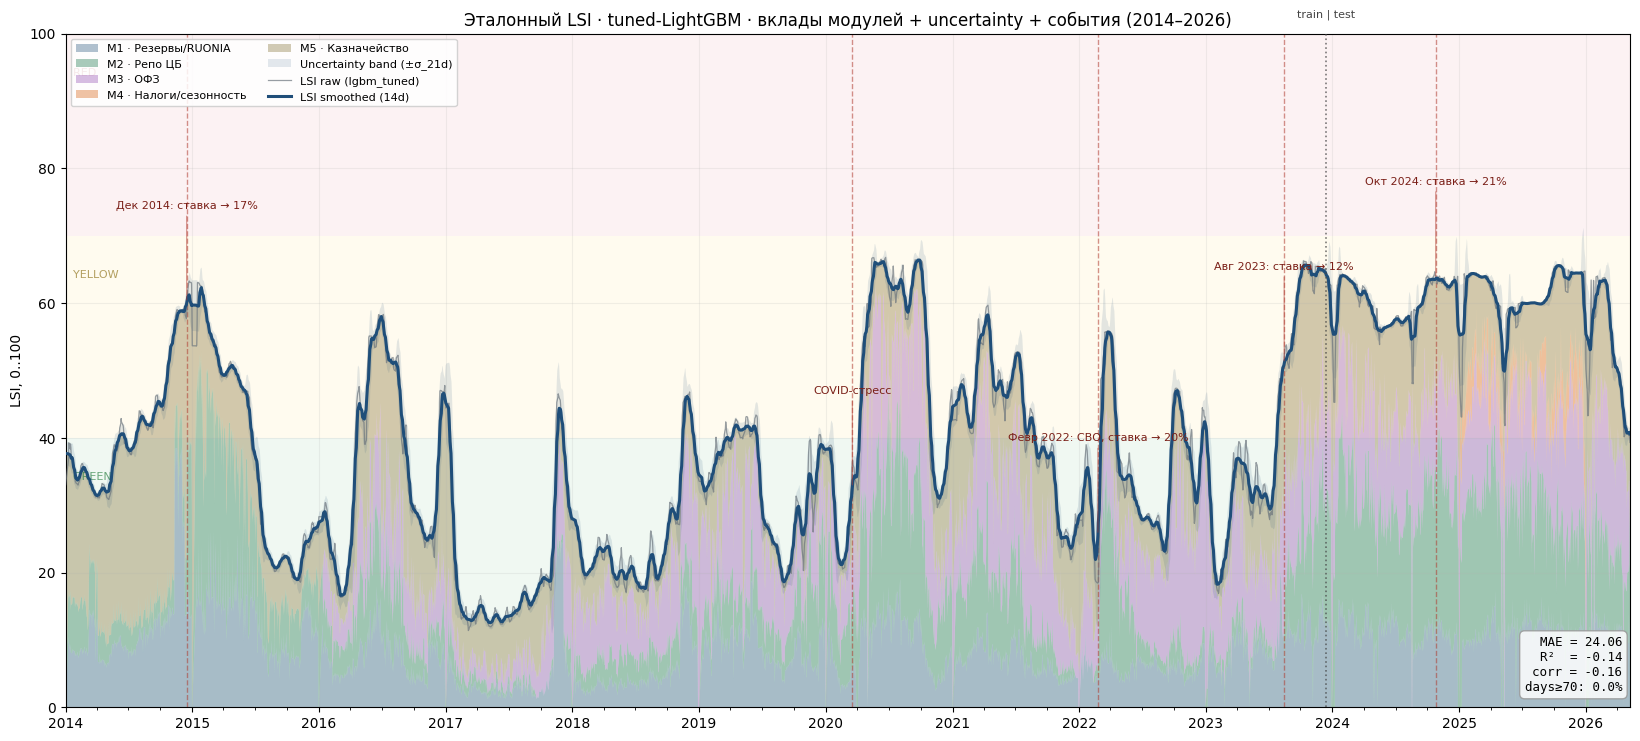

In [29]:
# --- Эталонный график LSI (дашборд-стиль) на базе tuned-LightGBM ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# Источники данных.
assert "wide_lsi" in globals(), "Нет wide_lsi. Сначала запустите блок обучения LSI."
assert "LSI_lgbm_tuned" in wide_lsi.columns, "Нет колонки LSI_lgbm_tuned. Сначала запустите ячейку HP-tuning."

_w = wide_lsi.copy()
_w["date"] = pd.to_datetime(_w["date"])
_w = _w.sort_values("date").reset_index(drop=True)

PLOT_FROM = pd.Timestamp(globals().get("TRAIN_FROM", "2016-01-01"))
PLOT_TO = pd.Timestamp(globals().get("TRAIN_TO", "2026-12-31"))
_mask = (_w["date"] >= PLOT_FROM) & (_w["date"] <= PLOT_TO)
panel = _w.loc[_mask, ["date", "LSI_lgbm_tuned"]].copy()
# Save the index after dropping NaNs to filter other dataframes
panel_filtered_index = panel.dropna(subset=["LSI_lgbm_tuned"]).index
panel = panel.loc[panel_filtered_index].reset_index(drop=True)


# RAW и SMOOTH линии (мягкое сглаживание окном в неделю).
panel["raw"] = panel["LSI_lgbm_tuned"].clip(0, 100)
panel["smooth"] = panel["raw"].rolling(7, min_periods=1, center=True).mean()

# Uncertainty band: rolling std вокруг smooth (показывает локальную нестабильность).
_roll_std = panel["raw"].rolling(21, min_periods=3, center=True).std().fillna(0.0)
panel["lo"] = (panel["smooth"] - _roll_std).clip(0, 100)
panel["hi"] = (panel["smooth"] + _roll_std).clip(0, 100)

# Вклады модулей. Берём готовые признаки модулей (m1..m5 префиксы), агрегируем как |z|.
MOD_COLORS = {
    "m1": "#1f4e79",
    "m2": "#0a6b3d",
    "m3": "#8e44ad",
    "m4": "#d35400",
    "m5": "#7f6b2c",
}
MOD_LABELS = {
    "m1": "M1 · Резервы/RUONIA",
    "m2": "M2 · Репо ЦБ",
    "m3": "M3 · ОФЗ",
    "m4": "M4 · Налоги/сезонность",
    "m5": "M5 · Казначейство",
}
LEAK_COLS = {"m5_liquidity_deficit", "m5_liquidity_deficit_ex_corr", "_raw_stress_teacher"}

contrib_raw = {}
for pref in MOD_COLORS:
    cols_m = [c for c in _w.columns
              if c.startswith(pref + "_")
              and c not in LEAK_COLS
              and pd.api.types.is_numeric_dtype(_w[c])]
    if not cols_m:
        continue
    # Filter block using the same index as the 'panel' dataframe after dropping NaNs
    block = _w.loc[_mask].loc[panel_filtered_index, cols_m].replace([np.inf, -np.inf], np.nan)
    # Стандартизация по mad: |x - median| / (1.4826 * MAD).
    med = block.median(axis=0)
    mad = (block - med).abs().median(axis=0).replace(0, np.nan)
    z = (block - med).abs().div(1.4826 * mad)
    # Усредняем по фичам модуля, ограничиваем 5σ.
    contrib_raw[pref] = z.clip(0, 5).mean(axis=1).fillna(0.0).values

# Если ничего не получилось — fail-safe: равномерно делим smooth между активными модулями.
active_mods = list(contrib_raw.keys()) or ["m1", "m2", "m3", "m4", "m5"]
contrib_df = pd.DataFrame({m: contrib_raw.get(m, np.zeros(len(panel))) for m in active_mods})
# Нормируем так, чтобы сумма по модулям ≈ panel["smooth"] (масштаб 0..100).
row_sum = contrib_df.sum(axis=1).replace(0, np.nan)
share = contrib_df.div(row_sum, axis=0).fillna(1.0 / max(1, len(active_mods)))
contrib_norm = share.mul(panel["smooth"].values, axis=0)
panel = pd.concat([panel, contrib_norm.add_prefix("contrib_")], axis=1)

# Метрики на test (если есть колонка teacher и индексы test_idx).
metrics_box = []
if "_raw_stress_teacher" in _w.columns and "y_all" in globals() and "test_idx" in globals():
    try:
        from sklearn.metrics import mean_absolute_error, r2_score
        # Берём LSI_lgbm_tuned, выровненный по present.
        ds_test = wide_lsi.loc[present, "date"].reset_index(drop=True).iloc[test_idx]
        y_test_arr = np.asarray(y_all)[test_idx]
        merged = panel.merge(
            pd.DataFrame({"date": pd.to_datetime(ds_test.values), "y_test": y_test_arr}),
            on="date", how="inner",
        )
        if len(merged) > 30:
            mae = mean_absolute_error(merged["y_test"], merged["raw"])
            r2 = r2_score(merged["y_test"], merged["raw"])
            corr = float(np.corrcoef(merged["y_test"], merged["raw"])[0, 1])
            metrics_box.append(f"MAE = {mae:.2f}")
            metrics_box.append(f"R²  = {r2:.2f}")
            metrics_box.append(f"corr = {corr:+.2f}")
            metrics_box.append(f"days\u226570: {(merged['raw'] >= 70).mean() * 100:.1f}%")
    except Exception as _exc:  # noqa: BLE001
        print("Метрики не посчитаны:", _exc)

# Стресс-эпизоды для аннотаций (окно с 2016 года).
STRESS_ANNOTS = [
    ("2016-12-16", "Дек 2016: ЦБ держит 10%"),
    ("2018-09-14", "Сен 2018: ставка \u2192 7.5% (геополитика)"),
    ("2020-03-18", "Мар 2020: COVID-стресс"),
    ("2020-07-24", "Июл 2020: ставка \u2192 4.25% (минимум)"),
    ("2021-10-22", "Окт 2021: ставка \u2192 7.5% (цикл повышения)"),
    ("2022-02-28", "Февр 2022: шок, ставка \u2192 20%"),
    ("2022-09-16", "Сен 2022: ставка \u2192 7.5% (низ после кризиса)"),
    ("2023-08-15", "Авг 2023: экстренно \u2192 12%"),
    ("2023-12-15", "Дек 2023: ставка \u2192 16%"),
    ("2024-07-26", "Июл 2024: ставка \u2192 18%"),
    ("2024-10-25", "Окт 2024: ставка \u2192 21%"),
    ("2025-06-06", "Июн 2025: ставка \u2192 20% (смягчение)"),
]
STRESS_ANNOTS = [(pd.Timestamp(d), txt) for d, txt in STRESS_ANNOTS]

fig, ax = plt.subplots(figsize=(16.5, 7.5))

# Зоны статусов.
ax.axhspan(0, 40, facecolor="#d4edda", alpha=0.35, zorder=0)
ax.axhspan(40, 70, facecolor="#fff3cd", alpha=0.30, zorder=0)
ax.axhspan(70, 100, facecolor="#f8d7da", alpha=0.30, zorder=0)
ax.text(panel["date"].min(), 35, "  GREEN", color="#1f7a37", fontsize=8, va="top", alpha=0.65)
ax.text(panel["date"].min(), 65, "  YELLOW", color="#8a6d12", fontsize=8, va="top", alpha=0.65)
ax.text(panel["date"].min(), 95, "  RED",    color="#9c2630", fontsize=8, va="top", alpha=0.65)

# Stacked area вкладов (нижний слой).
contrib_cols = [f"contrib_{m}" for m in active_mods]
ax.stackplot(
    panel["date"], *[panel[c] for c in contrib_cols],
    labels=[MOD_LABELS[m] for m in active_mods],
    colors=[MOD_COLORS[m] for m in active_mods],
    alpha=0.35,
    zorder=1,
)

# Uncertainty band.
ax.fill_between(panel["date"], panel["lo"], panel["hi"], color="#1f4e79", alpha=0.12,
                linewidth=0, zorder=2, label="Uncertainty band (\u00b1\u03c3_21d)")

# Raw + smooth.
ax.plot(panel["date"], panel["raw"], color="#6c757d", linewidth=0.9, alpha=0.7,
        label="LSI raw (lgbm_tuned)", zorder=3)
ax.plot(panel["date"], panel["smooth"], color="#1f4e79", linewidth=2.2,
        label="LSI smoothed (14d)", zorder=4)

# Разделитель train/test (если есть).
if "test_idx" in globals() and "present" in globals():
    try:
        ds_test = wide_lsi.loc[present, "date"].reset_index(drop=True).iloc[test_idx]
        split_date = pd.to_datetime(ds_test.min())
        if PLOT_FROM <= split_date <= PLOT_TO:
            ax.axvline(split_date, color="#444", linestyle=":", linewidth=1.2, alpha=0.7, zorder=5)
            ax.text(split_date, 102, "train | test", color="#444", fontsize=8,
                    ha="center", va="bottom")
    except Exception:
        pass

# Стресс-аннотации.
for d, txt in STRESS_ANNOTS:
    if PLOT_FROM <= d <= PLOT_TO:
        ax.axvline(d, color="#b03a2e", linestyle="--", linewidth=1.0, alpha=0.55, zorder=2)
        # ищем ближайшее значение smooth для размещения подписи
        nearest = panel.iloc[(panel["date"] - d).abs().argsort()[:1]]
        y0 = float(nearest["smooth"].values[0]) if len(nearest) else 80
        y_text = min(98, y0 + 14)
        ax.annotate(
            txt, xy=(d, y0), xytext=(d, y_text),
            color="#7a1f17", fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="-", color="#b03a2e", alpha=0.55, lw=0.8),
            zorder=6,
        )

ax.set_xlim(panel["date"].min(), panel["date"].max())
ax.set_ylim(0, 100)
ax.set_title("Эталонный LSI \u00b7 tuned-LightGBM \u00b7 вклады модулей + uncertainty + события (2014\u20132026)",
             fontsize=12)
ax.set_ylabel("LSI, 0..100")
ax.grid(True, alpha=0.18, zorder=0)

# Бокс с метриками.
if metrics_box:
    txt = "\n".join(metrics_box)
    ax.text(
        0.995, 0.02, txt,
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85, edgecolor="#999"),
    )

# Легенда (модули + линии).
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper left", ncol=2, fontsize=8, framealpha=0.85)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


## Экспорт данных для дашборда

Сохраняем в `dashboard/data/` ровно то, что нужно Streamlit-дашборду:

- `wide_lsi.csv` — основной датасет: LSI-колонки (`LSI_lgbm_tuned`, `LSI_lgbm_local_multi`, …) и все фичи модулей M1–M5;
- `lsi_panel.csv` — **глобальный LSI** (`lsi_raw`, `lsi_smooth`, `lsi_lo`, `lsi_hi`) + вклады модулей `contrib_m1..m5` для stackplot;
- `lsi_panel_local.csv` — **локальный LSI** (`LSI_lgbm_local_multi`, multi-window blend) в том же формате (raw/smooth/lo/hi);
- `stress_events.csv` — даты и подписи стресс-эпизодов;
- `metrics.json` — MAE / R² / corr на holdout;
- `module_drivers.json` — манифест ключевых драйверов M1–M5 (имена колонок, единицы, человекочитаемые подписи) — дашборд читает его, чтобы не хардкодить названия фич.

Ячейка ниже зависит от переменных `wide_lsi`, `panel`, `STRESS_ANNOTS`, `metrics_box`,
которые создаются в ячейках «Multi-window локальный LSI» и «Эталонный финальный график LSI» —
их надо запустить **до** экспорта.


In [ ]:
# --- Экспорт данных в dashboard/data/ ---
# Для дашборда нужны ровно два LSI: глобальный (LSI_lgbm_tuned) и локальный multi-window
# (LSI_lgbm_local_multi). Локальный отвечает на вопрос «как сейчас относительно последнего года».
from pathlib import Path
import json

import numpy as np
import pandas as pd

_candidates = [
    Path.cwd() / "dashboard",
    Path.cwd().parent / "dashboard",
    Path("/content/tryM4/dashboard"),
    Path("/content/dashboard"),
]
DASHBOARD_DIR = next((p for p in _candidates if p.exists()), Path.cwd() / "dashboard")
DATA_DIR = DASHBOARD_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 1) wide_lsi — основной датасет (LSI-колонки + фичи модулей M1..M5).
assert "wide_lsi" in globals(), "Нет wide_lsi — запустите блок обучения LSI."
_must_have = ["LSI_lgbm_tuned"]
_missing = [c for c in _must_have if c not in wide_lsi.columns]
assert not _missing, f"В wide_lsi не хватает обязательных колонок: {_missing}"
wide_lsi.to_csv(DATA_DIR / "wide_lsi.csv", index=False)

# 2) lsi_panel.csv — глобальный LSI (raw/smooth/lo/hi) + вклады модулей (stackplot для дашборда).
assert "panel" in globals(), "Нет panel — запустите ячейку «Эталонный финальный график LSI»."
_contrib_cols = [c for c in panel.columns if c.startswith("contrib_")]
_panel_export = panel[["date", "raw", "smooth", "lo", "hi"] + _contrib_cols].rename(
    columns={"raw": "lsi_raw", "smooth": "lsi_smooth", "lo": "lsi_lo", "hi": "lsi_hi"}
)
_panel_export.to_csv(DATA_DIR / "lsi_panel.csv", index=False)

# 2b) lsi_panel_local.csv — локальный LSI (LSI_lgbm_local_multi, окно 1 год) с теми же raw/smooth/lo/hi.
# Это второй «главный» график дашборда: показывает «как сейчас относительно последнего года».
if "LSI_lgbm_local_multi" in wide_lsi.columns:
    _loc = wide_lsi[["date", "LSI_lgbm_local_multi"]].dropna(subset=["LSI_lgbm_local_multi"]).copy()
    _loc["date"] = pd.to_datetime(_loc["date"])
    _loc = _loc.sort_values("date").reset_index(drop=True)
    _loc["lsi_raw"] = _loc["LSI_lgbm_local_multi"].clip(0.0, 100.0)
    _loc["lsi_smooth"] = _loc["lsi_raw"].rolling(7, min_periods=1, center=True).mean()
    _loc_std = _loc["lsi_raw"].rolling(21, min_periods=3, center=True).std().fillna(0.0)
    _loc["lsi_lo"] = (_loc["lsi_smooth"] - _loc_std).clip(0.0, 100.0)
    _loc["lsi_hi"] = (_loc["lsi_smooth"] + _loc_std).clip(0.0, 100.0)
    _loc[["date", "lsi_raw", "lsi_smooth", "lsi_lo", "lsi_hi"]].to_csv(
        DATA_DIR / "lsi_panel_local.csv", index=False
    )
    print(f" - lsi_panel_local.csv: {len(_loc)} строк (LSI_lgbm_local_multi)")
else:
    print(" - lsi_panel_local.csv пропущен: нет колонки LSI_lgbm_local_multi (запустите multi-window).")

# 3) stress events — вертикальные линии на графиках дашборда.
if "STRESS_ANNOTS" in globals():
    pd.DataFrame(
        [(pd.Timestamp(d).strftime("%Y-%m-%d"), txt) for d, txt in STRESS_ANNOTS],
        columns=["date", "label"],
    ).to_csv(DATA_DIR / "stress_events.csv", index=False)

# 4) metrics — MAE / R² / corr (holdout). Берём из metrics_box, который собирается выше.
_metrics = {}
if "metrics_box" in globals() and metrics_box:
    for _line in metrics_box:
        if "=" in _line:
            k, v = _line.split("=", 1)
            _metrics[k.strip()] = v.strip()
(DATA_DIR / "metrics.json").write_text(json.dumps(_metrics, ensure_ascii=False, indent=2))

# 5) module_drivers.json — небольшой манифест: какие ключевые драйверы показывать в дашборде,
# чтобы Streamlit-страница знала имена колонок и человекочитаемые подписи без захардкода.
_drivers_manifest = {
    "global_lsi_column": "LSI_lgbm_tuned",
    "local_lsi_column": "LSI_lgbm_local_multi" if "LSI_lgbm_local_multi" in wide_lsi.columns else None,
    "drivers": [
        {"module": "m1", "score": "m1_shift_mad",            "value": "m1_shift",                "name": "Спред усреднения резервов",       "units": "млрд руб."},
        {"module": "m1", "score": "m1_ruo_mad",              "value": "m1_ruo",                  "name": "RUONIA",                          "units": "% годовых"},
        {"module": "m2", "score": "m2_MAD_score_cover",      "value": "m2_Cover_ratio",          "name": "Cover ratio репо ЦБ",             "units": "\u00d7"},
        {"module": "m2", "score": "m2_MAD_score_rate_spread","value": "m2_Rate_spread",          "name": "Спред репо к ключевой",           "units": "п.п."},
        {"module": "m3", "score": "m3_mad_score_cover",      "value": "m3_cover_ratio",          "name": "Cover ratio ОФЗ",                 "units": "\u00d7"},
        {"module": "m3", "score": "m3_mad_score_yield_spread","value":"m3_yield_spread",         "name": "Спред доходности ОФЗ",            "units": "п.п."},
        {"module": "m4", "score": "_m4_tax_kick",            "value": "m4_tax_event_weight",     "name": "Налоговая нагрузка недели",       "units": ""},
        {"module": "m5", "score": "m5_MAD_score_liquidity_deficit", "value": "m5_liquidity_deficit", "name": "Структурный дефицит ЦБ",  "units": "млрд руб."},
        {"module": "m5", "score": "m5_MAD_score_treasury_pressure", "value": "m5_treasury_pressure", "name": "Давление казначейства",   "units": "млрд руб."},
    ],
}
(DATA_DIR / "module_drivers.json").write_text(
    json.dumps(_drivers_manifest, ensure_ascii=False, indent=2)
)

# 6) Самопроверка: какие из обязательных драйверов фактически есть в wide_lsi.
_present_drivers = {d["score"]: (d["score"] in wide_lsi.columns) for d in _drivers_manifest["drivers"]}
_n_present = sum(_present_drivers.values())
_n_total = len(_present_drivers)

print(f"[export] saved to {DATA_DIR}")
print(f" - wide_lsi.csv:        {wide_lsi.shape[0]} строк \u00d7 {wide_lsi.shape[1]} колонок")
print(f" - lsi_panel.csv:       {_panel_export.shape[0]} строк (LSI_lgbm_tuned)")
print(f" - stress_events.csv, metrics.json, module_drivers.json")
print(f" - драйверов модулей доступно: {_n_present}/{_n_total}")
_missing_drv = [k for k, v in _present_drivers.items() if not v]
if _missing_drv:
    print(f"   (отсутствуют: {_missing_drv})")
